# CSE498R Research Project

## Notebook 03 — HybridSN Baseline Training & Benchmark Reproduction

### Research Topic
**Long-Tail Logit Calibration (LTLC) for Hyperspectral Image Classification**

### Purpose

This notebook establishes the canonical HybridSN classification backbone and
the unmodified Cross-Entropy baseline used throughout the LTLC study.

The notebook will:

1. load the immutable train/validation/test splits from Notebook 01;
2. load the frozen PCA-normalized cubes from Notebook 02;
3. verify all SHA-256 fingerprints;
4. configure GPU-based deterministic training;
5. build lazy spectral-spatial PyTorch datasets;
6. implement the canonical HybridSN backbone;
7. verify tensor dimensions and model outputs;
8. train the Cross-Entropy baseline using seeds:
   - 42
   - 123
   - 3407
9. select checkpoints using validation data only;
10. evaluate the selected checkpoints on the untouched official test split;
11. save logits, predictions, checkpoints, metrics, and training histories.

No LTLC calibration is performed in this notebook.

## Gate 3 — HybridSN Baseline Success Criteria

Notebook 03 passes only if:

- a CUDA-capable GPU is available;
- Notebook 01 frozen split hashes match;
- Notebook 02 normalized-cube hashes match;
- no train/validation/test split is regenerated;
- no PCA is recomputed;
- lazy patch extraction reproduces the frozen Notebook 02 specification;
- model labels use `0 ... K-1`;
- HybridSN accepts all three dataset-specific patch shapes;
- model output dimension equals the dataset class count;
- no NaN or Inf occurs in model outputs or losses;
- model-training seeds are exactly:
  - `42`
  - `123`
  - `3407`
- the same validation split is used for every seed and method;
- checkpoint selection uses validation metrics only;
- the official test set is evaluated only after checkpoint selection;
- checkpoints and test logits are permanently saved.

If a mandatory integrity check fails:

**STOP — do not continue model training.**

In [1]:
# ============================================================
# CELL 03 — MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [2]:
# ============================================================
# CELL 04 — IMPORT REQUIRED LIBRARIES
# ============================================================

import os
import sys
import gc
import json
import time
import math
import random
import hashlib
import platform
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
)

try:
    import psutil
    PSUTIL_AVAILABLE = True
except ImportError:
    PSUTIL_AVAILABLE = False


print("=" * 80)
print("NOTEBOOK 03 LIBRARIES")
print("=" * 80)

print("Python      :", sys.version.split()[0])
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("PyTorch     :", torch.__version__)

print("=" * 80)

NOTEBOOK 03 LIBRARIES
Python      : 3.12.13
NumPy       : 2.0.2
Pandas      : 2.2.2
Scikit-learn: 1.6.1
PyTorch     : 2.11.0+cu128


In [3]:
# ============================================================
# CELL 05 — PROJECT DIRECTORY CONFIGURATION
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/CSE498/LTLC"
)

SPLIT_DIR = (
    PROJECT_ROOT /
    "split_indices"
)

AUDIT_DIR = (
    PROJECT_ROOT /
    "audit"
)

PCA_CACHE_DIR = (
    PROJECT_ROOT /
    "data_cache" /
    "pca_normalized_cubes"
)

PREPROCESS_AUDIT_DIR = (
    AUDIT_DIR /
    "notebook02_preprocessing"
)

RUNS_DIR = (
    PROJECT_ROOT /
    "runs"
)

NOTEBOOK03_RUNS_DIR = (
    RUNS_DIR /
    "hybridsn_ce_baseline"
)

CHECKPOINT_DIR = (
    NOTEBOOK03_RUNS_DIR /
    "checkpoints"
)

LOGITS_DIR = (
    NOTEBOOK03_RUNS_DIR /
    "logits"
)

HISTORY_DIR = (
    NOTEBOOK03_RUNS_DIR /
    "histories"
)

METRICS_DIR = (
    NOTEBOOK03_RUNS_DIR /
    "metrics"
)

NOTEBOOK03_AUDIT_DIR = (
    AUDIT_DIR /
    "notebook03_hybridsn"
)


for path in [
    NOTEBOOK03_RUNS_DIR,
    CHECKPOINT_DIR,
    LOGITS_DIR,
    HISTORY_DIR,
    METRICS_DIR,
    NOTEBOOK03_AUDIT_DIR,
]:

    path.mkdir(
        parents=True,
        exist_ok=True
    )


print("=" * 80)
print("NOTEBOOK 03 DIRECTORIES")
print("=" * 80)

print("Project root :", PROJECT_ROOT)
print("Splits       :", SPLIT_DIR)
print("PCA caches   :", PCA_CACHE_DIR)
print("Run root     :", NOTEBOOK03_RUNS_DIR)
print("Checkpoints  :", CHECKPOINT_DIR)
print("Logits       :", LOGITS_DIR)
print("Metrics      :", METRICS_DIR)

print("=" * 80)

NOTEBOOK 03 DIRECTORIES
Project root : /content/drive/MyDrive/CSE498/LTLC
Splits       : /content/drive/MyDrive/CSE498/LTLC/split_indices
PCA caches   : /content/drive/MyDrive/CSE498/LTLC/data_cache/pca_normalized_cubes
Run root     : /content/drive/MyDrive/CSE498/LTLC/runs/hybridsn_ce_baseline
Checkpoints  : /content/drive/MyDrive/CSE498/LTLC/runs/hybridsn_ce_baseline/checkpoints
Logits       : /content/drive/MyDrive/CSE498/LTLC/runs/hybridsn_ce_baseline/logits
Metrics      : /content/drive/MyDrive/CSE498/LTLC/runs/hybridsn_ce_baseline/metrics


In [4]:
# ============================================================
# CELL 06 — LOAD NOTEBOOK 01 + NOTEBOOK 02 METADATA
# ============================================================

NOTEBOOK01_METADATA_PATH = (
    AUDIT_DIR /
    "notebook01_protocol_metadata.json"
)

NOTEBOOK02_AUDIT_PATH = (
    PREPROCESS_AUDIT_DIR /
    "notebook02_master_preprocessing_audit.json"
)

PATCH_MANIFEST_PATH = (
    PREPROCESS_AUDIT_DIR /
    "canonical_patch_manifest.json"
)


required_metadata_files = [
    NOTEBOOK01_METADATA_PATH,
    NOTEBOOK02_AUDIT_PATH,
    PATCH_MANIFEST_PATH,
]


for path in required_metadata_files:

    if not path.exists():

        raise FileNotFoundError(
            f"Required frozen artifact missing:\n{path}"
        )


with open(
    NOTEBOOK01_METADATA_PATH,
    "r",
    encoding="utf-8"
) as f:

    NOTEBOOK01_METADATA = json.load(f)


with open(
    NOTEBOOK02_AUDIT_PATH,
    "r",
    encoding="utf-8"
) as f:

    NOTEBOOK02_AUDIT = json.load(f)


with open(
    PATCH_MANIFEST_PATH,
    "r",
    encoding="utf-8"
) as f:

    PATCH_MANIFEST = json.load(f)


print("=" * 90)
print("FROZEN PROTOCOL METADATA LOADED")
print("=" * 90)

print(
    "Validation split seed :",
    NOTEBOOK01_METADATA[
        "validation_split_seed"
    ]
)

print(
    "Validation fraction   :",
    NOTEBOOK01_METADATA[
        "validation_fraction"
    ]
)

print(
    "Training seeds        :",
    NOTEBOOK01_METADATA[
        "model_training_seeds"
    ]
)

print(
    "Notebook 02 PCA scope :",
    NOTEBOOK02_AUDIT[
        "preprocessing_protocol"
    ]["pca_scope"]
)

print(
    "Patch extraction      :",
    NOTEBOOK02_AUDIT[
        "preprocessing_protocol"
    ]["patch_extraction"]
)

print("=" * 90)

FROZEN PROTOCOL METADATA LOADED
Validation split seed : 2026
Validation fraction   : 0.3
Training seeds        : [42, 123, 3407]
Notebook 02 PCA scope : full unlabeled hyperspectral cube
Patch extraction      : deterministic lazy extraction


In [5]:
# ============================================================
# CELL 07 — GPU / CUDA VERIFICATION
# ============================================================

print("=" * 90)
print("GPU / CUDA RUNTIME CHECK")
print("=" * 90)

cuda_available = torch.cuda.is_available()

print(
    "CUDA available :",
    "PASS" if cuda_available else "FAIL"
)

if not cuda_available:

    raise RuntimeError(
        "CUDA GPU not available. "
        "Change Colab runtime to T4 GPU before continuing."
    )


DEVICE = torch.device(
    "cuda"
)

gpu_name = torch.cuda.get_device_name(0)

gpu_properties = (
    torch.cuda.get_device_properties(0)
)

gpu_memory_gb = (
    gpu_properties.total_memory
    /
    (1024 ** 3)
)


print(
    "GPU device     :",
    gpu_name
)

print(
    f"GPU memory     : "
    f"{gpu_memory_gb:.2f} GB"
)

print(
    "CUDA version   :",
    torch.version.cuda
)

print(
    "cuDNN version  :",
    torch.backends.cudnn.version()
)

print(
    "PyTorch device :",
    DEVICE
)

print()

print(
    "GPU GATE:",
    "PASS"
)

print("=" * 90)

GPU / CUDA RUNTIME CHECK
CUDA available : PASS
GPU device     : Tesla T4
GPU memory     : 14.56 GB
CUDA version   : 12.8
cuDNN version  : 91900
PyTorch device : cuda

GPU GATE: PASS


In [6]:
# ============================================================
# CELL 08 — BUILD FROZEN NOTEBOOK 03 DATASET REGISTRY
# ============================================================

DATASETS = {}


for dataset_name in [
    "Pingan",
    "Qingyun",
    "Tangdaowan",
]:

    nb1 = NOTEBOOK01_METADATA[
        "datasets"
    ][dataset_name]

    nb2 = NOTEBOOK02_AUDIT[
        "datasets"
    ][dataset_name]

    patch = PATCH_MANIFEST[
        "datasets"
    ][dataset_name]


    DATASETS[dataset_name] = {

        "cube_shape":
            tuple(
                nb1[
                    "cube_shape"
                ]
            ),

        "num_classes":
            int(
                nb1[
                    "evaluation_class_count"
                ]
            ),

        "evaluation_class_ids":
            [
                int(x)
                for x
                in nb1[
                    "evaluation_class_ids"
                ]
            ],

        "pca_components":
            int(
                nb2[
                    "pca_components"
                ]
            ),

        "patch_size":
            int(
                patch[
                    "patch_size"
                ]
            ),

        "patch_shape":
            tuple(
                patch[
                    "patch_shape"
                ]
            ),

        "normalized_cube_file":
            nb2[
                "normalized_cube_file"
            ],

        "normalized_cube_sha256":
            nb2[
                "normalized_cube_sha256"
            ],

        "split_sha256":
            nb2[
                "split_sha256"
            ],
    }


print("=" * 95)
print("NOTEBOOK 03 DATASET REGISTRY")
print("=" * 95)


for dataset_name, cfg in DATASETS.items():

    print(
        f"{dataset_name:12s} | "
        f"Classes={cfg['num_classes']:2d} | "
        f"PCA={cfg['pca_components']:2d} | "
        f"Patch={cfg['patch_shape']}"
    )


print("=" * 95)

NOTEBOOK 03 DATASET REGISTRY
Pingan       | Classes=10 | PCA=15 | Patch=(13, 13, 15)
Qingyun      | Classes= 6 | PCA=15 | Patch=(11, 11, 15)
Tangdaowan   | Classes=16 | PCA=20 | Patch=(9, 9, 20)


In [7]:
# ============================================================
# CELL 09 — SHA-256 UTILITIES
# ============================================================

def sha256_file(
    file_path,
    chunk_size=1024 * 1024
):

    hasher = hashlib.sha256()

    with open(
        file_path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:
                break

            hasher.update(
                chunk
            )

    return hasher.hexdigest()


def sha256_array(array):

    array = np.ascontiguousarray(
        array
    )

    hasher = hashlib.sha256()

    hasher.update(
        str(
            array.shape
        ).encode("utf-8")
    )

    hasher.update(
        str(
            array.dtype
        ).encode("utf-8")
    )

    hasher.update(
        array.tobytes()
    )

    return hasher.hexdigest()


print(
    "SHA-256 verification utilities created."
)

SHA-256 verification utilities created.


In [8]:
# ============================================================
# CELL 10 — VERIFY ALL FROZEN MODEL INPUT ARTIFACTS
# ============================================================

FROZEN_SPLITS = {}
MODEL_INPUT_ARTIFACTS = {}

artifact_results = {}


print("=" * 100)
print("NOTEBOOK 03 — FROZEN MODEL-INPUT ARTIFACT CHECK")
print("=" * 100)


split_filenames = {

    "Pingan":
        "pingan_fixed_split_seed2026.npz",

    "Qingyun":
        "qingyun_fixed_split_seed2026.npz",

    "Tangdaowan":
        "tangdaowan_fixed_split_seed2026.npz",
}


for dataset_name, cfg in DATASETS.items():

    # --------------------------------------------------------
    # Frozen split
    # --------------------------------------------------------

    split_path = (
        SPLIT_DIR /
        split_filenames[
            dataset_name
        ]
    )

    if not split_path.exists():

        raise FileNotFoundError(
            split_path
        )


    with np.load(
        split_path,
        allow_pickle=False
    ) as saved:

        split = {
            key: saved[key].copy()
            for key
            in saved.files
        }


    train_hash = sha256_array(
        split[
            "train_indices"
        ]
    )

    val_hash = sha256_array(
        split[
            "val_indices"
        ]
    )

    test_hash = sha256_array(
        split[
            "test_indices"
        ]
    )


    combined_hasher = hashlib.sha256()

    combined_hasher.update(
        train_hash.encode(
            "utf-8"
        )
    )

    combined_hasher.update(
        val_hash.encode(
            "utf-8"
        )
    )

    combined_hasher.update(
        test_hash.encode(
            "utf-8"
        )
    )

    observed_split_hash = (
        combined_hasher.hexdigest()
    )

    split_hash_pass = (
        observed_split_hash
        ==
        cfg[
            "split_sha256"
        ]
    )


    # --------------------------------------------------------
    # Frozen normalized cube
    # --------------------------------------------------------

    cube_path = (
        PCA_CACHE_DIR /
        cfg[
            "normalized_cube_file"
        ]
    )

    if not cube_path.exists():

        raise FileNotFoundError(
            cube_path
        )


    observed_cube_hash = (
        sha256_file(
            cube_path
        )
    )

    cube_hash_pass = (
        observed_cube_hash
        ==
        cfg[
            "normalized_cube_sha256"
        ]
    )


    # --------------------------------------------------------
    # Memory-map normalized cube
    # --------------------------------------------------------

    cube = np.load(
        cube_path,
        mmap_mode="r",
        allow_pickle=False
    )


    expected_cube_shape = (
        cfg[
            "cube_shape"
        ][0],

        cfg[
            "cube_shape"
        ][1],

        cfg[
            "pca_components"
        ],
    )


    shape_pass = (
        cube.shape
        ==
        expected_cube_shape
    )

    dtype_pass = (
        cube.dtype
        ==
        np.float32
    )


    # --------------------------------------------------------
    # Label checks
    # --------------------------------------------------------

    expected_model_ids = set(
        range(
            cfg[
                "num_classes"
            ]
        )
    )

    train_label_pass = (
        set(
            np.unique(
                split[
                    "train_labels_model"
                ]
            ).tolist()
        )
        ==
        expected_model_ids
    )

    val_label_pass = (
        set(
            np.unique(
                split[
                    "val_labels_model"
                ]
            ).tolist()
        )
        ==
        expected_model_ids
    )

    test_label_pass = (
        set(
            np.unique(
                split[
                    "test_labels_model"
                ]
            ).tolist()
        )
        ==
        expected_model_ids
    )


    overall_pass = all([
        split_hash_pass,
        cube_hash_pass,
        shape_pass,
        dtype_pass,
        train_label_pass,
        val_label_pass,
        test_label_pass,
    ])


    FROZEN_SPLITS[
        dataset_name
    ] = split


    MODEL_INPUT_ARTIFACTS[
        dataset_name
    ] = {
        "cube_path":
            cube_path,

        "expected_cube_shape":
            expected_cube_shape,
    }


    artifact_results[
        dataset_name
    ] = overall_pass


    print(
        f"\n{dataset_name.upper()}"
    )

    print("-" * 70)

    print(
        "Split SHA-256       :",
        "PASS"
        if split_hash_pass
        else "FAIL"
    )

    print(
        "PCA cube SHA-256    :",
        "PASS"
        if cube_hash_pass
        else "FAIL"
    )

    print(
        "Cube shape          :",
        "PASS"
        if shape_pass
        else "FAIL",
        cube.shape
    )

    print(
        "Cube dtype          :",
        "PASS"
        if dtype_pass
        else "FAIL",
        cube.dtype
    )

    print(
        "Train model labels  :",
        "PASS"
        if train_label_pass
        else "FAIL"
    )

    print(
        "Validation labels   :",
        "PASS"
        if val_label_pass
        else "FAIL"
    )

    print(
        "Test model labels   :",
        "PASS"
        if test_label_pass
        else "FAIL"
    )

    print(
        "STATUS              :",
        "PASS"
        if overall_pass
        else "FAIL"
    )

    del cube
    gc.collect()


ALL_MODEL_INPUT_ARTIFACTS_PASS = all(
    artifact_results.values()
)


print(
    "\n" + "=" * 100
)

print(
    "FROZEN MODEL-INPUT ARTIFACT GATE:",
    "PASS"
    if ALL_MODEL_INPUT_ARTIFACTS_PASS
    else "FAIL"
)

print("=" * 100)

NOTEBOOK 03 — FROZEN MODEL-INPUT ARTIFACT CHECK

PINGAN
----------------------------------------------------------------------
Split SHA-256       : PASS
PCA cube SHA-256    : PASS
Cube shape          : PASS (1230, 1000, 15)
Cube dtype          : PASS float32
Train model labels  : PASS
Validation labels   : PASS
Test model labels   : PASS
STATUS              : PASS

QINGYUN
----------------------------------------------------------------------
Split SHA-256       : PASS
PCA cube SHA-256    : PASS
Cube shape          : PASS (880, 1360, 15)
Cube dtype          : PASS float32
Train model labels  : PASS
Validation labels   : PASS
Test model labels   : PASS
STATUS              : PASS

TANGDAOWAN
----------------------------------------------------------------------
Split SHA-256       : PASS
PCA cube SHA-256    : PASS
Cube shape          : PASS (1740, 860, 20)
Cube dtype          : PASS float32
Train model labels  : PASS
Validation labels   : PASS
Test model labels   : PASS
STATUS          

In [9]:
# ============================================================
# CELL 11 — TRAINING SEEDS + REPRODUCIBILITY
# ============================================================

TRAINING_SEEDS = [
    42,
    123,
    3407,
]


expected_training_seeds = (
    NOTEBOOK01_METADATA[
        "model_training_seeds"
    ]
)


if TRAINING_SEEDS != expected_training_seeds:

    raise ValueError(
        "Training seed configuration does not "
        "match Notebook 01."
    )


def set_global_seed(seed):
    """
    Configure deterministic random state for one experiment.
    """

    os.environ[
        "PYTHONHASHSEED"
    ] = str(seed)

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    torch.cuda.manual_seed(
        seed
    )

    torch.cuda.manual_seed_all(
        seed
    )

    # Deterministic cuDNN behavior
    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False

    # Ask PyTorch to prefer deterministic implementations.
    # warn_only avoids crashing if a specific operation does
    # not have a deterministic CUDA implementation.
    torch.use_deterministic_algorithms(
        True,
        warn_only=True
    )


set_global_seed(
    TRAINING_SEEDS[0]
)


print("=" * 85)
print("TRAINING REPRODUCIBILITY CONFIGURATION")
print("=" * 85)

print(
    "Training seeds     :",
    TRAINING_SEEDS
)

print(
    "cuDNN deterministic:",
    torch.backends.cudnn.deterministic
)

print(
    "cuDNN benchmark    :",
    torch.backends.cudnn.benchmark
)

print(
    "Initial seed       :",
    TRAINING_SEEDS[0]
)

print("=" * 85)

TRAINING REPRODUCIBILITY CONFIGURATION
Training seeds     : [42, 123, 3407]
cuDNN deterministic: True
cuDNN benchmark    : False
Initial seed       : 42


## Frozen PyTorch Patch Dataset

Notebook 03 does not construct new samples or new splits.

Every sample is defined by:

- one immutable center-pixel index from Notebook 01;
- its corresponding immutable model label;
- the frozen PCA-normalized cube from Notebook 02;
- the dataset-specific patch size.

### PyTorch input convention

Notebook 02 stores patches conceptually as:

`[height, width, PCA_channels]`

PyTorch `Conv3d` expects each sample as:

`[channels, depth, height, width]`

Therefore each HybridSN sample is converted to:

`[1, PCA_channels, height, width]`

and a DataLoader batch becomes:

`[batch, 1, PCA_channels, height, width]`

No augmentation is applied.

In [10]:
# ============================================================
# CELL 13 — COPY FROZEN PCA CACHES TO LOCAL COLAB STORAGE
# ============================================================

import shutil


LOCAL_MODEL_DATA_DIR = Path(
    "/content/ltlc_notebook03_data"
)

LOCAL_MODEL_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)


LOCAL_CUBE_PATHS = {}


print("=" * 90)
print("COPY FROZEN PCA CACHES TO LOCAL RUNTIME")
print("=" * 90)


for dataset_name, artifact in MODEL_INPUT_ARTIFACTS.items():

    source_path = artifact[
        "cube_path"
    ]

    local_path = (
        LOCAL_MODEL_DATA_DIR /
        source_path.name
    )

    if not local_path.exists():

        print(
            f"Copying {dataset_name}..."
        )

        shutil.copy2(
            source_path,
            local_path
        )

    else:

        print(
            f"{dataset_name}: local copy already exists."
        )

    # --------------------------------------------------------
    # Verify local file is bit-identical
    # --------------------------------------------------------

    source_hash = sha256_file(
        source_path
    )

    local_hash = sha256_file(
        local_path
    )

    hash_pass = (
        source_hash
        ==
        local_hash
    )

    if not hash_pass:

        raise RuntimeError(
            f"{dataset_name}: local cache hash mismatch."
        )

    LOCAL_CUBE_PATHS[
        dataset_name
    ] = local_path

    print(
        f"  SHA-256: PASS | "
        f"{local_path.stat().st_size / (1024 ** 2):.2f} MB"
    )


print()
print(
    "All local PCA-cache copies verified successfully."
)

COPY FROZEN PCA CACHES TO LOCAL RUNTIME
Copying Pingan...
  SHA-256: PASS | 70.38 MB
Copying Qingyun...
  SHA-256: PASS | 68.48 MB
Copying Tangdaowan...
  SHA-256: PASS | 114.17 MB

All local PCA-cache copies verified successfully.


In [11]:
# ============================================================
# CELL 14 — NOTEBOOK 02-COMPATIBLE LAZY PATCH EXTRACTION
# ============================================================

def flat_index_to_row_col(
    flat_index,
    height,
    width
):

    flat_index = int(
        flat_index
    )

    row = (
        flat_index
        //
        width
    )

    col = (
        flat_index
        %
        width
    )

    return row, col


def extract_patch_lazy(
    normalized_cube,
    flat_index,
    patch_size
):
    """
    Extract one zero-padded patch directly from the frozen
    normalized cube.

    Output:
        [patch_height, patch_width, PCA_channels]
    """

    if patch_size % 2 == 0:

        raise ValueError(
            "Patch size must be odd."
        )

    H, W, C = (
        normalized_cube.shape
    )

    row, col = (
        flat_index_to_row_col(
            flat_index,
            H,
            W
        )
    )

    margin = (
        patch_size
        //
        2
    )

    patch = np.zeros(
        (
            patch_size,
            patch_size,
            C
        ),
        dtype=np.float32
    )

    # --------------------------------------------------------
    # Source region inside original image
    # --------------------------------------------------------

    src_row_start = max(
        row - margin,
        0
    )

    src_row_end = min(
        row + margin + 1,
        H
    )

    src_col_start = max(
        col - margin,
        0
    )

    src_col_end = min(
        col + margin + 1,
        W
    )

    # --------------------------------------------------------
    # Destination region inside zero-filled patch
    # --------------------------------------------------------

    dst_row_start = (
        src_row_start
        -
        (row - margin)
    )

    dst_col_start = (
        src_col_start
        -
        (col - margin)
    )

    dst_row_end = (
        dst_row_start
        +
        (src_row_end - src_row_start)
    )

    dst_col_end = (
        dst_col_start
        +
        (src_col_end - src_col_start)
    )

    patch[
        dst_row_start:dst_row_end,
        dst_col_start:dst_col_end,
        :
    ] = normalized_cube[
        src_row_start:src_row_end,
        src_col_start:src_col_end,
        :
    ]

    return patch


print(
    "Notebook 02-compatible lazy extractor created."
)

Notebook 02-compatible lazy extractor created.


In [12]:
# ============================================================
# CELL 15 — PYTORCH FROZEN HSI PATCH DATASET
# ============================================================

class FrozenHSIPatchDataset(Dataset):

    def __init__(
        self,
        cube_path,
        indices,
        labels,
        patch_size
    ):

        self.cube_path = Path(
            cube_path
        )

        self.indices = np.asarray(
            indices,
            dtype=np.int64
        )

        self.labels = np.asarray(
            labels,
            dtype=np.int64
        )

        self.patch_size = int(
            patch_size
        )

        if len(self.indices) != len(
            self.labels
        ):

            raise ValueError(
                "Indices and labels must have equal length."
            )

        # Memory-map normalized cube.
        self.cube = np.load(
            self.cube_path,
            mmap_mode="r",
            allow_pickle=False
        )


    def __len__(self):

        return len(
            self.indices
        )


    def __getitem__(
        self,
        position
    ):

        flat_index = int(
            self.indices[
                position
            ]
        )

        label = int(
            self.labels[
                position
            ]
        )

        patch = extract_patch_lazy(
            normalized_cube=self.cube,
            flat_index=flat_index,
            patch_size=self.patch_size
        )

        # ----------------------------------------------------
        # Notebook 02:
        # [H, W, PCA]
        #
        # PyTorch Conv3D:
        # [C_in, Depth, H, W]
        # ----------------------------------------------------

        patch = np.transpose(
            patch,
            (2, 0, 1)
        )

        patch = np.expand_dims(
            patch,
            axis=0
        )

        patch_tensor = torch.from_numpy(
            np.ascontiguousarray(
                patch
            )
        ).float()

        label_tensor = torch.tensor(
            label,
            dtype=torch.long
        )

        return (
            patch_tensor,
            label_tensor,
            flat_index
        )


print(
    "FrozenHSIPatchDataset created successfully."
)

FrozenHSIPatchDataset created successfully.


In [13]:
# ============================================================
# CELL 16 — BUILD ALL FROZEN PYTORCH DATASETS
# ============================================================

PYTORCH_DATASETS = {}


for dataset_name, cfg in DATASETS.items():

    split = FROZEN_SPLITS[
        dataset_name
    ]

    cube_path = LOCAL_CUBE_PATHS[
        dataset_name
    ]


    train_dataset = FrozenHSIPatchDataset(

        cube_path=cube_path,

        indices=split[
            "train_indices"
        ],

        labels=split[
            "train_labels_model"
        ],

        patch_size=cfg[
            "patch_size"
        ],
    )


    val_dataset = FrozenHSIPatchDataset(

        cube_path=cube_path,

        indices=split[
            "val_indices"
        ],

        labels=split[
            "val_labels_model"
        ],

        patch_size=cfg[
            "patch_size"
        ],
    )


    test_dataset = FrozenHSIPatchDataset(

        cube_path=cube_path,

        indices=split[
            "test_indices"
        ],

        labels=split[
            "test_labels_model"
        ],

        patch_size=cfg[
            "patch_size"
        ],
    )


    PYTORCH_DATASETS[
        dataset_name
    ] = {

        "train":
            train_dataset,

        "val":
            val_dataset,

        "test":
            test_dataset,
    }


    print(
        f"{dataset_name:12s} | "
        f"Train={len(train_dataset):7d} | "
        f"Val={len(val_dataset):7d} | "
        f"Test={len(test_dataset):7d}"
    )

Pingan       | Train=  79869 | Val=  34230 | Test=1026838
Qingyun      | Train=  66844 | Val=  28648 | Test= 859401
Tangdaowan   | Train=  24760 | Val=  10612 | Test= 469917


In [14]:
# ============================================================
# CELL 17 — AUDIT PYTORCH DATASET SAMPLES
# ============================================================

PYTORCH_SAMPLE_AUDIT = {}


print("=" * 100)
print("PYTORCH DATASET SAMPLE AUDIT")
print("=" * 100)


for dataset_name, cfg in DATASETS.items():

    dataset = PYTORCH_DATASETS[
        dataset_name
    ]["train"]

    patch_tensor, label_tensor, flat_index = (
        dataset[0]
    )


    expected_shape = (
        1,
        cfg[
            "pca_components"
        ],
        cfg[
            "patch_size"
        ],
        cfg[
            "patch_size"
        ],
    )


    shape_pass = (
        tuple(
            patch_tensor.shape
        )
        ==
        expected_shape
    )

    dtype_pass = (
        patch_tensor.dtype
        ==
        torch.float32
    )

    finite_pass = bool(
        torch.isfinite(
            patch_tensor
        ).all()
    )

    label_dtype_pass = (
        label_tensor.dtype
        ==
        torch.int64
    )

    label_range_pass = (
        0
        <=
        int(label_tensor)
        <
        cfg[
            "num_classes"
        ]
    )


    # --------------------------------------------------------
    # Verify center spectral vector against frozen cube
    # --------------------------------------------------------

    cube = dataset.cube

    H, W, _ = (
        cube.shape
    )

    row, col = (
        flat_index_to_row_col(
            flat_index,
            H,
            W
        )
    )

    margin = (
        cfg[
            "patch_size"
        ]
        //
        2
    )

    # Tensor:
    # [1, PCA, H, W]
    tensor_center = (
        patch_tensor[
            0,
            :,
            margin,
            margin
        ]
        .numpy()
    )

    cube_center = np.asarray(
        cube[
            row,
            col,
            :
        ]
    )

    center_pass = np.array_equal(
        tensor_center,
        cube_center
    )


    overall_pass = all([
        shape_pass,
        dtype_pass,
        finite_pass,
        label_dtype_pass,
        label_range_pass,
        center_pass,
    ])


    PYTORCH_SAMPLE_AUDIT[
        dataset_name
    ] = overall_pass


    print(
        f"\n{dataset_name.upper()}"
    )

    print("-" * 70)

    print(
        "Tensor shape       :",
        patch_tensor.shape
    )

    print(
        "Expected shape     :",
        expected_shape
    )

    print(
        "Shape              :",
        "PASS"
        if shape_pass
        else "FAIL"
    )

    print(
        "Tensor float32     :",
        "PASS"
        if dtype_pass
        else "FAIL"
    )

    print(
        "Finite tensor      :",
        "PASS"
        if finite_pass
        else "FAIL"
    )

    print(
        "Label int64        :",
        "PASS"
        if label_dtype_pass
        else "FAIL"
    )

    print(
        "Label range        :",
        "PASS"
        if label_range_pass
        else "FAIL",
        f"(label={int(label_tensor)})"
    )

    print(
        "Center pixel exact :",
        "PASS"
        if center_pass
        else "FAIL"
    )

    print(
        "STATUS             :",
        "PASS"
        if overall_pass
        else "FAIL"
    )


ALL_PYTORCH_SAMPLE_AUDITS_PASS = all(
    PYTORCH_SAMPLE_AUDIT.values()
)


print(
    "\n" + "=" * 100
)

print(
    "PYTORCH SAMPLE AUDIT GATE:",
    "PASS"
    if ALL_PYTORCH_SAMPLE_AUDITS_PASS
    else "FAIL"
)

print("=" * 100)

PYTORCH DATASET SAMPLE AUDIT

PINGAN
----------------------------------------------------------------------
Tensor shape       : torch.Size([1, 15, 13, 13])
Expected shape     : (1, 15, 13, 13)
Shape              : PASS
Tensor float32     : PASS
Finite tensor      : PASS
Label int64        : PASS
Label range        : PASS (label=9)
Center pixel exact : PASS
STATUS             : PASS

QINGYUN
----------------------------------------------------------------------
Tensor shape       : torch.Size([1, 15, 11, 11])
Expected shape     : (1, 15, 11, 11)
Shape              : PASS
Tensor float32     : PASS
Finite tensor      : PASS
Label int64        : PASS
Label range        : PASS (label=2)
Center pixel exact : PASS
STATUS             : PASS

TANGDAOWAN
----------------------------------------------------------------------
Tensor shape       : torch.Size([1, 20, 9, 9])
Expected shape     : (1, 20, 9, 9)
Shape              : PASS
Tensor float32     : PASS
Finite tensor      : PASS
Label int64  

## DataLoader Protocol

The initial canonical DataLoader configuration is:

- batch size: `256`
- training set: shuffled;
- validation set: not shuffled;
- test set: not shuffled;
- `drop_last = False`;
- labels remain integer model IDs;
- no weighted sampler;
- no oversampling;
- no undersampling;
- no augmentation.

Training-loader shuffle randomness is controlled by the current experiment seed.

The Cross-Entropy baseline must see the natural long-tailed class frequencies.

In [15]:
# ============================================================
# CELL 19 — DETERMINISTIC DATALOADER FACTORY
# ============================================================

BATCH_SIZE = 256

# Start conservatively for maximum reproducibility.
NUM_WORKERS = 0

PIN_MEMORY = True


def build_dataloaders(
    dataset_name,
    seed
):

    if dataset_name not in PYTORCH_DATASETS:

        raise ValueError(
            f"Unknown dataset: {dataset_name}"
        )

    sets = PYTORCH_DATASETS[
        dataset_name
    ]

    generator = torch.Generator()

    generator.manual_seed(
        int(seed)
    )


    train_loader = DataLoader(

        sets["train"],

        batch_size=BATCH_SIZE,

        shuffle=True,

        generator=generator,

        num_workers=NUM_WORKERS,

        pin_memory=PIN_MEMORY,

        drop_last=False,
    )


    val_loader = DataLoader(

        sets["val"],

        batch_size=BATCH_SIZE,

        shuffle=False,

        num_workers=NUM_WORKERS,

        pin_memory=PIN_MEMORY,

        drop_last=False,
    )


    test_loader = DataLoader(

        sets["test"],

        batch_size=BATCH_SIZE,

        shuffle=False,

        num_workers=NUM_WORKERS,

        pin_memory=PIN_MEMORY,

        drop_last=False,
    )


    return {
        "train":
            train_loader,

        "val":
            val_loader,

        "test":
            test_loader,
    }


print("=" * 80)
print("DATALOADER CONFIGURATION")
print("=" * 80)

print(
    "Batch size :",
    BATCH_SIZE
)

print(
    "Workers    :",
    NUM_WORKERS
)

print(
    "Pin memory :",
    PIN_MEMORY
)

print(
    "Train      : shuffled"
)

print(
    "Validation : ordered"
)

print(
    "Test       : ordered"
)

print("=" * 80)

DATALOADER CONFIGURATION
Batch size : 256
Workers    : 0
Pin memory : True
Train      : shuffled
Validation : ordered
Test       : ordered


In [16]:
# ============================================================
# CELL 20 — CPU DATALOADER BATCH AUDIT
# ============================================================

DATALOADER_BATCH_AUDIT = {}


for dataset_name, cfg in DATASETS.items():

    loaders = build_dataloaders(
        dataset_name,
        seed=42
    )

    batch_x, batch_y, batch_indices = next(
        iter(
            loaders["train"]
        )
    )


    expected_shape = (
        min(
            BATCH_SIZE,
            len(
                PYTORCH_DATASETS[
                    dataset_name
                ]["train"]
            )
        ),
        1,
        cfg[
            "pca_components"
        ],
        cfg[
            "patch_size"
        ],
        cfg[
            "patch_size"
        ],
    )


    shape_pass = (
        tuple(
            batch_x.shape
        )
        ==
        expected_shape
    )

    x_dtype_pass = (
        batch_x.dtype
        ==
        torch.float32
    )

    y_dtype_pass = (
        batch_y.dtype
        ==
        torch.int64
    )

    finite_pass = bool(
        torch.isfinite(
            batch_x
        ).all()
    )

    index_count_pass = (
        len(batch_indices)
        ==
        len(batch_y)
    )


    overall_pass = all([
        shape_pass,
        x_dtype_pass,
        y_dtype_pass,
        finite_pass,
        index_count_pass,
    ])


    DATALOADER_BATCH_AUDIT[
        dataset_name
    ] = overall_pass


    print("=" * 85)

    print(
        f"{dataset_name.upper()} — TRAIN BATCH"
    )

    print("=" * 85)

    print(
        "Batch X shape :",
        tuple(
            batch_x.shape
        )
    )

    print(
        "Expected      :",
        expected_shape
    )

    print(
        "Shape         :",
        "PASS"
        if shape_pass
        else "FAIL"
    )

    print(
        "X dtype       :",
        batch_x.dtype
    )

    print(
        "Y dtype       :",
        batch_y.dtype
    )

    print(
        "Finite X      :",
        "PASS"
        if finite_pass
        else "FAIL"
    )

    print(
        "Index count   :",
        "PASS"
        if index_count_pass
        else "FAIL"
    )

    print(
        "STATUS        :",
        "PASS"
        if overall_pass
        else "FAIL"
    )

    print()


ALL_DATALOADER_BATCH_AUDITS_PASS = all(
    DATALOADER_BATCH_AUDIT.values()
)


print("=" * 100)

print(
    "CPU DATALOADER BATCH GATE:",
    "PASS"
    if ALL_DATALOADER_BATCH_AUDITS_PASS
    else "FAIL"
)

print("=" * 100)

PINGAN — TRAIN BATCH
Batch X shape : (256, 1, 15, 13, 13)
Expected      : (256, 1, 15, 13, 13)
Shape         : PASS
X dtype       : torch.float32
Y dtype       : torch.int64
Finite X      : PASS
Index count   : PASS
STATUS        : PASS

QINGYUN — TRAIN BATCH
Batch X shape : (256, 1, 15, 11, 11)
Expected      : (256, 1, 15, 11, 11)
Shape         : PASS
X dtype       : torch.float32
Y dtype       : torch.int64
Finite X      : PASS
Index count   : PASS
STATUS        : PASS

TANGDAOWAN — TRAIN BATCH
Batch X shape : (256, 1, 20, 9, 9)
Expected      : (256, 1, 20, 9, 9)
Shape         : PASS
X dtype       : torch.float32
Y dtype       : torch.int64
Finite X      : PASS
Index count   : PASS
STATUS        : PASS

CPU DATALOADER BATCH GATE: PASS


In [17]:
# ============================================================
# CELL 21 — GPU BATCH TRANSFER AUDIT
# ============================================================

GPU_BATCH_AUDIT = {}


print("=" * 100)
print("CPU → GPU BATCH TRANSFER")
print("=" * 100)


for dataset_name in DATASETS:

    loaders = build_dataloaders(
        dataset_name,
        seed=42
    )

    batch_x, batch_y, batch_indices = next(
        iter(
            loaders["train"]
        )
    )


    x_gpu = batch_x.to(
        DEVICE,
        non_blocking=True
    )

    y_gpu = batch_y.to(
        DEVICE,
        non_blocking=True
    )


    device_pass = (
        x_gpu.is_cuda
        and
        y_gpu.is_cuda
    )

    shape_pass = (
        x_gpu.shape
        ==
        batch_x.shape
    )

    dtype_pass = (
        x_gpu.dtype
        ==
        torch.float32
        and
        y_gpu.dtype
        ==
        torch.int64
    )

    finite_pass = bool(
        torch.isfinite(
            x_gpu
        ).all()
    )


    overall_pass = all([
        device_pass,
        shape_pass,
        dtype_pass,
        finite_pass,
    ])


    GPU_BATCH_AUDIT[
        dataset_name
    ] = overall_pass


    print(
        f"\n{dataset_name.upper()}"
    )

    print("-" * 65)

    print(
        "GPU shape    :",
        tuple(
            x_gpu.shape
        )
    )

    print(
        "Device       :",
        x_gpu.device
    )

    print(
        "CUDA tensor  :",
        "PASS"
        if device_pass
        else "FAIL"
    )

    print(
        "Shape intact :",
        "PASS"
        if shape_pass
        else "FAIL"
    )

    print(
        "Dtypes intact:",
        "PASS"
        if dtype_pass
        else "FAIL"
    )

    print(
        "Finite       :",
        "PASS"
        if finite_pass
        else "FAIL"
    )

    print(
        "STATUS       :",
        "PASS"
        if overall_pass
        else "FAIL"
    )


    del x_gpu
    del y_gpu
    del batch_x
    del batch_y

    torch.cuda.empty_cache()


ALL_GPU_BATCH_AUDITS_PASS = all(
    GPU_BATCH_AUDIT.values()
)


print(
    "\n" + "=" * 100
)

print(
    "GPU BATCH TRANSFER GATE:",
    "PASS"
    if ALL_GPU_BATCH_AUDITS_PASS
    else "FAIL"
)

print("=" * 100)

CPU → GPU BATCH TRANSFER

PINGAN
-----------------------------------------------------------------
GPU shape    : (256, 1, 15, 13, 13)
Device       : cuda:0
CUDA tensor  : PASS
Shape intact : PASS
Dtypes intact: PASS
Finite       : PASS
STATUS       : PASS

QINGYUN
-----------------------------------------------------------------
GPU shape    : (256, 1, 15, 11, 11)
Device       : cuda:0
CUDA tensor  : PASS
Shape intact : PASS
Dtypes intact: PASS
Finite       : PASS
STATUS       : PASS

TANGDAOWAN
-----------------------------------------------------------------
GPU shape    : (256, 1, 20, 9, 9)
Device       : cuda:0
CUDA tensor  : PASS
Shape intact : PASS
Dtypes intact: PASS
Finite       : PASS
STATUS       : PASS

GPU BATCH TRANSFER GATE: PASS


## Canonical HybridSN Backbone

The Cross-Entropy baseline uses the same HybridSN backbone for all datasets.

### 3D spectral-spatial feature extraction

1. Conv3D:
   - input channels = 1
   - output channels = 8
   - kernel = `7 × 3 × 3`
   - activation = ReLU

2. Conv3D:
   - input channels = 8
   - output channels = 16
   - kernel = `5 × 3 × 3`
   - activation = ReLU

3. Conv3D:
   - input channels = 16
   - output channels = 32
   - kernel = `3 × 3 × 3`
   - activation = ReLU

In PyTorch, Conv3D dimensions follow:

`[batch, channels, spectral-depth, height, width]`

Therefore the spectral kernel appears first.

### 2D spatial feature extraction

The final 3D tensor is reshaped by combining:

`3D output channels × remaining spectral depth`

into the 2D channel dimension.

Then:

- Conv2D:
  - output channels = 64
  - kernel = `3 × 3`
  - activation = ReLU

### Classifier

- Flatten
- Dense 256 + ReLU
- Dropout 0.4
- Dense 128 + ReLU
- Dropout 0.4
- Final linear classifier → `K` logits

### Important controls

- no batch normalization;
- no augmentation;
- no softmax inside the network;
- CrossEntropyLoss receives raw logits;
- dropout is active only during training.

In [18]:
# ============================================================
# CELL 23 — CANONICAL HYBRIDSN IMPLEMENTATION
# ============================================================

class HybridSN(nn.Module):

    def __init__(
        self,
        spectral_depth,
        patch_size,
        num_classes,
        dropout=0.4
    ):

        super().__init__()

        self.spectral_depth = int(
            spectral_depth
        )

        self.patch_size = int(
            patch_size
        )

        self.num_classes = int(
            num_classes
        )

        self.dropout_rate = float(
            dropout
        )

        # ----------------------------------------------------
        # 3D spectral-spatial convolutions
        # ----------------------------------------------------

        self.conv3d_1 = nn.Conv3d(
            in_channels=1,
            out_channels=8,
            kernel_size=(7, 3, 3),
            stride=1,
            padding=0
        )

        self.conv3d_2 = nn.Conv3d(
            in_channels=8,
            out_channels=16,
            kernel_size=(5, 3, 3),
            stride=1,
            padding=0
        )

        self.conv3d_3 = nn.Conv3d(
            in_channels=16,
            out_channels=32,
            kernel_size=(3, 3, 3),
            stride=1,
            padding=0
        )

        # ----------------------------------------------------
        # Determine dimensions after Conv3D stack
        # ----------------------------------------------------

        with torch.no_grad():

            dummy = torch.zeros(
                1,
                1,
                self.spectral_depth,
                self.patch_size,
                self.patch_size
            )

            x = F.relu(
                self.conv3d_1(dummy)
            )

            x = F.relu(
                self.conv3d_2(x)
            )

            x = F.relu(
                self.conv3d_3(x)
            )

            self.after_3d_shape = tuple(
                x.shape[1:]
            )

            _, depth_after_3d, h_after_3d, w_after_3d = (
                self.after_3d_shape
            )

            conv2d_in_channels = (
                32
                *
                depth_after_3d
            )

        # ----------------------------------------------------
        # 2D spatial convolution
        # ----------------------------------------------------

        self.conv2d = nn.Conv2d(
            in_channels=conv2d_in_channels,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=0
        )

        # ----------------------------------------------------
        # Determine flattened feature size automatically
        # ----------------------------------------------------

        with torch.no_grad():

            dummy = torch.zeros(
                1,
                1,
                self.spectral_depth,
                self.patch_size,
                self.patch_size
            )

            x = F.relu(
                self.conv3d_1(dummy)
            )

            x = F.relu(
                self.conv3d_2(x)
            )

            x = F.relu(
                self.conv3d_3(x)
            )

            batch, channels, depth, height, width = (
                x.shape
            )

            x = x.reshape(
                batch,
                channels * depth,
                height,
                width
            )

            x = F.relu(
                self.conv2d(x)
            )

            self.after_2d_shape = tuple(
                x.shape[1:]
            )

            flattened_size = int(
                np.prod(
                    self.after_2d_shape
                )
            )

        self.flattened_size = (
            flattened_size
        )

        # ----------------------------------------------------
        # Fully connected classifier
        # ----------------------------------------------------

        self.fc1 = nn.Linear(
            self.flattened_size,
            256
        )

        self.dropout1 = nn.Dropout(
            p=self.dropout_rate
        )

        self.fc2 = nn.Linear(
            256,
            128
        )

        self.dropout2 = nn.Dropout(
            p=self.dropout_rate
        )

        self.classifier = nn.Linear(
            128,
            self.num_classes
        )


    def forward(
        self,
        x
    ):

        x = F.relu(
            self.conv3d_1(x)
        )

        x = F.relu(
            self.conv3d_2(x)
        )

        x = F.relu(
            self.conv3d_3(x)
        )

        batch, channels, depth, height, width = (
            x.shape
        )

        x = x.reshape(
            batch,
            channels * depth,
            height,
            width
        )

        x = F.relu(
            self.conv2d(x)
        )

        x = torch.flatten(
            x,
            start_dim=1
        )

        x = F.relu(
            self.fc1(x)
        )

        x = self.dropout1(
            x
        )

        x = F.relu(
            self.fc2(x)
        )

        x = self.dropout2(
            x
        )

        logits = self.classifier(
            x
        )

        return logits


print(
    "Canonical HybridSN class created successfully."
)

Canonical HybridSN class created successfully.


In [19]:
# ============================================================
# CELL 24 — HYBRIDSN TENSOR-SHAPE TRACE
# ============================================================

def trace_hybridsn_shapes(
    model,
    batch_size=2
):

    model.eval()

    x = torch.zeros(
        batch_size,
        1,
        model.spectral_depth,
        model.patch_size,
        model.patch_size
    )

    trace = {}

    trace["input"] = tuple(
        x.shape
    )

    with torch.no_grad():

        x = F.relu(
            model.conv3d_1(x)
        )

        trace["conv3d_1"] = tuple(
            x.shape
        )

        x = F.relu(
            model.conv3d_2(x)
        )

        trace["conv3d_2"] = tuple(
            x.shape
        )

        x = F.relu(
            model.conv3d_3(x)
        )

        trace["conv3d_3"] = tuple(
            x.shape
        )

        batch, channels, depth, height, width = (
            x.shape
        )

        x = x.reshape(
            batch,
            channels * depth,
            height,
            width
        )

        trace[
            "reshape_3d_to_2d"
        ] = tuple(
            x.shape
        )

        x = F.relu(
            model.conv2d(x)
        )

        trace["conv2d"] = tuple(
            x.shape
        )

        x = torch.flatten(
            x,
            start_dim=1
        )

        trace["flatten"] = tuple(
            x.shape
        )

        x = F.relu(
            model.fc1(x)
        )

        trace["fc1"] = tuple(
            x.shape
        )

        x = F.relu(
            model.fc2(x)
        )

        trace["fc2"] = tuple(
            x.shape
        )

        x = model.classifier(
            x
        )

        trace["logits"] = tuple(
            x.shape
        )

    return trace


print(
    "HybridSN tensor-shape tracer created."
)

HybridSN tensor-shape tracer created.


In [20]:
# ============================================================
# CELL 25 — INSTANTIATE DATASET-SPECIFIC HYBRIDSN MODELS
# ============================================================

HYBRIDSN_MODELS = {}


for dataset_name, cfg in DATASETS.items():

    model = HybridSN(

        spectral_depth=cfg[
            "pca_components"
        ],

        patch_size=cfg[
            "patch_size"
        ],

        num_classes=cfg[
            "num_classes"
        ],

        dropout=0.4
    )

    HYBRIDSN_MODELS[
        dataset_name
    ] = model


    total_parameters = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable_parameters = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


    print("=" * 90)

    print(
        dataset_name.upper()
    )

    print("=" * 90)

    print(
        "Input spectral depth :",
        model.spectral_depth
    )

    print(
        "Patch size           :",
        model.patch_size
    )

    print(
        "Classes              :",
        model.num_classes
    )

    print(
        "After Conv3D         :",
        model.after_3d_shape
    )

    print(
        "After Conv2D         :",
        model.after_2d_shape
    )

    print(
        "Flattened size       :",
        model.flattened_size
    )

    print(
        "Total parameters     :",
        total_parameters
    )

    print(
        "Trainable parameters :",
        trainable_parameters
    )

    print()

PINGAN
Input spectral depth : 15
Patch size           : 13
Classes              : 10
After Conv3D         : (32, 3, 7, 7)
After Conv2D         : (64, 5, 5)
Flattened size       : 1600
Total parameters     : 519546
Trainable parameters : 519546

QINGYUN
Input spectral depth : 15
Patch size           : 11
Classes              : 6
After Conv3D         : (32, 3, 5, 5)
After Conv2D         : (64, 3, 3)
Flattened size       : 576
Total parameters     : 256886
Trainable parameters : 256886

TANGDAOWAN
Input spectral depth : 20
Patch size           : 9
Classes              : 16
After Conv3D         : (32, 8, 3, 3)
After Conv2D         : (64, 1, 1)
Flattened size       : 64
Total parameters     : 219264
Trainable parameters : 219264



In [21]:
# ============================================================
# CELL 26 — TRACE ALL HYBRIDSN INTERMEDIATE SHAPES
# ============================================================

HYBRIDSN_SHAPE_TRACES = {}


for dataset_name, model in HYBRIDSN_MODELS.items():

    trace = trace_hybridsn_shapes(
        model,
        batch_size=2
    )

    HYBRIDSN_SHAPE_TRACES[
        dataset_name
    ] = trace


    print("=" * 90)

    print(
        f"{dataset_name.upper()} — HYBRIDSN SHAPE TRACE"
    )

    print("=" * 90)


    for layer_name, shape in trace.items():

        print(
            f"{layer_name:20s}: {shape}"
        )

    print()

PINGAN — HYBRIDSN SHAPE TRACE
input               : (2, 1, 15, 13, 13)
conv3d_1            : (2, 8, 9, 11, 11)
conv3d_2            : (2, 16, 5, 9, 9)
conv3d_3            : (2, 32, 3, 7, 7)
reshape_3d_to_2d    : (2, 96, 7, 7)
conv2d              : (2, 64, 5, 5)
flatten             : (2, 1600)
fc1                 : (2, 256)
fc2                 : (2, 128)
logits              : (2, 10)

QINGYUN — HYBRIDSN SHAPE TRACE
input               : (2, 1, 15, 11, 11)
conv3d_1            : (2, 8, 9, 9, 9)
conv3d_2            : (2, 16, 5, 7, 7)
conv3d_3            : (2, 32, 3, 5, 5)
reshape_3d_to_2d    : (2, 96, 5, 5)
conv2d              : (2, 64, 3, 3)
flatten             : (2, 576)
fc1                 : (2, 256)
fc2                 : (2, 128)
logits              : (2, 6)

TANGDAOWAN — HYBRIDSN SHAPE TRACE
input               : (2, 1, 20, 9, 9)
conv3d_1            : (2, 8, 14, 7, 7)
conv3d_2            : (2, 16, 10, 5, 5)
conv3d_3            : (2, 32, 8, 3, 3)
reshape_3d_to_2d    : (2, 256, 3, 3)
con

In [22]:
# ============================================================
# CELL 27 — HYBRIDSN ARCHITECTURE INTEGRITY AUDIT
# ============================================================

HYBRIDSN_ARCHITECTURE_AUDIT = {}


print("=" * 100)
print("HYBRIDSN ARCHITECTURE INTEGRITY AUDIT")
print("=" * 100)


for dataset_name, cfg in DATASETS.items():

    model = HYBRIDSN_MODELS[
        dataset_name
    ]

    trace = HYBRIDSN_SHAPE_TRACES[
        dataset_name
    ]


    # --------------------------------------------------------
    # Expected input/output
    # --------------------------------------------------------

    expected_input = (
        2,
        1,
        cfg[
            "pca_components"
        ],
        cfg[
            "patch_size"
        ],
        cfg[
            "patch_size"
        ],
    )

    expected_output = (
        2,
        cfg[
            "num_classes"
        ],
    )


    input_pass = (
        trace["input"]
        ==
        expected_input
    )

    output_pass = (
        trace["logits"]
        ==
        expected_output
    )


    # --------------------------------------------------------
    # Actual random forward pass
    # --------------------------------------------------------

    dummy_x = torch.rand(
        expected_input,
        dtype=torch.float32
    )

    model.eval()

    with torch.no_grad():

        logits = model(
            dummy_x
        )


    finite_pass = bool(
        torch.isfinite(
            logits
        ).all()
    )

    logits_shape_pass = (
        tuple(
            logits.shape
        )
        ==
        expected_output
    )


    # --------------------------------------------------------
    # Architectural policy checks
    # --------------------------------------------------------

    no_batchnorm_pass = not any(
        isinstance(
            module,
            (
                nn.BatchNorm1d,
                nn.BatchNorm2d,
                nn.BatchNorm3d,
            )
        )
        for module in model.modules()
    )

    dropout_pass = (
        math.isclose(
            model.dropout1.p,
            0.4
        )
        and
        math.isclose(
            model.dropout2.p,
            0.4
        )
    )


    overall_pass = all([
        input_pass,
        output_pass,
        finite_pass,
        logits_shape_pass,
        no_batchnorm_pass,
        dropout_pass,
    ])


    HYBRIDSN_ARCHITECTURE_AUDIT[
        dataset_name
    ] = overall_pass


    print(
        f"\n{dataset_name.upper()}"
    )

    print("-" * 70)

    print(
        "Input shape         :",
        "PASS"
        if input_pass
        else "FAIL",
        trace["input"]
    )

    print(
        "Output logits       :",
        "PASS"
        if output_pass
        else "FAIL",
        trace["logits"]
    )

    print(
        "Forward finite      :",
        "PASS"
        if finite_pass
        else "FAIL"
    )

    print(
        "Logit shape         :",
        "PASS"
        if logits_shape_pass
        else "FAIL"
    )

    print(
        "No BatchNorm        :",
        "PASS"
        if no_batchnorm_pass
        else "FAIL"
    )

    print(
        "Dropout = 0.4       :",
        "PASS"
        if dropout_pass
        else "FAIL"
    )

    print(
        "STATUS              :",
        "PASS"
        if overall_pass
        else "FAIL"
    )


ALL_HYBRIDSN_ARCHITECTURE_PASS = all(
    HYBRIDSN_ARCHITECTURE_AUDIT.values()
)


print(
    "\n" + "=" * 100
)

print(
    "HYBRIDSN ARCHITECTURE GATE:",
    "PASS"
    if ALL_HYBRIDSN_ARCHITECTURE_PASS
    else "FAIL"
)

print("=" * 100)

HYBRIDSN ARCHITECTURE INTEGRITY AUDIT

PINGAN
----------------------------------------------------------------------
Input shape         : PASS (2, 1, 15, 13, 13)
Output logits       : PASS (2, 10)
Forward finite      : PASS
Logit shape         : PASS
No BatchNorm        : PASS
Dropout = 0.4       : PASS
STATUS              : PASS

QINGYUN
----------------------------------------------------------------------
Input shape         : PASS (2, 1, 15, 11, 11)
Output logits       : PASS (2, 6)
Forward finite      : PASS
Logit shape         : PASS
No BatchNorm        : PASS
Dropout = 0.4       : PASS
STATUS              : PASS

TANGDAOWAN
----------------------------------------------------------------------
Input shape         : PASS (2, 1, 20, 9, 9)
Output logits       : PASS (2, 16)
Forward finite      : PASS
Logit shape         : PASS
No BatchNorm        : PASS
Dropout = 0.4       : PASS
STATUS              : PASS

HYBRIDSN ARCHITECTURE GATE: PASS


In [23]:
# ============================================================
# CELL 28 — GPU FORWARD + CROSS-ENTROPY SMOKE TEST
# ============================================================

CE_SMOKE_TEST_RESULTS = {}


criterion = nn.CrossEntropyLoss()


print("=" * 100)
print("GPU HYBRIDSN + CROSS-ENTROPY SMOKE TEST")
print("=" * 100)


for dataset_name, cfg in DATASETS.items():

    set_global_seed(
        42
    )

    loaders = build_dataloaders(
        dataset_name,
        seed=42
    )

    batch_x, batch_y, _ = next(
        iter(
            loaders["train"]
        )
    )


    model = HybridSN(

        spectral_depth=cfg[
            "pca_components"
        ],

        patch_size=cfg[
            "patch_size"
        ],

        num_classes=cfg[
            "num_classes"
        ],

        dropout=0.4

    ).to(
        DEVICE
    )


    batch_x = batch_x.to(
        DEVICE,
        non_blocking=True
    )

    batch_y = batch_y.to(
        DEVICE,
        non_blocking=True
    )


    model.train()


    with torch.no_grad():

        logits = model(
            batch_x
        )

        loss = criterion(
            logits,
            batch_y
        )


    expected_logits_shape = (
        len(
            batch_y
        ),
        cfg[
            "num_classes"
        ],
    )


    logits_shape_pass = (
        tuple(
            logits.shape
        )
        ==
        expected_logits_shape
    )

    logits_finite_pass = bool(
        torch.isfinite(
            logits
        ).all()
    )

    loss_finite_pass = bool(
        torch.isfinite(
            loss
        )
    )

    loss_positive_pass = (
        float(
            loss.item()
        )
        >
        0
    )


    overall_pass = all([
        logits_shape_pass,
        logits_finite_pass,
        loss_finite_pass,
        loss_positive_pass,
    ])


    CE_SMOKE_TEST_RESULTS[
        dataset_name
    ] = overall_pass


    print(
        f"\n{dataset_name.upper()}"
    )

    print("-" * 70)

    print(
        "Input batch     :",
        tuple(
            batch_x.shape
        )
    )

    print(
        "Logits          :",
        tuple(
            logits.shape
        )
    )

    print(
        "Logit shape     :",
        "PASS"
        if logits_shape_pass
        else "FAIL"
    )

    print(
        "Finite logits   :",
        "PASS"
        if logits_finite_pass
        else "FAIL"
    )

    print(
        f"CE loss         : "
        f"{loss.item():.6f}"
    )

    print(
        "Finite loss     :",
        "PASS"
        if loss_finite_pass
        else "FAIL"
    )

    print(
        "Positive loss   :",
        "PASS"
        if loss_positive_pass
        else "FAIL"
    )

    print(
        "STATUS          :",
        "PASS"
        if overall_pass
        else "FAIL"
    )


    del model
    del batch_x
    del batch_y
    del logits
    del loss

    torch.cuda.empty_cache()
    gc.collect()


ALL_CE_SMOKE_TESTS_PASS = all(
    CE_SMOKE_TEST_RESULTS.values()
)


print(
    "\n" + "=" * 100
)

print(
    "HYBRIDSN CE SMOKE-TEST GATE:",
    "PASS"
    if ALL_CE_SMOKE_TESTS_PASS
    else "FAIL"
)

print("=" * 100)

GPU HYBRIDSN + CROSS-ENTROPY SMOKE TEST

PINGAN
----------------------------------------------------------------------
Input batch     : (256, 1, 15, 13, 13)
Logits          : (256, 10)
Logit shape     : PASS
Finite logits   : PASS
CE loss         : 2.304127
Finite loss     : PASS
Positive loss   : PASS
STATUS          : PASS

QINGYUN
----------------------------------------------------------------------
Input batch     : (256, 1, 15, 11, 11)
Logits          : (256, 6)
Logit shape     : PASS
Finite logits   : PASS
CE loss         : 1.790335
Finite loss     : PASS
Positive loss   : PASS
STATUS          : PASS

TANGDAOWAN
----------------------------------------------------------------------
Input batch     : (256, 1, 20, 9, 9)
Logits          : (256, 16)
Logit shape     : PASS
Finite logits   : PASS
CE loss         : 2.757229
Finite loss     : PASS
Positive loss   : PASS
STATUS          : PASS

HYBRIDSN CE SMOKE-TEST GATE: PASS


## Cross-Entropy Baseline Training Protocol

The canonical HybridSN CE baseline uses:

- optimizer: Adam;
- initial learning rate: `0.001`;
- Adam beta1: `0.9`;
- Adam beta2: `0.999`;
- epsilon: `1e-7`;
- legacy optimizer decay: `1e-6` per optimizer update;
- batch size: `256`;
- epochs: `100`;
- loss: unweighted Cross-Entropy;
- no class weighting;
- no resampling;
- no augmentation;
- no batch normalization;
- float32 training.

### Checkpoint policy for benchmark reproduction

For Notebook 03, the selected checkpoint is determined using:

**Primary criterion: validation Overall Accuracy (OA)**

Tie-breaking order:

1. higher validation OA;
2. higher validation AA;
3. lower validation loss;
4. earlier epoch if all values are still tied.

The official test split is not evaluated during training.

The test set is used only after the best validation-selected checkpoint has
been fixed.

> Later long-tail experiments use a different predeclared checkpoint criterion
> based on validation AA. Notebook 03 specifically uses validation OA for
> benchmark reproduction.

In [24]:
# ============================================================
# CELL 30 — LOCK CE BASELINE TRAINING HYPERPARAMETERS
# ============================================================

CE_TRAINING_CONFIG = {

    "optimizer":
        "Adam",

    "learning_rate":
        1e-3,

    "beta1":
        0.9,

    "beta2":
        0.999,

    "epsilon":
        1e-7,

    "legacy_lr_decay":
        1e-6,

    "batch_size":
        256,

    "epochs":
        100,

    "dropout":
        0.4,

    "checkpoint_primary":
        "validation_OA",

    "checkpoint_tiebreak_1":
        "validation_AA",

    "checkpoint_tiebreak_2":
        "validation_loss",

    "mixed_precision":
        False,
}


if BATCH_SIZE != CE_TRAINING_CONFIG["batch_size"]:

    raise ValueError(
        "DataLoader batch size does not match "
        "the locked CE baseline configuration."
    )


print("=" * 90)
print("CE BASELINE TRAINING CONFIGURATION")
print("=" * 90)

for key, value in CE_TRAINING_CONFIG.items():

    print(
        f"{key:24s}: {value}"
    )

print("=" * 90)

CE BASELINE TRAINING CONFIGURATION
optimizer               : Adam
learning_rate           : 0.001
beta1                   : 0.9
beta2                   : 0.999
epsilon                 : 1e-07
legacy_lr_decay         : 1e-06
batch_size              : 256
epochs                  : 100
dropout                 : 0.4
checkpoint_primary      : validation_OA
checkpoint_tiebreak_1   : validation_AA
checkpoint_tiebreak_2   : validation_loss
mixed_precision         : False


In [25]:
# ============================================================
# CELL 31 — CLASSIFICATION METRIC FUNCTION
# ============================================================

def compute_classification_metrics(
    y_true,
    y_pred,
    num_classes
):
    """
    Compute the core metrics required for the baseline.

    OA       = Overall Accuracy
    AA       = mean per-class recall
    Kappa    = Cohen's kappa
    Macro-F1 = unweighted mean class F1
    """

    y_true = np.asarray(
        y_true,
        dtype=np.int64
    )

    y_pred = np.asarray(
        y_pred,
        dtype=np.int64
    )

    labels = np.arange(
        num_classes,
        dtype=np.int64
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    class_support = (
        cm.sum(axis=1)
    )

    class_correct = (
        np.diag(cm)
    )

    per_class_accuracy = np.divide(

        class_correct,

        class_support,

        out=np.zeros(
            num_classes,
            dtype=np.float64
        ),

        where=class_support > 0
    )

    oa = accuracy_score(
        y_true,
        y_pred
    )

    aa = float(
        per_class_accuracy.mean()
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred,
        labels=labels
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=labels,
        average="macro",
        zero_division=0
    )

    return {

        "oa":
            float(oa),

        "aa":
            float(aa),

        "kappa":
            float(kappa),

        "macro_f1":
            float(macro_f1),

        "per_class_accuracy":
            per_class_accuracy,

        "confusion_matrix":
            cm,
    }


print(
    "Classification metric function created."
)

Classification metric function created.


In [26]:
# ============================================================
# CELL 32 — MODEL EVALUATION FUNCTION
# ============================================================

@torch.no_grad()
def evaluate_model(
    model,
    loader,
    criterion,
    num_classes,
    device
):
    """
    Evaluate a model without modifying its parameters.

    This function may be used for validation during training
    and later for final test evaluation.
    """

    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_predictions = []
    all_logits = []
    all_indices = []


    for batch_x, batch_y, batch_indices in loader:

        batch_x = batch_x.to(
            device,
            non_blocking=True
        )

        batch_y = batch_y.to(
            device,
            non_blocking=True
        )

        logits = model(
            batch_x
        )

        loss = criterion(
            logits,
            batch_y
        )


        batch_size = (
            batch_y.size(0)
        )

        total_loss += (
            float(loss.item())
            *
            batch_size
        )

        total_samples += (
            batch_size
        )


        predictions = torch.argmax(
            logits,
            dim=1
        )


        all_labels.append(
            batch_y.detach()
            .cpu()
            .numpy()
        )

        all_predictions.append(
            predictions.detach()
            .cpu()
            .numpy()
        )

        all_logits.append(
            logits.detach()
            .cpu()
            .numpy()
        )

        all_indices.append(
            np.asarray(
                batch_indices,
                dtype=np.int64
            )
        )


    mean_loss = (
        total_loss
        /
        total_samples
    )


    y_true = np.concatenate(
        all_labels
    )

    y_pred = np.concatenate(
        all_predictions
    )

    logits_np = np.concatenate(
        all_logits,
        axis=0
    )

    indices_np = np.concatenate(
        all_indices
    )


    metrics = compute_classification_metrics(
        y_true=y_true,
        y_pred=y_pred,
        num_classes=num_classes
    )


    metrics[
        "loss"
    ] = float(
        mean_loss
    )


    return {

        "metrics":
            metrics,

        "labels":
            y_true,

        "predictions":
            y_pred,

        "logits":
            logits_np,

        "indices":
            indices_np,
    }


print(
    "Validation/evaluation engine created."
)

Validation/evaluation engine created.


In [27]:
# ============================================================
# CELL 33 — ONE TRAINING EPOCH
# ============================================================

def legacy_keras_learning_rate(
    base_lr,
    decay,
    global_step
):
    """
    Legacy Keras optimizer decay:

        lr = base_lr / (1 + decay * iteration)

    This is learning-rate decay, NOT L2 weight decay.
    """

    return (
        base_lr
        /
        (
            1.0
            +
            decay
            *
            global_step
        )
    )


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    base_lr,
    legacy_decay,
    global_step
):
    """
    Train HybridSN for one complete epoch.
    """

    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0


    for batch_x, batch_y, _ in loader:

        # ----------------------------------------------------
        # Legacy Keras learning-rate decay
        # ----------------------------------------------------

        current_lr = (
            legacy_keras_learning_rate(
                base_lr=base_lr,
                decay=legacy_decay,
                global_step=global_step
            )
        )

        for param_group in optimizer.param_groups:

            param_group[
                "lr"
            ] = current_lr


        # ----------------------------------------------------
        # CPU -> GPU
        # ----------------------------------------------------

        batch_x = batch_x.to(
            device,
            non_blocking=True
        )

        batch_y = batch_y.to(
            device,
            non_blocking=True
        )


        # ----------------------------------------------------
        # Forward / backward
        # ----------------------------------------------------

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(
            batch_x
        )

        loss = criterion(
            logits,
            batch_y
        )


        if not torch.isfinite(
            loss
        ):

            raise FloatingPointError(
                "Non-finite training loss detected."
            )


        loss.backward()

        optimizer.step()

        global_step += 1


        # ----------------------------------------------------
        # Running statistics
        # ----------------------------------------------------

        batch_size = (
            batch_y.size(0)
        )

        total_loss += (
            float(loss.item())
            *
            batch_size
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        total_correct += int(
            (
                predictions
                ==
                batch_y
            )
            .sum()
            .item()
        )

        total_samples += (
            batch_size
        )


    mean_loss = (
        total_loss
        /
        total_samples
    )

    train_accuracy = (
        total_correct
        /
        total_samples
    )


    final_lr = (
        legacy_keras_learning_rate(
            base_lr=base_lr,
            decay=legacy_decay,
            global_step=global_step
        )
    )


    return {

        "loss":
            float(mean_loss),

        "accuracy":
            float(train_accuracy),

        "global_step":
            int(global_step),

        "learning_rate":
            float(final_lr),
    }


print(
    "One-epoch HybridSN training engine created."
)

One-epoch HybridSN training engine created.


In [28]:
# ============================================================
# CELL 34 — CANONICAL ADAM OPTIMIZER FACTORY
# ============================================================

def build_ce_optimizer(
    model
):

    optimizer = torch.optim.Adam(

        model.parameters(),

        lr=CE_TRAINING_CONFIG[
            "learning_rate"
        ],

        betas=(
            CE_TRAINING_CONFIG[
                "beta1"
            ],

            CE_TRAINING_CONFIG[
                "beta2"
            ],
        ),

        eps=CE_TRAINING_CONFIG[
            "epsilon"
        ],

        weight_decay=0.0
    )

    return optimizer


print("=" * 80)
print("ADAM OPTIMIZER POLICY")
print("=" * 80)

print(
    "Initial LR       :",
    CE_TRAINING_CONFIG[
        "learning_rate"
    ]
)

print(
    "Betas            :",
    (
        CE_TRAINING_CONFIG[
            "beta1"
        ],
        CE_TRAINING_CONFIG[
            "beta2"
        ],
    )
)

print(
    "Epsilon          :",
    CE_TRAINING_CONFIG[
        "epsilon"
    ]
)

print(
    "Weight decay     :",
    0.0
)

print(
    "Legacy LR decay  :",
    CE_TRAINING_CONFIG[
        "legacy_lr_decay"
    ]
)

print("=" * 80)

ADAM OPTIMIZER POLICY
Initial LR       : 0.001
Betas            : (0.9, 0.999)
Epsilon          : 1e-07
Weight decay     : 0.0
Legacy LR decay  : 1e-06


In [29]:
# ============================================================
# CELL 35 — VALIDATION-ONLY CHECKPOINT SELECTION
# ============================================================

CHECKPOINT_TOL = 1e-12


def is_better_checkpoint(
    candidate,
    best
):
    """
    Notebook 03 frozen checkpoint rule:

    1. higher validation OA
    2. higher validation AA
    3. lower validation loss
    4. otherwise keep earlier checkpoint
    """

    if best is None:

        return True


    # --------------------------------------------------------
    # Primary: OA
    # --------------------------------------------------------

    if (
        candidate["oa"]
        >
        best["oa"]
        +
        CHECKPOINT_TOL
    ):

        return True


    if not math.isclose(
        candidate["oa"],
        best["oa"],
        abs_tol=CHECKPOINT_TOL
    ):

        return False


    # --------------------------------------------------------
    # Tie-break 1: AA
    # --------------------------------------------------------

    if (
        candidate["aa"]
        >
        best["aa"]
        +
        CHECKPOINT_TOL
    ):

        return True


    if not math.isclose(
        candidate["aa"],
        best["aa"],
        abs_tol=CHECKPOINT_TOL
    ):

        return False


    # --------------------------------------------------------
    # Tie-break 2: lower validation loss
    # --------------------------------------------------------

    if (
        candidate["loss"]
        <
        best["loss"]
        -
        CHECKPOINT_TOL
    ):

        return True


    return False


print(
    "Validation-only checkpoint rule created."
)

Validation-only checkpoint rule created.


In [30]:
# ============================================================
# CELL 36 — SHORT TRAINING PILOT FUNCTION
# ============================================================

PILOT_DIR = (
    NOTEBOOK03_RUNS_DIR /
    "_pilot"
)

PILOT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


def run_training_pilot(
    dataset_name,
    seed=42,
    epochs=2
):

    cfg = DATASETS[
        dataset_name
    ]


    print("=" * 100)

    print(
        f"PILOT RUN — {dataset_name.upper()} | "
        f"SEED {seed} | {epochs} EPOCHS"
    )

    print("=" * 100)


    # --------------------------------------------------------
    # Deterministic seed
    # --------------------------------------------------------

    set_global_seed(
        seed
    )


    # --------------------------------------------------------
    # Data
    # --------------------------------------------------------

    loaders = build_dataloaders(
        dataset_name,
        seed
    )


    # --------------------------------------------------------
    # Fresh model
    # --------------------------------------------------------

    model = HybridSN(

        spectral_depth=cfg[
            "pca_components"
        ],

        patch_size=cfg[
            "patch_size"
        ],

        num_classes=cfg[
            "num_classes"
        ],

        dropout=CE_TRAINING_CONFIG[
            "dropout"
        ],

    ).to(
        DEVICE
    )


    criterion = nn.CrossEntropyLoss()

    optimizer = build_ce_optimizer(
        model
    )


    global_step = 0
    best_record = None
    history = []


    pilot_checkpoint_path = (
        PILOT_DIR /
        f"{dataset_name.lower()}_seed{seed}_pilot_best.pt"
    )


    # --------------------------------------------------------
    # Epoch loop
    # --------------------------------------------------------

    for epoch in range(
        1,
        epochs + 1
    ):

        epoch_start = time.time()


        train_result = train_one_epoch(

            model=model,

            loader=loaders[
                "train"
            ],

            criterion=criterion,

            optimizer=optimizer,

            device=DEVICE,

            base_lr=CE_TRAINING_CONFIG[
                "learning_rate"
            ],

            legacy_decay=CE_TRAINING_CONFIG[
                "legacy_lr_decay"
            ],

            global_step=global_step
        )


        global_step = train_result[
            "global_step"
        ]


        # ----------------------------------------------------
        # Validation only — NO TEST SET
        # ----------------------------------------------------

        val_result = evaluate_model(

            model=model,

            loader=loaders[
                "val"
            ],

            criterion=criterion,

            num_classes=cfg[
                "num_classes"
            ],

            device=DEVICE
        )


        val_metrics = val_result[
            "metrics"
        ]


        candidate = {

            "epoch":
                int(epoch),

            "oa":
                float(
                    val_metrics[
                        "oa"
                    ]
                ),

            "aa":
                float(
                    val_metrics[
                        "aa"
                    ]
                ),

            "kappa":
                float(
                    val_metrics[
                        "kappa"
                    ]
                ),

            "macro_f1":
                float(
                    val_metrics[
                        "macro_f1"
                    ]
                ),

            "loss":
                float(
                    val_metrics[
                        "loss"
                    ]
                ),
        }


        improved = is_better_checkpoint(
            candidate,
            best_record
        )


        if improved:

            best_record = (
                candidate.copy()
            )


            torch.save(

                {

                    "dataset":
                        dataset_name,

                    "seed":
                        int(seed),

                    "epoch":
                        int(epoch),

                    "model_state_dict":
                        model.state_dict(),

                    "optimizer_state_dict":
                        optimizer.state_dict(),

                    "global_step":
                        int(global_step),

                    "validation_metrics":
                        best_record,

                    "training_config":
                        CE_TRAINING_CONFIG,

                    "split_sha256":
                        cfg[
                            "split_sha256"
                        ],

                    "cube_sha256":
                        cfg[
                            "normalized_cube_sha256"
                        ],
                },

                pilot_checkpoint_path
            )


        epoch_time = (
            time.time()
            -
            epoch_start
        )


        history.append({

            "epoch":
                epoch,

            "train_loss":
                train_result[
                    "loss"
                ],

            "train_accuracy":
                train_result[
                    "accuracy"
                ],

            "val_loss":
                val_metrics[
                    "loss"
                ],

            "val_oa":
                val_metrics[
                    "oa"
                ],

            "val_aa":
                val_metrics[
                    "aa"
                ],

            "val_kappa":
                val_metrics[
                    "kappa"
                ],

            "val_macro_f1":
                val_metrics[
                    "macro_f1"
                ],

            "learning_rate":
                train_result[
                    "learning_rate"
                ],

            "epoch_seconds":
                epoch_time,

            "checkpoint_saved":
                improved,
        })


        print(
            f"Epoch {epoch:03d}/{epochs:03d} | "
            f"Train Loss={train_result['loss']:.4f} | "
            f"Train Acc={train_result['accuracy']:.4f} | "
            f"Val Loss={val_metrics['loss']:.4f} | "
            f"Val OA={val_metrics['oa']:.4f} | "
            f"Val AA={val_metrics['aa']:.4f} | "
            f"Macro-F1={val_metrics['macro_f1']:.4f} | "
            f"{epoch_time:.1f}s | "
            f"{'BEST' if improved else ''}"
        )


        # We do not need to retain validation logits for pilot.
        del val_result

        gc.collect()


    print()

    print(
        "Best pilot checkpoint epoch:",
        best_record[
            "epoch"
        ]
    )

    print(
        f"Best validation OA       : "
        f"{best_record['oa']:.6f}"
    )

    print(
        f"Best validation AA       : "
        f"{best_record['aa']:.6f}"
    )

    print(
        "Checkpoint saved         :",
        pilot_checkpoint_path
    )


    return {

        "history":
            pd.DataFrame(
                history
            ),

        "best_record":
            best_record,

        "checkpoint_path":
            pilot_checkpoint_path,
    }


print(
    "Short pilot-training function created."
)

Short pilot-training function created.


In [31]:
# ============================================================
# CELL 37 — 2-EPOCH TANGDAOWAN PILOT
# ============================================================

torch.cuda.empty_cache()
gc.collect()

PILOT_TANGDAOWAN = run_training_pilot(

    dataset_name="Tangdaowan",

    seed=42,

    epochs=2
)

PILOT RUN — TANGDAOWAN | SEED 42 | 2 EPOCHS
Epoch 001/002 | Train Loss=2.0114 | Train Acc=0.3399 | Val Loss=1.3198 | Val OA=0.5717 | Val AA=0.2204 | Macro-F1=0.1673 | 4.2s | BEST
Epoch 002/002 | Train Loss=1.0563 | Train Acc=0.6578 | Val Loss=0.7313 | Val OA=0.7401 | Val AA=0.3944 | Macro-F1=0.3903 | 2.2s | BEST

Best pilot checkpoint epoch: 2
Best validation OA       : 0.740106
Best validation AA       : 0.394415
Checkpoint saved         : /content/drive/MyDrive/CSE498/LTLC/runs/hybridsn_ce_baseline/_pilot/tangdaowan_seed42_pilot_best.pt


In [32]:
# ============================================================
# CELL 38 — PILOT CHECKPOINT RELOAD AUDIT
# ============================================================

pilot_checkpoint_path = (
    PILOT_TANGDAOWAN[
        "checkpoint_path"
    ]
)


checkpoint_exists = (
    pilot_checkpoint_path.exists()
)


if not checkpoint_exists:

    raise FileNotFoundError(
        pilot_checkpoint_path
    )


checkpoint = torch.load(

    pilot_checkpoint_path,

    map_location="cpu",

    weights_only=False
)


cfg = DATASETS[
    "Tangdaowan"
]


pilot_reload_model = HybridSN(

    spectral_depth=cfg[
        "pca_components"
    ],

    patch_size=cfg[
        "patch_size"
    ],

    num_classes=cfg[
        "num_classes"
    ],

    dropout=CE_TRAINING_CONFIG[
        "dropout"
    ]
)


pilot_reload_model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


split_hash_pass = (
    checkpoint[
        "split_sha256"
    ]
    ==
    cfg[
        "split_sha256"
    ]
)


cube_hash_pass = (
    checkpoint[
        "cube_sha256"
    ]
    ==
    cfg[
        "normalized_cube_sha256"
    ]
)


seed_pass = (
    checkpoint[
        "seed"
    ]
    ==
    42
)


epoch_pass = (
    1
    <=
    checkpoint[
        "epoch"
    ]
    <=
    2
)


state_finite_pass = all(

    torch.isfinite(
        parameter
    ).all()

    for parameter
    in pilot_reload_model.state_dict().values()
)


PILOT_CHECKPOINT_PASS = all([

    checkpoint_exists,
    split_hash_pass,
    cube_hash_pass,
    seed_pass,
    epoch_pass,
    state_finite_pass,
])


print("=" * 90)
print("TANGDAOWAN PILOT CHECKPOINT AUDIT")
print("=" * 90)

print(
    "Checkpoint exists :",
    "PASS"
    if checkpoint_exists
    else "FAIL"
)

print(
    "Frozen split hash :",
    "PASS"
    if split_hash_pass
    else "FAIL"
)

print(
    "Frozen cube hash  :",
    "PASS"
    if cube_hash_pass
    else "FAIL"
)

print(
    "Seed = 42         :",
    "PASS"
    if seed_pass
    else "FAIL"
)

print(
    "Best epoch valid  :",
    "PASS"
    if epoch_pass
    else "FAIL",
    f"(epoch={checkpoint['epoch']})"
)

print(
    "Weights finite    :",
    "PASS"
    if state_finite_pass
    else "FAIL"
)

print()

print(
    "PILOT CHECKPOINT STATUS:",
    "PASS"
    if PILOT_CHECKPOINT_PASS
    else "FAIL"
)

print("=" * 90)

TANGDAOWAN PILOT CHECKPOINT AUDIT
Checkpoint exists : PASS
Frozen split hash : PASS
Frozen cube hash  : PASS
Seed = 42         : PASS
Best epoch valid  : PASS (epoch=2)
Weights finite    : PASS

PILOT CHECKPOINT STATUS: PASS


In [33]:
# ============================================================
# CELL 39 — CLEAN UP PILOT OBJECTS
# ============================================================

for variable_name in [
    "pilot_reload_model",
    "checkpoint",
]:

    if variable_name in globals():
        del globals()[variable_name]


torch.cuda.empty_cache()
gc.collect()


print("=" * 80)
print("PILOT CLEANUP")
print("=" * 80)

print(
    "GPU allocated memory : "
    f"{torch.cuda.memory_allocated() / (1024 ** 2):.2f} MB"
)

print(
    "GPU reserved memory  : "
    f"{torch.cuda.memory_reserved() / (1024 ** 2):.2f} MB"
)

print()
print(
    "Pilot objects released successfully."
)

print("=" * 80)

PILOT CLEANUP
GPU allocated memory : 17.25 MB
GPU reserved memory  : 42.00 MB

Pilot objects released successfully.


## Full 100-Epoch CE Baseline Runs

The pilot stage has passed.

We now begin the full HybridSN Cross-Entropy baseline experiments.

For each dataset and training seed:

1. initialize a fresh HybridSN model;
2. rebuild the deterministic shuffled training DataLoader;
3. train for exactly `100` epochs;
4. evaluate only on the frozen validation set after each epoch;
5. select the best checkpoint using validation OA;
6. save:
   - model weights;
   - optimizer state;
   - training history;
   - best validation metrics;
   - artifact hashes;
7. do **not** evaluate the official test split during training.

The official test sets remain untouched until all required validation-selected
checkpoints are frozen.

In [34]:
# ============================================================
# CELL 41 — FULL CE BASELINE TRAINING FUNCTION
# ============================================================

def run_full_ce_training(
    dataset_name,
    seed,
    epochs=100,
    verbose_every=10
):

    cfg = DATASETS[
        dataset_name
    ]

    # --------------------------------------------------------
    # Output directories
    # --------------------------------------------------------

    run_name = (
        f"{dataset_name.lower()}_seed{seed}"
    )

    checkpoint_path = (
        CHECKPOINT_DIR /
        f"{run_name}_best_valOA.pt"
    )

    history_path = (
        HISTORY_DIR /
        f"{run_name}_history.csv"
    )

    validation_summary_path = (
        METRICS_DIR /
        f"{run_name}_best_validation.json"
    )

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    set_global_seed(
        seed
    )

    # --------------------------------------------------------
    # Fresh loaders
    # --------------------------------------------------------

    loaders = build_dataloaders(
        dataset_name,
        seed
    )

    # --------------------------------------------------------
    # Fresh model
    # --------------------------------------------------------

    model = HybridSN(

        spectral_depth=
            cfg["pca_components"],

        patch_size=
            cfg["patch_size"],

        num_classes=
            cfg["num_classes"],

        dropout=
            CE_TRAINING_CONFIG["dropout"]

    ).to(
        DEVICE
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = build_ce_optimizer(
        model
    )

    # --------------------------------------------------------
    # Run state
    # --------------------------------------------------------

    global_step = 0
    best_record = None

    history_records = []

    total_start_time = (
        time.time()
    )


    print("=" * 105)

    print(
        f"FULL CE TRAINING — "
        f"{dataset_name.upper()} | "
        f"SEED {seed}"
    )

    print("=" * 105)

    print(
        f"Training samples   : "
        f"{len(PYTORCH_DATASETS[dataset_name]['train'])}"
    )

    print(
        f"Validation samples : "
        f"{len(PYTORCH_DATASETS[dataset_name]['val'])}"
    )

    print(
        f"Epochs             : "
        f"{epochs}"
    )

    print(
        f"Batch size         : "
        f"{BATCH_SIZE}"
    )

    print(
        "Test evaluation    : DISABLED"
    )

    print("=" * 105)


    # ========================================================
    # Epoch loop
    # ========================================================

    for epoch in range(
        1,
        epochs + 1
    ):

        epoch_start = (
            time.time()
        )

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        train_result = train_one_epoch(

            model=model,

            loader=loaders["train"],

            criterion=criterion,

            optimizer=optimizer,

            device=DEVICE,

            base_lr=
                CE_TRAINING_CONFIG[
                    "learning_rate"
                ],

            legacy_decay=
                CE_TRAINING_CONFIG[
                    "legacy_lr_decay"
                ],

            global_step=
                global_step
        )

        global_step = (
            train_result[
                "global_step"
            ]
        )

        # ----------------------------------------------------
        # Validation only
        # ----------------------------------------------------

        val_result = evaluate_model(

            model=model,

            loader=loaders["val"],

            criterion=criterion,

            num_classes=
                cfg["num_classes"],

            device=DEVICE
        )

        val_metrics = (
            val_result[
                "metrics"
            ]
        )

        candidate = {

            "epoch":
                int(epoch),

            "oa":
                float(
                    val_metrics["oa"]
                ),

            "aa":
                float(
                    val_metrics["aa"]
                ),

            "kappa":
                float(
                    val_metrics["kappa"]
                ),

            "macro_f1":
                float(
                    val_metrics[
                        "macro_f1"
                    ]
                ),

            "loss":
                float(
                    val_metrics["loss"]
                ),
        }

        improved = (
            is_better_checkpoint(
                candidate,
                best_record
            )
        )

        # ----------------------------------------------------
        # Save new validation-selected best checkpoint
        # ----------------------------------------------------

        if improved:

            best_record = (
                candidate.copy()
            )

            torch.save(

                {

                    "project":
                        "CSE498R LTLC",

                    "method":
                        "HybridSN_CE",

                    "dataset":
                        dataset_name,

                    "seed":
                        int(seed),

                    "epoch":
                        int(epoch),

                    "model_state_dict":
                        model.state_dict(),

                    "optimizer_state_dict":
                        optimizer.state_dict(),

                    "global_step":
                        int(global_step),

                    "validation_metrics":
                        best_record,

                    "training_config":
                        CE_TRAINING_CONFIG,

                    "model_configuration": {

                        "spectral_depth":
                            int(
                                cfg[
                                    "pca_components"
                                ]
                            ),

                        "patch_size":
                            int(
                                cfg[
                                    "patch_size"
                                ]
                            ),

                        "num_classes":
                            int(
                                cfg[
                                    "num_classes"
                                ]
                            ),

                        "dropout":
                            float(
                                CE_TRAINING_CONFIG[
                                    "dropout"
                                ]
                            ),
                    },

                    "split_sha256":
                        cfg[
                            "split_sha256"
                        ],

                    "cube_sha256":
                        cfg[
                            "normalized_cube_sha256"
                        ],

                    "checkpoint_policy":
                        "best_validation_OA",

                    "test_used_for_selection":
                        False,
                },

                checkpoint_path
            )

        # ----------------------------------------------------
        # History
        # ----------------------------------------------------

        epoch_seconds = (
            time.time()
            -
            epoch_start
        )

        record = {

            "epoch":
                int(epoch),

            "train_loss":
                float(
                    train_result["loss"]
                ),

            "train_accuracy":
                float(
                    train_result[
                        "accuracy"
                    ]
                ),

            "val_loss":
                float(
                    val_metrics["loss"]
                ),

            "val_oa":
                float(
                    val_metrics["oa"]
                ),

            "val_aa":
                float(
                    val_metrics["aa"]
                ),

            "val_kappa":
                float(
                    val_metrics["kappa"]
                ),

            "val_macro_f1":
                float(
                    val_metrics[
                        "macro_f1"
                    ]
                ),

            "learning_rate":
                float(
                    train_result[
                        "learning_rate"
                    ]
                ),

            "global_step":
                int(global_step),

            "epoch_seconds":
                float(
                    epoch_seconds
                ),

            "checkpoint_saved":
                bool(improved),
        }

        history_records.append(
            record
        )

        # Save history after every epoch so a Colab
        # disconnect does not erase completed progress.
        pd.DataFrame(
            history_records
        ).to_csv(
            history_path,
            index=False
        )

        # ----------------------------------------------------
        # Progress output
        # ----------------------------------------------------

        should_print = (
            epoch == 1
            or
            epoch == epochs
            or
            epoch % verbose_every == 0
            or
            improved
        )

        if should_print:

            marker = (
                "BEST"
                if improved
                else ""
            )

            print(

                f"Epoch {epoch:03d}/{epochs:03d} | "

                f"TrainLoss="
                f"{train_result['loss']:.4f} | "

                f"TrainAcc="
                f"{train_result['accuracy']:.4f} | "

                f"ValLoss="
                f"{val_metrics['loss']:.4f} | "

                f"ValOA="
                f"{val_metrics['oa']:.4f} | "

                f"ValAA="
                f"{val_metrics['aa']:.4f} | "

                f"F1="
                f"{val_metrics['macro_f1']:.4f} | "

                f"{epoch_seconds:.1f}s | "

                f"{marker}"
            )

        # Validation logits are not retained during training.
        del val_result

        gc.collect()


    # ========================================================
    # Finalize
    # ========================================================

    total_seconds = (
        time.time()
        -
        total_start_time
    )

    history_df = pd.DataFrame(
        history_records
    )

    validation_summary = {

        "dataset":
            dataset_name,

        "seed":
            int(seed),

        "epochs":
            int(epochs),

        "best_epoch":
            int(
                best_record[
                    "epoch"
                ]
            ),

        "best_validation_oa":
            float(
                best_record[
                    "oa"
                ]
            ),

        "best_validation_aa":
            float(
                best_record[
                    "aa"
                ]
            ),

        "best_validation_kappa":
            float(
                best_record[
                    "kappa"
                ]
            ),

        "best_validation_macro_f1":
            float(
                best_record[
                    "macro_f1"
                ]
            ),

        "best_validation_loss":
            float(
                best_record[
                    "loss"
                ]
            ),

        "total_training_seconds":
            float(
                total_seconds
            ),

        "checkpoint_file":
            checkpoint_path.name,

        "history_file":
            history_path.name,

        "checkpoint_policy":
            "best_validation_OA",

        "test_evaluated":
            False,

        "split_sha256":
            cfg[
                "split_sha256"
            ],

        "cube_sha256":
            cfg[
                "normalized_cube_sha256"
            ],
    }


    with open(
        validation_summary_path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            validation_summary,
            f,
            indent=2
        )


    print()
    print("=" * 105)

    print(
        f"{dataset_name.upper()} "
        f"SEED {seed} COMPLETE"
    )

    print("=" * 105)

    print(
        "Best epoch      :",
        best_record["epoch"]
    )

    print(
        f"Best Val OA     : "
        f"{best_record['oa']:.6f}"
    )

    print(
        f"Best Val AA     : "
        f"{best_record['aa']:.6f}"
    )

    print(
        f"Best Val Kappa  : "
        f"{best_record['kappa']:.6f}"
    )

    print(
        f"Best Macro-F1   : "
        f"{best_record['macro_f1']:.6f}"
    )

    print(
        f"Best Val Loss   : "
        f"{best_record['loss']:.6f}"
    )

    print(
        f"Training time   : "
        f"{total_seconds / 60:.2f} minutes"
    )

    print(
        "Test evaluated  : NO"
    )

    print(
        "Checkpoint      :",
        checkpoint_path
    )

    print("=" * 105)


    # --------------------------------------------------------
    # Release GPU model
    # --------------------------------------------------------

    del model
    del optimizer

    torch.cuda.empty_cache()

    gc.collect()


    return {

        "dataset":
            dataset_name,

        "seed":
            seed,

        "best_record":
            best_record,

        "history":
            history_df,

        "checkpoint_path":
            checkpoint_path,

        "validation_summary_path":
            validation_summary_path,

        "total_seconds":
            total_seconds,
    }


print(
    "Full 100-epoch CE training function created."
)

Full 100-epoch CE training function created.


In [35]:
# ============================================================
# CELL 42 — TEST-LEAKAGE POLICY GUARD
# ============================================================

print("=" * 90)
print("NOTEBOOK 03 TEST-LEAKAGE POLICY")
print("=" * 90)

print(
    "Checkpoint criterion  : Validation OA"
)

print(
    "Validation loader used: YES"
)

print(
    "Test loader in epoch loop: NO"
)

print(
    "Test logits saved during training: NO"
)

print(
    "Test metrics used for checkpointing: NO"
)

print()

TRAINING_TEST_LEAKAGE_GUARD = True

print(
    "TEST-LEAKAGE GUARD:",
    "PASS"
)

print("=" * 90)

NOTEBOOK 03 TEST-LEAKAGE POLICY
Checkpoint criterion  : Validation OA
Validation loader used: YES
Test loader in epoch loop: NO
Test logits saved during training: NO
Test metrics used for checkpointing: NO

TEST-LEAKAGE GUARD: PASS


In [36]:
# ============================================================
# CELL 43 — FULL TANGDAOWAN CE | SEED 42
# ============================================================

torch.cuda.empty_cache()
gc.collect()


TANGDAOWAN_SEED42_RUN = (
    run_full_ce_training(

        dataset_name=
            "Tangdaowan",

        seed=
            42,

        epochs=
            CE_TRAINING_CONFIG[
                "epochs"
            ],

        verbose_every=
            10
    )
)

FULL CE TRAINING — TANGDAOWAN | SEED 42
Training samples   : 24760
Validation samples : 10612
Epochs             : 100
Batch size         : 256
Test evaluation    : DISABLED
Epoch 001/100 | TrainLoss=2.0114 | TrainAcc=0.3399 | ValLoss=1.3198 | ValOA=0.5717 | ValAA=0.2204 | F1=0.1673 | 3.0s | BEST
Epoch 002/100 | TrainLoss=1.0563 | TrainAcc=0.6578 | ValLoss=0.7313 | ValOA=0.7401 | ValAA=0.3944 | F1=0.3903 | 2.9s | BEST
Epoch 003/100 | TrainLoss=0.6414 | TrainAcc=0.7791 | ValLoss=0.5126 | ValOA=0.8150 | ValAA=0.4833 | F1=0.4728 | 2.3s | BEST
Epoch 004/100 | TrainLoss=0.5082 | TrainAcc=0.8231 | ValLoss=0.4211 | ValOA=0.8470 | ValAA=0.5783 | F1=0.5711 | 2.3s | BEST
Epoch 005/100 | TrainLoss=0.4160 | TrainAcc=0.8491 | ValLoss=0.3043 | ValOA=0.8795 | ValAA=0.6284 | F1=0.6366 | 2.3s | BEST
Epoch 006/100 | TrainLoss=0.3405 | TrainAcc=0.8775 | ValLoss=0.2714 | ValOA=0.9058 | ValAA=0.6350 | F1=0.6422 | 2.3s | BEST
Epoch 007/100 | TrainLoss=0.2644 | TrainAcc=0.9062 | ValLoss=0.1960 | ValOA=0.9260

In [37]:
# ============================================================
# CELL 44 — TANGDAOWAN SEED-42 FULL-RUN ARTIFACT AUDIT
# ============================================================

run = (
    TANGDAOWAN_SEED42_RUN
)

checkpoint_path = (
    run[
        "checkpoint_path"
    ]
)

history_path = (
    HISTORY_DIR /
    "tangdaowan_seed42_history.csv"
)


checkpoint_exists = (
    checkpoint_path.exists()
)

history_exists = (
    history_path.exists()
)


if not checkpoint_exists:

    raise FileNotFoundError(
        checkpoint_path
    )


if not history_exists:

    raise FileNotFoundError(
        history_path
    )


checkpoint = torch.load(

    checkpoint_path,

    map_location="cpu",

    weights_only=False
)


history_df = pd.read_csv(
    history_path
)


# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

epoch_count_pass = (
    len(history_df)
    ==
    100
)

best_epoch = int(
    checkpoint[
        "epoch"
    ]
)

best_epoch_pass = (
    1
    <=
    best_epoch
    <=
    100
)

split_hash_pass = (
    checkpoint[
        "split_sha256"
    ]
    ==
    DATASETS[
        "Tangdaowan"
    ][
        "split_sha256"
    ]
)

cube_hash_pass = (
    checkpoint[
        "cube_sha256"
    ]
    ==
    DATASETS[
        "Tangdaowan"
    ][
        "normalized_cube_sha256"
    ]
)

seed_pass = (
    checkpoint[
        "seed"
    ]
    ==
    42
)

test_policy_pass = (
    checkpoint[
        "test_used_for_selection"
    ]
    is False
)

finite_history_pass = (
    np.isfinite(
        history_df[
            [
                "train_loss",
                "train_accuracy",
                "val_loss",
                "val_oa",
                "val_aa",
                "val_kappa",
                "val_macro_f1",
                "learning_rate",
            ]
        ].to_numpy()
    ).all()
)


# ------------------------------------------------------------
# Confirm checkpoint corresponds to best validation rule
# ------------------------------------------------------------

best_saved_metrics = (
    checkpoint[
        "validation_metrics"
    ]
)

checkpoint_oa_match = np.isclose(

    best_saved_metrics[
        "oa"
    ],

    run[
        "best_record"
    ][
        "oa"
    ],

    atol=1e-12
)


FULL_RUN_ARTIFACT_PASS = all([

    checkpoint_exists,
    history_exists,
    epoch_count_pass,
    best_epoch_pass,
    split_hash_pass,
    cube_hash_pass,
    seed_pass,
    test_policy_pass,
    finite_history_pass,
    checkpoint_oa_match,
])


print("=" * 100)

print(
    "TANGDAOWAN SEED-42 FULL-RUN AUDIT"
)

print("=" * 100)


print(
    "Checkpoint exists    :",
    "PASS"
    if checkpoint_exists
    else "FAIL"
)

print(
    "History exists       :",
    "PASS"
    if history_exists
    else "FAIL"
)

print(
    "History = 100 epochs :",
    "PASS"
    if epoch_count_pass
    else "FAIL",
    f"({len(history_df)})"
)

print(
    "Best epoch valid     :",
    "PASS"
    if best_epoch_pass
    else "FAIL",
    f"(epoch={best_epoch})"
)

print(
    "Frozen split hash    :",
    "PASS"
    if split_hash_pass
    else "FAIL"
)

print(
    "Frozen cube hash     :",
    "PASS"
    if cube_hash_pass
    else "FAIL"
)

print(
    "Seed = 42            :",
    "PASS"
    if seed_pass
    else "FAIL"
)

print(
    "No test selection    :",
    "PASS"
    if test_policy_pass
    else "FAIL"
)

print(
    "Finite history       :",
    "PASS"
    if finite_history_pass
    else "FAIL"
)

print(
    "Best OA consistent   :",
    "PASS"
    if checkpoint_oa_match
    else "FAIL"
)

print()

print(
    "FULL RUN ARTIFACT STATUS:",
    "PASS"
    if FULL_RUN_ARTIFACT_PASS
    else "FAIL"
)

print("=" * 100)

TANGDAOWAN SEED-42 FULL-RUN AUDIT
Checkpoint exists    : PASS
History exists       : PASS
History = 100 epochs : PASS (100)
Best epoch valid     : PASS (epoch=83)
Frozen split hash    : PASS
Frozen cube hash     : PASS
Seed = 42            : PASS
No test selection    : PASS
Finite history       : PASS
Best OA consistent   : PASS

FULL RUN ARTIFACT STATUS: PASS


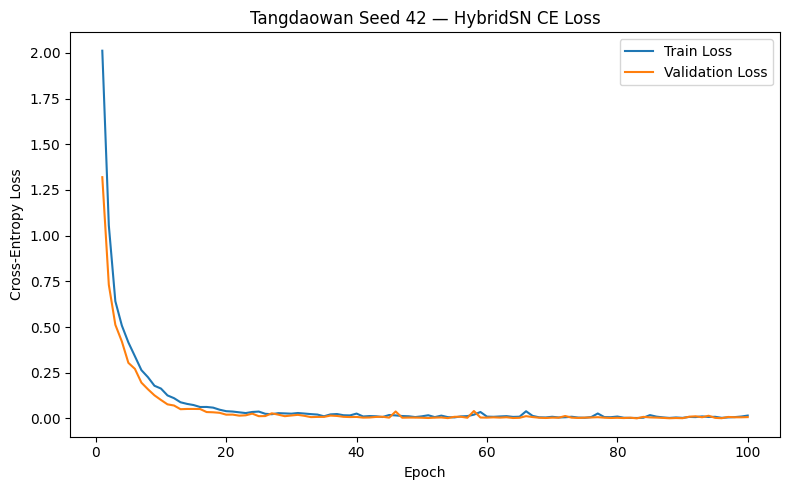

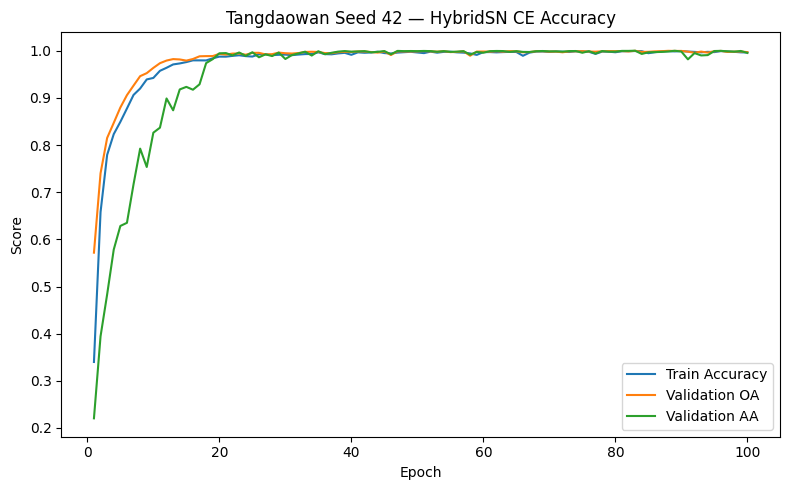

In [38]:
# ============================================================
# CELL 45 — TANGDAOWAN SEED-42 TRAINING CURVES
# ============================================================

history_df = (
    TANGDAOWAN_SEED42_RUN[
        "history"
    ]
)


# ------------------------------------------------------------
# Loss curve
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Cross-Entropy Loss"
)

plt.title(
    "Tangdaowan Seed 42 — HybridSN CE Loss"
)

plt.legend()

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Accuracy curves
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_oa"],
    label="Validation OA"
)

plt.plot(
    history_df["epoch"],
    history_df["val_aa"],
    label="Validation AA"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Tangdaowan Seed 42 — HybridSN CE Accuracy"
)

plt.legend()

plt.tight_layout()

plt.show()

In [39]:
# ============================================================
# CELL 46 — FREEZE NOTEBOOK 03 CE EXPERIMENT MATRIX
# ============================================================

CE_EXPERIMENT_MATRIX = []

for dataset_name in [
    "Pingan",
    "Qingyun",
    "Tangdaowan",
]:

    for seed in TRAINING_SEEDS:

        CE_EXPERIMENT_MATRIX.append({

            "dataset":
                dataset_name,

            "seed":
                int(seed),

            "epochs":
                int(
                    CE_TRAINING_CONFIG[
                        "epochs"
                    ]
                ),

            "checkpoint_policy":
                "best_validation_OA",

            "test_during_training":
                False,
        })


CE_EXPERIMENT_MATRIX_DF = pd.DataFrame(
    CE_EXPERIMENT_MATRIX
)


print("=" * 95)
print("FROZEN HYBRIDSN CE EXPERIMENT MATRIX")
print("=" * 95)

display(
    CE_EXPERIMENT_MATRIX_DF
)

print(
    "\nTotal required CE runs:",
    len(
        CE_EXPERIMENT_MATRIX_DF
    )
)

print(
    "Already completed      : 1"
)

print(
    "Remaining              : 8"
)

print("=" * 95)

FROZEN HYBRIDSN CE EXPERIMENT MATRIX


,dataset,seed,epochs,checkpoint_policy,test_during_training
0,Pingan,42,100,best_validation_OA,False
1,Pingan,123,100,best_validation_OA,False
2,Pingan,3407,100,best_validation_OA,False
3,Qingyun,42,100,best_validation_OA,False
4,Qingyun,123,100,best_validation_OA,False
5,Qingyun,3407,100,best_validation_OA,False
6,Tangdaowan,42,100,best_validation_OA,False
7,Tangdaowan,123,100,best_validation_OA,False
8,Tangdaowan,3407,100,best_validation_OA,False



Total required CE runs: 9
Already completed      : 1
Remaining              : 8


In [40]:
# ============================================================
# CELL 47 — FULL TANGDAOWAN CE | SEED 123
# ============================================================

torch.cuda.empty_cache()
gc.collect()


TANGDAOWAN_SEED123_RUN = (
    run_full_ce_training(

        dataset_name=
            "Tangdaowan",

        seed=
            123,

        epochs=
            CE_TRAINING_CONFIG[
                "epochs"
            ],

        verbose_every=
            10
    )
)

FULL CE TRAINING — TANGDAOWAN | SEED 123
Training samples   : 24760
Validation samples : 10612
Epochs             : 100
Batch size         : 256
Test evaluation    : DISABLED
Epoch 001/100 | TrainLoss=2.1141 | TrainAcc=0.2849 | ValLoss=1.8145 | ValOA=0.3669 | ValAA=0.1408 | F1=0.0970 | 3.3s | BEST
Epoch 002/100 | TrainLoss=1.7495 | TrainAcc=0.3977 | ValLoss=1.5358 | ValOA=0.4682 | ValAA=0.1796 | F1=0.1461 | 2.4s | BEST
Epoch 003/100 | TrainLoss=1.2166 | TrainAcc=0.6050 | ValLoss=0.7914 | ValOA=0.7377 | ValAA=0.3868 | F1=0.3798 | 2.4s | BEST
Epoch 004/100 | TrainLoss=0.6984 | TrainAcc=0.7631 | ValLoss=0.4959 | ValOA=0.8145 | ValAA=0.4830 | F1=0.4746 | 2.7s | BEST
Epoch 005/100 | TrainLoss=0.5066 | TrainAcc=0.8147 | ValLoss=0.3979 | ValOA=0.8517 | ValAA=0.5255 | F1=0.5277 | 2.7s | BEST
Epoch 006/100 | TrainLoss=0.4135 | TrainAcc=0.8462 | ValLoss=0.3182 | ValOA=0.8835 | ValAA=0.6212 | F1=0.6364 | 2.4s | BEST
Epoch 007/100 | TrainLoss=0.3620 | TrainAcc=0.8676 | ValLoss=0.2660 | ValOA=0.904

In [41]:
# ============================================================
# CELL 48 — FULL TANGDAOWAN CE | SEED 3407
# ============================================================

torch.cuda.empty_cache()
gc.collect()


TANGDAOWAN_SEED3407_RUN = (
    run_full_ce_training(

        dataset_name=
            "Tangdaowan",

        seed=
            3407,

        epochs=
            CE_TRAINING_CONFIG[
                "epochs"
            ],

        verbose_every=
            10
    )
)

FULL CE TRAINING — TANGDAOWAN | SEED 3407
Training samples   : 24760
Validation samples : 10612
Epochs             : 100
Batch size         : 256
Test evaluation    : DISABLED
Epoch 001/100 | TrainLoss=1.8984 | TrainAcc=0.3878 | ValLoss=1.0427 | ValOA=0.6497 | ValAA=0.2812 | F1=0.2428 | 4.7s | BEST
Epoch 002/100 | TrainLoss=0.8598 | TrainAcc=0.7169 | ValLoss=0.5926 | ValOA=0.8021 | ValAA=0.4599 | F1=0.4581 | 2.4s | BEST
Epoch 003/100 | TrainLoss=0.5771 | TrainAcc=0.7964 | ValLoss=0.5166 | ValOA=0.8100 | ValAA=0.5041 | F1=0.4972 | 2.3s | BEST
Epoch 004/100 | TrainLoss=0.4804 | TrainAcc=0.8326 | ValLoss=0.3936 | ValOA=0.8525 | ValAA=0.6113 | F1=0.6015 | 2.3s | BEST
Epoch 005/100 | TrainLoss=0.3937 | TrainAcc=0.8561 | ValLoss=0.3214 | ValOA=0.8894 | ValAA=0.6983 | F1=0.7039 | 2.5s | BEST
Epoch 007/100 | TrainLoss=0.2715 | TrainAcc=0.8991 | ValLoss=0.2113 | ValOA=0.9202 | ValAA=0.7264 | F1=0.7309 | 2.4s | BEST
Epoch 008/100 | TrainLoss=0.2218 | TrainAcc=0.9206 | ValLoss=0.1605 | ValOA=0.94

In [42]:
# ============================================================
# CELL 49 — AUDIT ALL TANGDAOWAN CE RUNS
# ============================================================

TANGDAOWAN_RUN_AUDIT = {}


print("=" * 105)
print("TANGDAOWAN — THREE-SEED CE ARTIFACT AUDIT")
print("=" * 105)


for seed in TRAINING_SEEDS:

    checkpoint_path = (
        CHECKPOINT_DIR /
        f"tangdaowan_seed{seed}_best_valOA.pt"
    )

    history_path = (
        HISTORY_DIR /
        f"tangdaowan_seed{seed}_history.csv"
    )

    summary_path = (
        METRICS_DIR /
        f"tangdaowan_seed{seed}_best_validation.json"
    )


    checkpoint_exists = (
        checkpoint_path.exists()
    )

    history_exists = (
        history_path.exists()
    )

    summary_exists = (
        summary_path.exists()
    )


    if not all([
        checkpoint_exists,
        history_exists,
        summary_exists,
    ]):

        print(
            f"\nSEED {seed}: FAIL — missing artifact."
        )

        TANGDAOWAN_RUN_AUDIT[
            seed
        ] = False

        continue


    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False
    )

    history_df = pd.read_csv(
        history_path
    )

    with open(
        summary_path,
        "r",
        encoding="utf-8"
    ) as f:

        summary = json.load(f)


    epoch_count_pass = (
        len(history_df)
        ==
        CE_TRAINING_CONFIG[
            "epochs"
        ]
    )

    seed_pass = (
        int(
            checkpoint["seed"]
        )
        ==
        seed
    )

    dataset_pass = (
        checkpoint[
            "dataset"
        ]
        ==
        "Tangdaowan"
    )

    split_hash_pass = (
        checkpoint[
            "split_sha256"
        ]
        ==
        DATASETS[
            "Tangdaowan"
        ][
            "split_sha256"
        ]
    )

    cube_hash_pass = (
        checkpoint[
            "cube_sha256"
        ]
        ==
        DATASETS[
            "Tangdaowan"
        ][
            "normalized_cube_sha256"
        ]
    )

    no_test_pass = (
        checkpoint[
            "test_used_for_selection"
        ]
        is False
        and
        summary[
            "test_evaluated"
        ]
        is False
    )

    finite_history_pass = bool(
        np.isfinite(
            history_df[
                [
                    "train_loss",
                    "train_accuracy",
                    "val_loss",
                    "val_oa",
                    "val_aa",
                    "val_kappa",
                    "val_macro_f1",
                ]
            ].to_numpy()
        ).all()
    )


    best_epoch = int(
        checkpoint[
            "epoch"
        ]
    )

    best_epoch_pass = (
        1
        <=
        best_epoch
        <=
        100
    )


    overall_pass = all([

        checkpoint_exists,
        history_exists,
        summary_exists,
        epoch_count_pass,
        seed_pass,
        dataset_pass,
        split_hash_pass,
        cube_hash_pass,
        no_test_pass,
        finite_history_pass,
        best_epoch_pass,
    ])


    TANGDAOWAN_RUN_AUDIT[
        seed
    ] = overall_pass


    print(
        f"\nSEED {seed}"
    )

    print("-" * 70)

    print(
        "Checkpoint exists :",
        "PASS"
        if checkpoint_exists
        else "FAIL"
    )

    print(
        "History = 100     :",
        "PASS"
        if epoch_count_pass
        else "FAIL"
    )

    print(
        "Summary exists    :",
        "PASS"
        if summary_exists
        else "FAIL"
    )

    print(
        "Seed correct      :",
        "PASS"
        if seed_pass
        else "FAIL"
    )

    print(
        "Dataset correct   :",
        "PASS"
        if dataset_pass
        else "FAIL"
    )

    print(
        "Split SHA-256     :",
        "PASS"
        if split_hash_pass
        else "FAIL"
    )

    print(
        "Cube SHA-256      :",
        "PASS"
        if cube_hash_pass
        else "FAIL"
    )

    print(
        "No test usage     :",
        "PASS"
        if no_test_pass
        else "FAIL"
    )

    print(
        "Finite history    :",
        "PASS"
        if finite_history_pass
        else "FAIL"
    )

    print(
        "Best epoch        :",
        best_epoch
    )

    print(
        "STATUS            :",
        "PASS"
        if overall_pass
        else "FAIL"
    )


ALL_TANGDAOWAN_CE_RUNS_PASS = all(
    TANGDAOWAN_RUN_AUDIT.values()
)


print(
    "\n" + "=" * 105
)

print(
    "TANGDAOWAN THREE-SEED CE GATE:",
    "PASS"
    if ALL_TANGDAOWAN_CE_RUNS_PASS
    else "FAIL"
)

print("=" * 105)

TANGDAOWAN — THREE-SEED CE ARTIFACT AUDIT

SEED 42
----------------------------------------------------------------------
Checkpoint exists : PASS
History = 100     : PASS
Summary exists    : PASS
Seed correct      : PASS
Dataset correct   : PASS
Split SHA-256     : PASS
Cube SHA-256      : PASS
No test usage     : PASS
Finite history    : PASS
Best epoch        : 83
STATUS            : PASS

SEED 123
----------------------------------------------------------------------
Checkpoint exists : PASS
History = 100     : PASS
Summary exists    : PASS
Seed correct      : PASS
Dataset correct   : PASS
Split SHA-256     : PASS
Cube SHA-256      : PASS
No test usage     : PASS
Finite history    : PASS
Best epoch        : 70
STATUS            : PASS

SEED 3407
----------------------------------------------------------------------
Checkpoint exists : PASS
History = 100     : PASS
Summary exists    : PASS
Seed correct      : PASS
Dataset correct   : PASS
Split SHA-256     : PASS
Cube SHA-256      :

In [43]:
# ============================================================
# CELL 50 — TANGDAOWAN THREE-SEED VALIDATION SUMMARY
# ============================================================

tangdaowan_validation_records = []


for seed in TRAINING_SEEDS:

    summary_path = (
        METRICS_DIR /
        f"tangdaowan_seed{seed}_best_validation.json"
    )


    with open(
        summary_path,
        "r",
        encoding="utf-8"
    ) as f:

        summary = json.load(f)


    tangdaowan_validation_records.append({

        "seed":
            int(seed),

        "best_epoch":
            int(
                summary[
                    "best_epoch"
                ]
            ),

        "val_oa":
            float(
                summary[
                    "best_validation_oa"
                ]
            ),

        "val_aa":
            float(
                summary[
                    "best_validation_aa"
                ]
            ),

        "val_kappa":
            float(
                summary[
                    "best_validation_kappa"
                ]
            ),

        "val_macro_f1":
            float(
                summary[
                    "best_validation_macro_f1"
                ]
            ),

        "val_loss":
            float(
                summary[
                    "best_validation_loss"
                ]
            ),

        "training_minutes":
            float(
                summary[
                    "total_training_seconds"
                ]
                /
                60.0
            ),
    })


TANGDAOWAN_VALIDATION_DF = pd.DataFrame(
    tangdaowan_validation_records
)


print("=" * 100)
print("TANGDAOWAN — HYBRIDSN CE VALIDATION RESULTS")
print("=" * 100)

display(
    TANGDAOWAN_VALIDATION_DF
)


print("\nTHREE-SEED SUMMARY")
print("-" * 60)


for metric in [
    "val_oa",
    "val_aa",
    "val_kappa",
    "val_macro_f1",
]:

    values = (
        TANGDAOWAN_VALIDATION_DF[
            metric
        ].to_numpy()
    )

    print(
        f"{metric:15s}: "
        f"{values.mean():.6f} "
        f"± "
        f"{values.std(ddof=1):.6f}"
    )


print()
print(
    "IMPORTANT: These are VALIDATION results, "
    "not final test results."
)

TANGDAOWAN — HYBRIDSN CE VALIDATION RESULTS


,seed,best_epoch,val_oa,val_aa,val_kappa,val_macro_f1,val_loss,training_minutes
0,42,83,0.999812,0.999958,0.999781,0.998015,0.000806,4.320995
1,123,70,0.999717,0.999937,0.999671,0.999686,0.001120,4.394446
2,3407,72,0.999812,0.999958,0.999781,0.999768,0.000914,4.382217



THREE-SEED SUMMARY
------------------------------------------------------------
val_oa         : 0.999780 ± 0.000054
val_aa         : 0.999951 ± 0.000012
val_kappa      : 0.999744 ± 0.000063
val_macro_f1   : 0.999156 ± 0.000989

IMPORTANT: These are VALIDATION results, not final test results.


In [44]:
# ============================================================
# CELL 51 — FULL QINGYUN CE | SEED 42
# ============================================================

torch.cuda.empty_cache()
gc.collect()


QINGYUN_SEED42_RUN = (
    run_full_ce_training(

        dataset_name=
            "Qingyun",

        seed=
            42,

        epochs=
            CE_TRAINING_CONFIG[
                "epochs"
            ],

        verbose_every=
            10
    )
)

FULL CE TRAINING — QINGYUN | SEED 42
Training samples   : 66844
Validation samples : 28648
Epochs             : 100
Batch size         : 256
Test evaluation    : DISABLED
Epoch 001/100 | TrainLoss=0.6975 | TrainAcc=0.7222 | ValLoss=0.2611 | ValOA=0.9126 | ValAA=0.7802 | F1=0.7722 | 7.9s | BEST
Epoch 002/100 | TrainLoss=0.2143 | TrainAcc=0.9320 | ValLoss=0.1653 | ValOA=0.9444 | ValAA=0.8168 | F1=0.8223 | 6.1s | BEST
Epoch 003/100 | TrainLoss=0.1513 | TrainAcc=0.9513 | ValLoss=0.1048 | ValOA=0.9651 | ValAA=0.8680 | F1=0.8927 | 5.8s | BEST
Epoch 004/100 | TrainLoss=0.1061 | TrainAcc=0.9655 | ValLoss=0.0971 | ValOA=0.9677 | ValAA=0.9099 | F1=0.9300 | 5.7s | BEST
Epoch 005/100 | TrainLoss=0.0952 | TrainAcc=0.9697 | ValLoss=0.0938 | ValOA=0.9700 | ValAA=0.9161 | F1=0.9319 | 6.1s | BEST
Epoch 006/100 | TrainLoss=0.0639 | TrainAcc=0.9791 | ValLoss=0.0601 | ValOA=0.9814 | ValAA=0.9359 | F1=0.9551 | 5.5s | BEST
Epoch 007/100 | TrainLoss=0.0493 | TrainAcc=0.9846 | ValLoss=0.0493 | ValOA=0.9835 | 

In [45]:
# ============================================================
# CELL 52 — FULL QINGYUN CE | SEED 123
# ============================================================

torch.cuda.empty_cache()
gc.collect()


QINGYUN_SEED123_RUN = (
    run_full_ce_training(

        dataset_name=
            "Qingyun",

        seed=
            123,

        epochs=
            CE_TRAINING_CONFIG[
                "epochs"
            ],

        verbose_every=
            10
    )
)

FULL CE TRAINING — QINGYUN | SEED 123
Training samples   : 66844
Validation samples : 28648
Epochs             : 100
Batch size         : 256
Test evaluation    : DISABLED
Epoch 001/100 | TrainLoss=0.8911 | TrainAcc=0.6201 | ValLoss=0.3053 | ValOA=0.8995 | ValAA=0.7690 | F1=0.7438 | 6.0s | BEST
Epoch 002/100 | TrainLoss=0.2658 | TrainAcc=0.9142 | ValLoss=0.2639 | ValOA=0.9117 | ValAA=0.7775 | F1=0.7729 | 6.5s | BEST
Epoch 003/100 | TrainLoss=0.1830 | TrainAcc=0.9402 | ValLoss=0.1344 | ValOA=0.9536 | ValAA=0.8701 | F1=0.8927 | 5.7s | BEST
Epoch 004/100 | TrainLoss=0.1289 | TrainAcc=0.9590 | ValLoss=0.0918 | ValOA=0.9702 | ValAA=0.9143 | F1=0.9312 | 6.2s | BEST
Epoch 005/100 | TrainLoss=0.0926 | TrainAcc=0.9709 | ValLoss=0.0703 | ValOA=0.9762 | ValAA=0.9161 | F1=0.9406 | 5.9s | BEST
Epoch 006/100 | TrainLoss=0.0724 | TrainAcc=0.9772 | ValLoss=0.0581 | ValOA=0.9810 | ValAA=0.9449 | F1=0.9605 | 5.8s | BEST
Epoch 007/100 | TrainLoss=0.0577 | TrainAcc=0.9818 | ValLoss=0.0465 | ValOA=0.9845 |

In [46]:
# ============================================================
# CELL 53 — FULL QINGYUN CE | SEED 3407
# ============================================================

torch.cuda.empty_cache()
gc.collect()


QINGYUN_SEED3407_RUN = (
    run_full_ce_training(

        dataset_name=
            "Qingyun",

        seed=
            3407,

        epochs=
            CE_TRAINING_CONFIG[
                "epochs"
            ],

        verbose_every=
            10
    )
)

FULL CE TRAINING — QINGYUN | SEED 3407
Training samples   : 66844
Validation samples : 28648
Epochs             : 100
Batch size         : 256
Test evaluation    : DISABLED
Epoch 001/100 | TrainLoss=0.6341 | TrainAcc=0.7463 | ValLoss=0.2373 | ValOA=0.9171 | ValAA=0.7854 | F1=0.7770 | 8.7s | BEST
Epoch 002/100 | TrainLoss=0.2503 | TrainAcc=0.9163 | ValLoss=0.1970 | ValOA=0.9278 | ValAA=0.7919 | F1=0.7892 | 5.5s | BEST
Epoch 003/100 | TrainLoss=0.1793 | TrainAcc=0.9380 | ValLoss=0.1961 | ValOA=0.9335 | ValAA=0.8178 | F1=0.8350 | 6.3s | BEST
Epoch 004/100 | TrainLoss=0.1469 | TrainAcc=0.9490 | ValLoss=0.0934 | ValOA=0.9664 | ValAA=0.8764 | F1=0.8990 | 5.5s | BEST
Epoch 005/100 | TrainLoss=0.0975 | TrainAcc=0.9679 | ValLoss=0.0847 | ValOA=0.9731 | ValAA=0.9070 | F1=0.9276 | 6.3s | BEST
Epoch 007/100 | TrainLoss=0.0598 | TrainAcc=0.9809 | ValLoss=0.0438 | ValOA=0.9852 | ValAA=0.9400 | F1=0.9583 | 6.0s | BEST
Epoch 009/100 | TrainLoss=0.0466 | TrainAcc=0.9853 | ValLoss=0.0345 | ValOA=0.9881 

In [47]:
# ============================================================
# CELL 54 — AUDIT ALL QINGYUN CE RUNS
# ============================================================

QINGYUN_RUN_AUDIT = {}


print("=" * 105)
print("QINGYUN — THREE-SEED CE ARTIFACT AUDIT")
print("=" * 105)


for seed in TRAINING_SEEDS:

    checkpoint_path = (
        CHECKPOINT_DIR /
        f"qingyun_seed{seed}_best_valOA.pt"
    )

    history_path = (
        HISTORY_DIR /
        f"qingyun_seed{seed}_history.csv"
    )

    summary_path = (
        METRICS_DIR /
        f"qingyun_seed{seed}_best_validation.json"
    )


    checkpoint_exists = checkpoint_path.exists()
    history_exists = history_path.exists()
    summary_exists = summary_path.exists()


    if not all([
        checkpoint_exists,
        history_exists,
        summary_exists,
    ]):

        print(
            f"\nSEED {seed}: FAIL — missing artifact."
        )

        QINGYUN_RUN_AUDIT[
            seed
        ] = False

        continue


    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False
    )

    history_df = pd.read_csv(
        history_path
    )

    with open(
        summary_path,
        "r",
        encoding="utf-8"
    ) as f:

        summary = json.load(f)


    epoch_count_pass = (
        len(history_df)
        ==
        CE_TRAINING_CONFIG[
            "epochs"
        ]
    )

    seed_pass = (
        int(
            checkpoint["seed"]
        )
        ==
        seed
    )

    dataset_pass = (
        checkpoint[
            "dataset"
        ]
        ==
        "Qingyun"
    )

    split_hash_pass = (
        checkpoint[
            "split_sha256"
        ]
        ==
        DATASETS[
            "Qingyun"
        ][
            "split_sha256"
        ]
    )

    cube_hash_pass = (
        checkpoint[
            "cube_sha256"
        ]
        ==
        DATASETS[
            "Qingyun"
        ][
            "normalized_cube_sha256"
        ]
    )

    no_test_pass = (
        checkpoint[
            "test_used_for_selection"
        ]
        is False
        and
        summary[
            "test_evaluated"
        ]
        is False
    )

    finite_history_pass = bool(
        np.isfinite(
            history_df[
                [
                    "train_loss",
                    "train_accuracy",
                    "val_loss",
                    "val_oa",
                    "val_aa",
                    "val_kappa",
                    "val_macro_f1",
                ]
            ].to_numpy()
        ).all()
    )

    best_epoch = int(
        checkpoint[
            "epoch"
        ]
    )

    best_epoch_pass = (
        1
        <=
        best_epoch
        <=
        100
    )


    overall_pass = all([

        checkpoint_exists,
        history_exists,
        summary_exists,
        epoch_count_pass,
        seed_pass,
        dataset_pass,
        split_hash_pass,
        cube_hash_pass,
        no_test_pass,
        finite_history_pass,
        best_epoch_pass,
    ])


    QINGYUN_RUN_AUDIT[
        seed
    ] = overall_pass


    print(
        f"\nSEED {seed}"
    )

    print("-" * 70)

    print(
        "Checkpoint exists :",
        "PASS"
        if checkpoint_exists
        else "FAIL"
    )

    print(
        "History = 100     :",
        "PASS"
        if epoch_count_pass
        else "FAIL"
    )

    print(
        "Summary exists    :",
        "PASS"
        if summary_exists
        else "FAIL"
    )

    print(
        "Seed correct      :",
        "PASS"
        if seed_pass
        else "FAIL"
    )

    print(
        "Dataset correct   :",
        "PASS"
        if dataset_pass
        else "FAIL"
    )

    print(
        "Split SHA-256     :",
        "PASS"
        if split_hash_pass
        else "FAIL"
    )

    print(
        "Cube SHA-256      :",
        "PASS"
        if cube_hash_pass
        else "FAIL"
    )

    print(
        "No test usage     :",
        "PASS"
        if no_test_pass
        else "FAIL"
    )

    print(
        "Finite history    :",
        "PASS"
        if finite_history_pass
        else "FAIL"
    )

    print(
        "Best epoch        :",
        best_epoch
    )

    print(
        "STATUS            :",
        "PASS"
        if overall_pass
        else "FAIL"
    )


ALL_QINGYUN_CE_RUNS_PASS = all(
    QINGYUN_RUN_AUDIT.values()
)


print(
    "\n" + "=" * 105
)

print(
    "QINGYUN THREE-SEED CE GATE:",
    "PASS"
    if ALL_QINGYUN_CE_RUNS_PASS
    else "FAIL"
)

print("=" * 105)

QINGYUN — THREE-SEED CE ARTIFACT AUDIT

SEED 42
----------------------------------------------------------------------
Checkpoint exists : PASS
History = 100     : PASS
Summary exists    : PASS
Seed correct      : PASS
Dataset correct   : PASS
Split SHA-256     : PASS
Cube SHA-256      : PASS
No test usage     : PASS
Finite history    : PASS
Best epoch        : 97
STATUS            : PASS

SEED 123
----------------------------------------------------------------------
Checkpoint exists : PASS
History = 100     : PASS
Summary exists    : PASS
Seed correct      : PASS
Dataset correct   : PASS
Split SHA-256     : PASS
Cube SHA-256      : PASS
No test usage     : PASS
Finite history    : PASS
Best epoch        : 92
STATUS            : PASS

SEED 3407
----------------------------------------------------------------------
Checkpoint exists : PASS
History = 100     : PASS
Summary exists    : PASS
Seed correct      : PASS
Dataset correct   : PASS
Split SHA-256     : PASS
Cube SHA-256      : PA

In [48]:
# ============================================================
# CELL 55 — QINGYUN THREE-SEED VALIDATION SUMMARY
# ============================================================

qingyun_validation_records = []


for seed in TRAINING_SEEDS:

    summary_path = (
        METRICS_DIR /
        f"qingyun_seed{seed}_best_validation.json"
    )


    with open(
        summary_path,
        "r",
        encoding="utf-8"
    ) as f:

        summary = json.load(f)


    qingyun_validation_records.append({

        "seed":
            int(seed),

        "best_epoch":
            int(
                summary[
                    "best_epoch"
                ]
            ),

        "val_oa":
            float(
                summary[
                    "best_validation_oa"
                ]
            ),

        "val_aa":
            float(
                summary[
                    "best_validation_aa"
                ]
            ),

        "val_kappa":
            float(
                summary[
                    "best_validation_kappa"
                ]
            ),

        "val_macro_f1":
            float(
                summary[
                    "best_validation_macro_f1"
                ]
            ),

        "val_loss":
            float(
                summary[
                    "best_validation_loss"
                ]
            ),

        "training_minutes":
            float(
                summary[
                    "total_training_seconds"
                ]
                /
                60.0
            ),
    })


QINGYUN_VALIDATION_DF = pd.DataFrame(
    qingyun_validation_records
)


print("=" * 100)
print("QINGYUN — HYBRIDSN CE VALIDATION RESULTS")
print("=" * 100)

display(
    QINGYUN_VALIDATION_DF
)


print("\nTHREE-SEED SUMMARY")
print("-" * 60)


for metric in [
    "val_oa",
    "val_aa",
    "val_kappa",
    "val_macro_f1",
]:

    values = (
        QINGYUN_VALIDATION_DF[
            metric
        ].to_numpy()
    )

    print(
        f"{metric:15s}: "
        f"{values.mean():.6f} "
        f"± "
        f"{values.std(ddof=1):.6f}"
    )


print()
print(
    "IMPORTANT: These are VALIDATION results, "
    "not final test results."
)

QINGYUN — HYBRIDSN CE VALIDATION RESULTS


,seed,best_epoch,val_oa,val_aa,val_kappa,val_macro_f1,val_loss,training_minutes
0,42,97,0.999756,0.998692,0.999677,0.999081,0.002044,10.060207
1,123,92,0.999825,0.999494,0.999769,0.999691,0.000750,10.168459
2,3407,88,0.999825,0.998751,0.999769,0.999120,0.002391,10.112343



THREE-SEED SUMMARY
------------------------------------------------------------
val_oa         : 0.999802 ± 0.000040
val_aa         : 0.998979 ± 0.000447
val_kappa      : 0.999738 ± 0.000053
val_macro_f1   : 0.999298 ± 0.000342

IMPORTANT: These are VALIDATION results, not final test results.


In [49]:
# ============================================================
# CELL 56 — FULL PINGAN CE | SEED 42
# ============================================================

torch.cuda.empty_cache()
gc.collect()


PINGAN_SEED42_RUN = (
    run_full_ce_training(

        dataset_name=
            "Pingan",

        seed=
            42,

        epochs=
            CE_TRAINING_CONFIG[
                "epochs"
            ],

        verbose_every=
            10
    )
)

FULL CE TRAINING — PINGAN | SEED 42
Training samples   : 79869
Validation samples : 34230
Epochs             : 100
Batch size         : 256
Test evaluation    : DISABLED
Epoch 001/100 | TrainLoss=0.5751 | TrainAcc=0.8105 | ValLoss=0.2330 | ValOA=0.9243 | ValAA=0.7270 | F1=0.7012 | 11.4s | BEST
Epoch 002/100 | TrainLoss=0.1745 | TrainAcc=0.9476 | ValLoss=0.1198 | ValOA=0.9611 | ValAA=0.8415 | F1=0.8528 | 8.4s | BEST
Epoch 003/100 | TrainLoss=0.0911 | TrainAcc=0.9714 | ValLoss=0.0455 | ValOA=0.9857 | ValAA=0.9452 | F1=0.9455 | 7.8s | BEST
Epoch 004/100 | TrainLoss=0.0620 | TrainAcc=0.9806 | ValLoss=0.0336 | ValOA=0.9882 | ValAA=0.9417 | F1=0.9549 | 8.5s | BEST
Epoch 005/100 | TrainLoss=0.0403 | TrainAcc=0.9869 | ValLoss=0.0241 | ValOA=0.9919 | ValAA=0.9729 | F1=0.9725 | 8.4s | BEST
Epoch 006/100 | TrainLoss=0.0310 | TrainAcc=0.9898 | ValLoss=0.0118 | ValOA=0.9961 | ValAA=0.9797 | F1=0.9839 | 7.9s | BEST
Epoch 008/100 | TrainLoss=0.0206 | TrainAcc=0.9931 | ValLoss=0.0083 | ValOA=0.9978 | 

In [50]:
# ============================================================
# CELL 57 — FULL PINGAN CE | SEED 123
# ============================================================

torch.cuda.empty_cache()
gc.collect()


PINGAN_SEED123_RUN = (
    run_full_ce_training(

        dataset_name=
            "Pingan",

        seed=
            123,

        epochs=
            CE_TRAINING_CONFIG[
                "epochs"
            ],

        verbose_every=
            10
    )
)

FULL CE TRAINING — PINGAN | SEED 123
Training samples   : 79869
Validation samples : 34230
Epochs             : 100
Batch size         : 256
Test evaluation    : DISABLED
Epoch 001/100 | TrainLoss=0.7078 | TrainAcc=0.7755 | ValLoss=0.3714 | ValOA=0.8810 | ValAA=0.4603 | F1=0.4503 | 9.7s | BEST
Epoch 002/100 | TrainLoss=0.4187 | TrainAcc=0.8679 | ValLoss=0.2522 | ValOA=0.9228 | ValAA=0.6720 | F1=0.6875 | 8.1s | BEST
Epoch 003/100 | TrainLoss=0.2251 | TrainAcc=0.9287 | ValLoss=0.1618 | ValOA=0.9435 | ValAA=0.8342 | F1=0.8136 | 8.6s | BEST
Epoch 004/100 | TrainLoss=0.1502 | TrainAcc=0.9510 | ValLoss=0.0913 | ValOA=0.9697 | ValAA=0.8755 | F1=0.8898 | 8.7s | BEST
Epoch 005/100 | TrainLoss=0.1073 | TrainAcc=0.9658 | ValLoss=0.0822 | ValOA=0.9710 | ValAA=0.9188 | F1=0.9026 | 7.9s | BEST
Epoch 006/100 | TrainLoss=0.0735 | TrainAcc=0.9759 | ValLoss=0.0522 | ValOA=0.9836 | ValAA=0.9132 | F1=0.9254 | 8.4s | BEST
Epoch 007/100 | TrainLoss=0.0575 | TrainAcc=0.9816 | ValLoss=0.0435 | ValOA=0.9855 | 

In [51]:
# ============================================================
# CELL 58 — FULL PINGAN CE | SEED 3407
# ============================================================

torch.cuda.empty_cache()
gc.collect()


PINGAN_SEED3407_RUN = (
    run_full_ce_training(

        dataset_name=
            "Pingan",

        seed=
            3407,

        epochs=
            CE_TRAINING_CONFIG[
                "epochs"
            ],

        verbose_every=
            10
    )
)

FULL CE TRAINING — PINGAN | SEED 3407
Training samples   : 79869
Validation samples : 34230
Epochs             : 100
Batch size         : 256
Test evaluation    : DISABLED
Epoch 001/100 | TrainLoss=0.6027 | TrainAcc=0.7990 | ValLoss=0.2941 | ValOA=0.9105 | ValAA=0.6213 | F1=0.6098 | 8.5s | BEST
Epoch 002/100 | TrainLoss=0.2153 | TrainAcc=0.9315 | ValLoss=0.1126 | ValOA=0.9633 | ValAA=0.8729 | F1=0.8827 | 8.3s | BEST
Epoch 003/100 | TrainLoss=0.1034 | TrainAcc=0.9668 | ValLoss=0.0616 | ValOA=0.9798 | ValAA=0.9281 | F1=0.9244 | 8.4s | BEST
Epoch 004/100 | TrainLoss=0.0621 | TrainAcc=0.9804 | ValLoss=0.0423 | ValOA=0.9853 | ValAA=0.9376 | F1=0.9542 | 7.9s | BEST
Epoch 005/100 | TrainLoss=0.0549 | TrainAcc=0.9825 | ValLoss=0.0249 | ValOA=0.9901 | ValAA=0.9526 | F1=0.9668 | 8.5s | BEST
Epoch 006/100 | TrainLoss=0.0366 | TrainAcc=0.9881 | ValLoss=0.0240 | ValOA=0.9919 | ValAA=0.9695 | F1=0.9725 | 8.0s | BEST
Epoch 007/100 | TrainLoss=0.0278 | TrainAcc=0.9914 | ValLoss=0.0133 | ValOA=0.9960 |

In [52]:
# ============================================================
# CELL 59 — AUDIT ALL PINGAN CE RUNS
# ============================================================

PINGAN_RUN_AUDIT = {}


print("=" * 105)
print("PINGAN — THREE-SEED CE ARTIFACT AUDIT")
print("=" * 105)


for seed in TRAINING_SEEDS:

    checkpoint_path = (
        CHECKPOINT_DIR /
        f"pingan_seed{seed}_best_valOA.pt"
    )

    history_path = (
        HISTORY_DIR /
        f"pingan_seed{seed}_history.csv"
    )

    summary_path = (
        METRICS_DIR /
        f"pingan_seed{seed}_best_validation.json"
    )


    checkpoint_exists = (
        checkpoint_path.exists()
    )

    history_exists = (
        history_path.exists()
    )

    summary_exists = (
        summary_path.exists()
    )


    if not all([
        checkpoint_exists,
        history_exists,
        summary_exists,
    ]):

        print(
            f"\nSEED {seed}: "
            f"FAIL — missing artifact."
        )

        PINGAN_RUN_AUDIT[
            seed
        ] = False

        continue


    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False
    )

    history_df = pd.read_csv(
        history_path
    )

    with open(
        summary_path,
        "r",
        encoding="utf-8"
    ) as f:

        summary = json.load(f)


    epoch_count_pass = (
        len(history_df)
        ==
        CE_TRAINING_CONFIG[
            "epochs"
        ]
    )

    seed_pass = (
        int(
            checkpoint["seed"]
        )
        ==
        seed
    )

    dataset_pass = (
        checkpoint[
            "dataset"
        ]
        ==
        "Pingan"
    )

    split_hash_pass = (
        checkpoint[
            "split_sha256"
        ]
        ==
        DATASETS[
            "Pingan"
        ][
            "split_sha256"
        ]
    )

    cube_hash_pass = (
        checkpoint[
            "cube_sha256"
        ]
        ==
        DATASETS[
            "Pingan"
        ][
            "normalized_cube_sha256"
        ]
    )

    no_test_pass = (
        checkpoint[
            "test_used_for_selection"
        ]
        is False
        and
        summary[
            "test_evaluated"
        ]
        is False
    )

    finite_history_pass = bool(
        np.isfinite(
            history_df[
                [
                    "train_loss",
                    "train_accuracy",
                    "val_loss",
                    "val_oa",
                    "val_aa",
                    "val_kappa",
                    "val_macro_f1",
                ]
            ].to_numpy()
        ).all()
    )

    best_epoch = int(
        checkpoint[
            "epoch"
        ]
    )

    best_epoch_pass = (
        1
        <=
        best_epoch
        <=
        100
    )


    overall_pass = all([

        checkpoint_exists,
        history_exists,
        summary_exists,
        epoch_count_pass,
        seed_pass,
        dataset_pass,
        split_hash_pass,
        cube_hash_pass,
        no_test_pass,
        finite_history_pass,
        best_epoch_pass,
    ])


    PINGAN_RUN_AUDIT[
        seed
    ] = overall_pass


    print(
        f"\nSEED {seed}"
    )

    print("-" * 70)

    print(
        "Checkpoint exists :",
        "PASS"
        if checkpoint_exists
        else "FAIL"
    )

    print(
        "History = 100     :",
        "PASS"
        if epoch_count_pass
        else "FAIL"
    )

    print(
        "Summary exists    :",
        "PASS"
        if summary_exists
        else "FAIL"
    )

    print(
        "Seed correct      :",
        "PASS"
        if seed_pass
        else "FAIL"
    )

    print(
        "Dataset correct   :",
        "PASS"
        if dataset_pass
        else "FAIL"
    )

    print(
        "Split SHA-256     :",
        "PASS"
        if split_hash_pass
        else "FAIL"
    )

    print(
        "Cube SHA-256      :",
        "PASS"
        if cube_hash_pass
        else "FAIL"
    )

    print(
        "No test usage     :",
        "PASS"
        if no_test_pass
        else "FAIL"
    )

    print(
        "Finite history    :",
        "PASS"
        if finite_history_pass
        else "FAIL"
    )

    print(
        "Best epoch        :",
        best_epoch
    )

    print(
        "STATUS            :",
        "PASS"
        if overall_pass
        else "FAIL"
    )


ALL_PINGAN_CE_RUNS_PASS = all(
    PINGAN_RUN_AUDIT.values()
)


print(
    "\n" + "=" * 105
)

print(
    "PINGAN THREE-SEED CE GATE:",
    "PASS"
    if ALL_PINGAN_CE_RUNS_PASS
    else "FAIL"
)

print("=" * 105)

PINGAN — THREE-SEED CE ARTIFACT AUDIT

SEED 42
----------------------------------------------------------------------
Checkpoint exists : PASS
History = 100     : PASS
Summary exists    : PASS
Seed correct      : PASS
Dataset correct   : PASS
Split SHA-256     : PASS
Cube SHA-256      : PASS
No test usage     : PASS
Finite history    : PASS
Best epoch        : 62
STATUS            : PASS

SEED 123
----------------------------------------------------------------------
Checkpoint exists : PASS
History = 100     : PASS
Summary exists    : PASS
Seed correct      : PASS
Dataset correct   : PASS
Split SHA-256     : PASS
Cube SHA-256      : PASS
No test usage     : PASS
Finite history    : PASS
Best epoch        : 94
STATUS            : PASS

SEED 3407
----------------------------------------------------------------------
Checkpoint exists : PASS
History = 100     : PASS
Summary exists    : PASS
Seed correct      : PASS
Dataset correct   : PASS
Split SHA-256     : PASS
Cube SHA-256      : PAS

In [53]:
# ============================================================
# CELL 60 — PINGAN THREE-SEED VALIDATION SUMMARY
# ============================================================

pingan_validation_records = []


for seed in TRAINING_SEEDS:

    summary_path = (
        METRICS_DIR /
        f"pingan_seed{seed}_best_validation.json"
    )


    with open(
        summary_path,
        "r",
        encoding="utf-8"
    ) as f:

        summary = json.load(f)


    pingan_validation_records.append({

        "seed":
            int(seed),

        "best_epoch":
            int(
                summary[
                    "best_epoch"
                ]
            ),

        "val_oa":
            float(
                summary[
                    "best_validation_oa"
                ]
            ),

        "val_aa":
            float(
                summary[
                    "best_validation_aa"
                ]
            ),

        "val_kappa":
            float(
                summary[
                    "best_validation_kappa"
                ]
            ),

        "val_macro_f1":
            float(
                summary[
                    "best_validation_macro_f1"
                ]
            ),

        "val_loss":
            float(
                summary[
                    "best_validation_loss"
                ]
            ),

        "training_minutes":
            float(
                summary[
                    "total_training_seconds"
                ]
                /
                60.0
            ),
    })


PINGAN_VALIDATION_DF = pd.DataFrame(
    pingan_validation_records
)


print("=" * 100)
print("PINGAN — HYBRIDSN CE VALIDATION RESULTS")
print("=" * 100)

display(
    PINGAN_VALIDATION_DF
)


print("\nTHREE-SEED SUMMARY")
print("-" * 60)


for metric in [
    "val_oa",
    "val_aa",
    "val_kappa",
    "val_macro_f1",
]:

    values = (
        PINGAN_VALIDATION_DF[
            metric
        ].to_numpy()
    )

    print(
        f"{metric:15s}: "
        f"{values.mean():.6f} "
        f"± "
        f"{values.std(ddof=1):.6f}"
    )


print()

print(
    "IMPORTANT: These are VALIDATION results, "
    "not final test results."
)

PINGAN — HYBRIDSN CE VALIDATION RESULTS


,seed,best_epoch,val_oa,val_aa,val_kappa,val_macro_f1,val_loss,training_minutes
0,42,62,0.999912,0.999983,0.999869,0.999889,0.000755,13.958673
1,123,94,0.999883,0.999790,0.999826,0.999852,0.000416,13.919520
2,3407,62,0.999854,0.999784,0.999782,0.999815,0.000272,14.046034



THREE-SEED SUMMARY
------------------------------------------------------------
val_oa         : 0.999883 ± 0.000029
val_aa         : 0.999852 ± 0.000113
val_kappa      : 0.999826 ± 0.000044
val_macro_f1   : 0.999852 ± 0.000037

IMPORTANT: These are VALIDATION results, not final test results.


In [54]:
# ============================================================
# CELL 61 — RECOMPUTE BEST CHECKPOINT FROM HISTORY
# ============================================================

def recompute_best_from_history(history_df):

    best = None

    for _, row in history_df.iterrows():

        candidate = {

            "epoch":
                int(row["epoch"]),

            "oa":
                float(row["val_oa"]),

            "aa":
                float(row["val_aa"]),

            "kappa":
                float(row["val_kappa"]),

            "macro_f1":
                float(row["val_macro_f1"]),

            "loss":
                float(row["val_loss"]),
        }

        if is_better_checkpoint(
            candidate,
            best
        ):

            best = candidate.copy()

    return best


print(
    "Independent checkpoint-history verifier created."
)

Independent checkpoint-history verifier created.


In [55]:
# ============================================================
# CELL 62 — CONSOLIDATED NINE-CHECKPOINT INTEGRITY AUDIT
# ============================================================

ALL_CE_RUN_AUDIT = {}

ce_audit_records = []


print("=" * 115)
print("ALL 9 HYBRIDSN CE CHECKPOINTS — CONSOLIDATED AUDIT")
print("=" * 115)


for dataset_name in [
    "Pingan",
    "Qingyun",
    "Tangdaowan",
]:

    cfg = DATASETS[
        dataset_name
    ]

    for seed in TRAINING_SEEDS:

        run_name = (
            f"{dataset_name.lower()}_seed{seed}"
        )

        checkpoint_path = (
            CHECKPOINT_DIR /
            f"{run_name}_best_valOA.pt"
        )

        history_path = (
            HISTORY_DIR /
            f"{run_name}_history.csv"
        )

        summary_path = (
            METRICS_DIR /
            f"{run_name}_best_validation.json"
        )


        # ----------------------------------------------------
        # Existence
        # ----------------------------------------------------

        files_exist_pass = all([
            checkpoint_path.exists(),
            history_path.exists(),
            summary_path.exists(),
        ])


        if not files_exist_pass:

            ALL_CE_RUN_AUDIT[
                (dataset_name, seed)
            ] = False

            print(
                f"\n{dataset_name} | Seed {seed}: "
                f"FAIL — missing artifact"
            )

            continue


        # ----------------------------------------------------
        # Reload completely from Drive
        # ----------------------------------------------------

        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=False
        )

        history_df = pd.read_csv(
            history_path
        )

        with open(
            summary_path,
            "r",
            encoding="utf-8"
        ) as f:

            summary = json.load(f)


        # ----------------------------------------------------
        # Independent best-checkpoint reconstruction
        # ----------------------------------------------------

        recomputed_best = (
            recompute_best_from_history(
                history_df
            )
        )

        saved_best = (
            checkpoint[
                "validation_metrics"
            ]
        )


        best_epoch_match = (
            int(
                checkpoint["epoch"]
            )
            ==
            int(
                recomputed_best["epoch"]
            )
        )

        best_oa_match = np.isclose(
            float(saved_best["oa"]),
            float(recomputed_best["oa"]),
            atol=1e-12
        )

        best_aa_match = np.isclose(
            float(saved_best["aa"]),
            float(recomputed_best["aa"]),
            atol=1e-12
        )

        best_loss_match = np.isclose(
            float(saved_best["loss"]),
            float(recomputed_best["loss"]),
            atol=1e-12
        )


        # ----------------------------------------------------
        # Protocol checks
        # ----------------------------------------------------

        epoch_count_pass = (
            len(history_df)
            ==
            CE_TRAINING_CONFIG[
                "epochs"
            ]
        )

        dataset_pass = (
            checkpoint[
                "dataset"
            ]
            ==
            dataset_name
        )

        seed_pass = (
            int(
                checkpoint["seed"]
            )
            ==
            int(seed)
        )

        split_hash_pass = (
            checkpoint[
                "split_sha256"
            ]
            ==
            cfg[
                "split_sha256"
            ]
        )

        cube_hash_pass = (
            checkpoint[
                "cube_sha256"
            ]
            ==
            cfg[
                "normalized_cube_sha256"
            ]
        )

        checkpoint_policy_pass = (
            checkpoint[
                "checkpoint_policy"
            ]
            ==
            "best_validation_OA"
        )

        no_test_selection_pass = (
            checkpoint[
                "test_used_for_selection"
            ]
            is False
            and
            summary[
                "test_evaluated"
            ]
            is False
        )


        # ----------------------------------------------------
        # Finite history
        # ----------------------------------------------------

        finite_history_pass = bool(

            np.isfinite(

                history_df[
                    [
                        "train_loss",
                        "train_accuracy",
                        "val_loss",
                        "val_oa",
                        "val_aa",
                        "val_kappa",
                        "val_macro_f1",
                        "learning_rate",
                    ]
                ].to_numpy()

            ).all()
        )


        # ----------------------------------------------------
        # Reload model and verify all weights finite
        # ----------------------------------------------------

        audit_model = HybridSN(

            spectral_depth=
                cfg[
                    "pca_components"
                ],

            patch_size=
                cfg[
                    "patch_size"
                ],

            num_classes=
                cfg[
                    "num_classes"
                ],

            dropout=
                CE_TRAINING_CONFIG[
                    "dropout"
                ],
        )


        audit_model.load_state_dict(
            checkpoint[
                "model_state_dict"
            ]
        )


        finite_weights_pass = all(

            bool(
                torch.isfinite(
                    tensor
                ).all()
            )

            for tensor
            in audit_model.state_dict().values()
        )


        # ----------------------------------------------------
        # Overall run audit
        # ----------------------------------------------------

        overall_pass = all([

            files_exist_pass,
            epoch_count_pass,
            dataset_pass,
            seed_pass,
            split_hash_pass,
            cube_hash_pass,
            checkpoint_policy_pass,
            no_test_selection_pass,
            finite_history_pass,
            finite_weights_pass,
            best_epoch_match,
            best_oa_match,
            best_aa_match,
            best_loss_match,
        ])


        ALL_CE_RUN_AUDIT[
            (dataset_name, seed)
        ] = overall_pass


        checkpoint_sha256 = (
            sha256_file(
                checkpoint_path
            )
        )


        ce_audit_records.append({

            "dataset":
                dataset_name,

            "seed":
                int(seed),

            "best_epoch":
                int(
                    checkpoint[
                        "epoch"
                    ]
                ),

            "val_oa":
                float(
                    saved_best["oa"]
                ),

            "val_aa":
                float(
                    saved_best["aa"]
                ),

            "val_kappa":
                float(
                    saved_best["kappa"]
                ),

            "val_macro_f1":
                float(
                    saved_best[
                        "macro_f1"
                    ]
                ),

            "val_loss":
                float(
                    saved_best["loss"]
                ),

            "checkpoint_sha256":
                checkpoint_sha256,

            "audit_pass":
                bool(overall_pass),
        })


        print(
            f"\n{dataset_name.upper():12s} | "
            f"SEED {seed}"
        )

        print("-" * 75)

        print(
            "100 epochs                 :",
            "PASS"
            if epoch_count_pass
            else "FAIL"
        )

        print(
            "Dataset / seed             :",
            "PASS"
            if dataset_pass and seed_pass
            else "FAIL"
        )

        print(
            "Frozen split SHA-256       :",
            "PASS"
            if split_hash_pass
            else "FAIL"
        )

        print(
            "Frozen cube SHA-256        :",
            "PASS"
            if cube_hash_pass
            else "FAIL"
        )

        print(
            "Checkpoint policy          :",
            "PASS"
            if checkpoint_policy_pass
            else "FAIL"
        )

        print(
            "No test used               :",
            "PASS"
            if no_test_selection_pass
            else "FAIL"
        )

        print(
            "Finite history             :",
            "PASS"
            if finite_history_pass
            else "FAIL"
        )

        print(
            "Finite model weights       :",
            "PASS"
            if finite_weights_pass
            else "FAIL"
        )

        print(
            "Best epoch independently   :",
            "PASS"
            if best_epoch_match
            else "FAIL",
            f"(epoch={checkpoint['epoch']})"
        )

        print(
            "Best OA independently      :",
            "PASS"
            if best_oa_match
            else "FAIL"
        )

        print(
            "Best AA independently      :",
            "PASS"
            if best_aa_match
            else "FAIL"
        )

        print(
            "Best loss independently    :",
            "PASS"
            if best_loss_match
            else "FAIL"
        )

        print(
            "STATUS                     :",
            "PASS"
            if overall_pass
            else "FAIL"
        )


        del audit_model
        del checkpoint

        gc.collect()


ALL_NINE_CE_RUNS_PASS = (

    len(
        ALL_CE_RUN_AUDIT
    )
    ==
    9

    and

    all(
        ALL_CE_RUN_AUDIT.values()
    )
)


print(
    "\n" + "=" * 115
)

print(
    "ALL 9 CE CHECKPOINT INTEGRITY GATE:",
    "PASS"
    if ALL_NINE_CE_RUNS_PASS
    else "FAIL"
)

print("=" * 115)

ALL 9 HYBRIDSN CE CHECKPOINTS — CONSOLIDATED AUDIT

PINGAN       | SEED 42
---------------------------------------------------------------------------
100 epochs                 : PASS
Dataset / seed             : PASS
Frozen split SHA-256       : PASS
Frozen cube SHA-256        : PASS
Checkpoint policy          : PASS
No test used               : PASS
Finite history             : PASS
Finite model weights       : PASS
Best epoch independently   : PASS (epoch=62)
Best OA independently      : PASS
Best AA independently      : PASS
Best loss independently    : PASS
STATUS                     : PASS

PINGAN       | SEED 123
---------------------------------------------------------------------------
100 epochs                 : PASS
Dataset / seed             : PASS
Frozen split SHA-256       : PASS
Frozen cube SHA-256        : PASS
Checkpoint policy          : PASS
No test used               : PASS
Finite history             : PASS
Finite model weights       : PASS
Best epoch independentl

In [56]:
# ============================================================
# CELL 63 — FREEZE NINE-CHECKPOINT MANIFEST
# ============================================================

CE_CHECKPOINT_MANIFEST_DF = pd.DataFrame(
    ce_audit_records
).sort_values(
    [
        "dataset",
        "seed",
    ]
).reset_index(
    drop=True
)


CE_CHECKPOINT_MANIFEST_CSV = (
    NOTEBOOK03_AUDIT_DIR /
    "ce_checkpoint_manifest.csv"
)

CE_CHECKPOINT_MANIFEST_JSON = (
    NOTEBOOK03_AUDIT_DIR /
    "ce_checkpoint_manifest.json"
)


CE_CHECKPOINT_MANIFEST_DF.to_csv(
    CE_CHECKPOINT_MANIFEST_CSV,
    index=False
)


manifest_json = {

    "project":
        "CSE498R LTLC",

    "method":
        "HybridSN_CE",

    "checkpoint_selection":
        "best_validation_OA",

    "training_seeds":
        TRAINING_SEEDS,

    "total_checkpoints":
        int(
            len(
                CE_CHECKPOINT_MANIFEST_DF
            )
        ),

    "official_test_evaluated_before_freeze":
        False,

    "all_checkpoint_audits_pass":
        bool(
            ALL_NINE_CE_RUNS_PASS
        ),

    "checkpoints":
        CE_CHECKPOINT_MANIFEST_DF.to_dict(
            orient="records"
        ),
}


with open(
    CE_CHECKPOINT_MANIFEST_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest_json,
        f,
        indent=2
    )


print("=" * 105)
print("FROZEN CE CHECKPOINT MANIFEST")
print("=" * 105)

display(
    CE_CHECKPOINT_MANIFEST_DF[
        [
            "dataset",
            "seed",
            "best_epoch",
            "val_oa",
            "val_aa",
            "val_macro_f1",
            "audit_pass",
        ]
    ]
)

print()

print(
    "Total frozen checkpoints:",
    len(
        CE_CHECKPOINT_MANIFEST_DF
    )
)

print(
    "CSV :",
    CE_CHECKPOINT_MANIFEST_CSV
)

print(
    "JSON:",
    CE_CHECKPOINT_MANIFEST_JSON
)

print("=" * 105)

FROZEN CE CHECKPOINT MANIFEST


,dataset,seed,best_epoch,val_oa,val_aa,val_macro_f1,audit_pass
0,Pingan,42,62,0.999912,0.999983,0.999889,True
1,Pingan,123,94,0.999883,0.999790,0.999852,True
2,Pingan,3407,62,0.999854,0.999784,0.999815,True
3,Qingyun,42,97,0.999756,0.998692,0.999081,True
4,Qingyun,123,92,0.999825,0.999494,0.999691,True
5,Qingyun,3407,88,0.999825,0.998751,0.999120,True
6,Tangdaowan,42,83,0.999812,0.999958,0.998015,True
7,Tangdaowan,123,70,0.999717,0.999937,0.999686,True
8,Tangdaowan,3407,72,0.999812,0.999958,0.999768,True



Total frozen checkpoints: 9
CSV : /content/drive/MyDrive/CSE498/LTLC/audit/notebook03_hybridsn/ce_checkpoint_manifest.csv
JSON: /content/drive/MyDrive/CSE498/LTLC/audit/notebook03_hybridsn/ce_checkpoint_manifest.json


In [57]:
# ============================================================
# CELL 64 — CLEAN-ROOM CHECKPOINT HASH VERIFICATION
# ============================================================

with open(
    CE_CHECKPOINT_MANIFEST_JSON,
    "r",
    encoding="utf-8"
) as f:

    frozen_manifest = json.load(f)


manifest_count_pass = (
    frozen_manifest[
        "total_checkpoints"
    ]
    ==
    9
)


manifest_audit_pass = (
    frozen_manifest[
        "all_checkpoint_audits_pass"
    ]
    is True
)


all_checkpoint_hashes_pass = True


print("=" * 110)
print("CLEAN-ROOM CHECKPOINT SHA-256 VERIFICATION")
print("=" * 110)


for record in frozen_manifest[
    "checkpoints"
]:

    dataset_name = (
        record[
            "dataset"
        ]
    )

    seed = int(
        record[
            "seed"
        ]
    )

    checkpoint_path = (

        CHECKPOINT_DIR /

        f"{dataset_name.lower()}_"
        f"seed{seed}_best_valOA.pt"
    )


    observed_hash = sha256_file(
        checkpoint_path
    )

    expected_hash = (
        record[
            "checkpoint_sha256"
        ]
    )

    hash_pass = (
        observed_hash
        ==
        expected_hash
    )


    all_checkpoint_hashes_pass &= (
        hash_pass
    )


    print(
        f"{dataset_name:12s} | "
        f"Seed {seed:4d} | "
        f"SHA-256: "
        f"{'PASS' if hash_pass else 'FAIL'}"
    )


FROZEN_CHECKPOINT_MANIFEST_PASS = all([

    manifest_count_pass,
    manifest_audit_pass,
    all_checkpoint_hashes_pass,
])


print(
    "\n" + "=" * 110
)

print(
    "Manifest contains 9 checkpoints :",
    "PASS"
    if manifest_count_pass
    else "FAIL"
)

print(
    "All original audits passed      :",
    "PASS"
    if manifest_audit_pass
    else "FAIL"
)

print(
    "All checkpoint hashes unchanged :",
    "PASS"
    if all_checkpoint_hashes_pass
    else "FAIL"
)

print()

print(
    "FROZEN CHECKPOINT MANIFEST GATE:",
    "PASS"
    if FROZEN_CHECKPOINT_MANIFEST_PASS
    else "FAIL"
)

print("=" * 110)

CLEAN-ROOM CHECKPOINT SHA-256 VERIFICATION
Pingan       | Seed   42 | SHA-256: PASS
Pingan       | Seed  123 | SHA-256: PASS
Pingan       | Seed 3407 | SHA-256: PASS
Qingyun      | Seed   42 | SHA-256: PASS
Qingyun      | Seed  123 | SHA-256: PASS
Qingyun      | Seed 3407 | SHA-256: PASS
Tangdaowan   | Seed   42 | SHA-256: PASS
Tangdaowan   | Seed  123 | SHA-256: PASS
Tangdaowan   | Seed 3407 | SHA-256: PASS

Manifest contains 9 checkpoints : PASS
All original audits passed      : PASS
All checkpoint hashes unchanged : PASS

FROZEN CHECKPOINT MANIFEST GATE: PASS


In [58]:
# ============================================================
# CELL 65 — OFFICIAL TEST ACCESS AUTHORIZATION GATE
# ============================================================

TEST_ACCESS_GATE_CHECKS = {

    "notebook01_frozen_inputs":
        bool(
            ALL_MODEL_INPUT_ARTIFACTS_PASS
        ),

    "pytorch_sample_pipeline":
        bool(
            ALL_PYTORCH_SAMPLE_AUDITS_PASS
        ),

    "cpu_dataloader":
        bool(
            ALL_DATALOADER_BATCH_AUDITS_PASS
        ),

    "gpu_transfer":
        bool(
            ALL_GPU_BATCH_AUDITS_PASS
        ),

    "hybridsn_architecture":
        bool(
            ALL_HYBRIDSN_ARCHITECTURE_PASS
        ),

    "ce_smoke_test":
        bool(
            ALL_CE_SMOKE_TESTS_PASS
        ),

    "pilot_checkpoint":
        bool(
            PILOT_CHECKPOINT_PASS
        ),

    "tangdaowan_three_seeds":
        bool(
            ALL_TANGDAOWAN_CE_RUNS_PASS
        ),

    "qingyun_three_seeds":
        bool(
            ALL_QINGYUN_CE_RUNS_PASS
        ),

    "pingan_three_seeds":
        bool(
            ALL_PINGAN_CE_RUNS_PASS
        ),

    "all_nine_checkpoint_integrity":
        bool(
            ALL_NINE_CE_RUNS_PASS
        ),

    "frozen_checkpoint_manifest":
        bool(
            FROZEN_CHECKPOINT_MANIFEST_PASS
        ),
}


print("=" * 115)
print("NOTEBOOK 03 — OFFICIAL TEST ACCESS AUTHORIZATION")
print("=" * 115)


for check_name, passed in (
    TEST_ACCESS_GATE_CHECKS.items()
):

    print(
        f"{'PASS' if passed else 'FAIL':5s} | "
        f"{check_name}"
    )


OFFICIAL_TEST_ACCESS_AUTHORIZED = all(
    TEST_ACCESS_GATE_CHECKS.values()
)


print("=" * 115)

print(
    "OFFICIAL TEST ACCESS:",
    "AUTHORIZED"
    if OFFICIAL_TEST_ACCESS_AUTHORIZED
    else "DENIED"
)


if OFFICIAL_TEST_ACCESS_AUTHORIZED:

    print()

    print(
        "All 9 validation-selected CE checkpoints "
        "are now frozen."
    )

    print(
        "Official test inference may begin."
    )

    print(
        "No retraining or checkpoint replacement is "
        "permitted after viewing test results."
    )

else:

    print()

    print(
        "STOP — DO NOT EVALUATE ANY OFFICIAL TEST SET."
    )


print("=" * 115)

NOTEBOOK 03 — OFFICIAL TEST ACCESS AUTHORIZATION
PASS  | notebook01_frozen_inputs
PASS  | pytorch_sample_pipeline
PASS  | cpu_dataloader
PASS  | gpu_transfer
PASS  | hybridsn_architecture
PASS  | ce_smoke_test
PASS  | pilot_checkpoint
PASS  | tangdaowan_three_seeds
PASS  | qingyun_three_seeds
PASS  | pingan_three_seeds
PASS  | all_nine_checkpoint_integrity
PASS  | frozen_checkpoint_manifest
OFFICIAL TEST ACCESS: AUTHORIZED

All 9 validation-selected CE checkpoints are now frozen.
Official test inference may begin.
No retraining or checkpoint replacement is permitted after viewing test results.


## Frozen Checkpoint Inference Protocol

All nine HybridSN CE checkpoints have been selected using validation data and
their SHA-256 hashes have been frozen.

From this point onward:

- no CE model is retrained;
- no checkpoint is replaced;
- no model is selected using official test performance.

For every frozen checkpoint, Notebook 03 will save:

### Validation outputs
- raw logits;
- predicted model labels;
- true model labels;
- immutable center-pixel indices.

These validation logits will later be used to fit post-hoc calibration
parameters.

### Official test outputs
- raw logits;
- predicted model labels;
- true model labels;
- immutable center-pixel indices.

The test logits are stored once and reused in later notebooks.

Calibration parameters must never be fitted using official test labels.

### Baseline metrics

For the unmodified CE model:

- Overall Accuracy (OA)
- Average Accuracy (AA)
- Cohen's Kappa
- Macro-F1
- per-class accuracy
- confusion matrix

are computed from the frozen official test predictions.

In [59]:
# ============================================================
# CELL 67 — FROZEN INFERENCE OUTPUT DIRECTORIES
# ============================================================

VALIDATION_LOGITS_DIR = (
    LOGITS_DIR /
    "validation"
)

TEST_LOGITS_DIR = (
    LOGITS_DIR /
    "official_test"
)

TEST_METRICS_DIR = (
    METRICS_DIR /
    "official_test"
)

INFERENCE_AUDIT_DIR = (
    NOTEBOOK03_AUDIT_DIR /
    "frozen_inference"
)


for path in [
    VALIDATION_LOGITS_DIR,
    TEST_LOGITS_DIR,
    TEST_METRICS_DIR,
    INFERENCE_AUDIT_DIR,
]:

    path.mkdir(
        parents=True,
        exist_ok=True
    )


print("=" * 90)
print("FROZEN INFERENCE DIRECTORIES")
print("=" * 90)

print(
    "Validation logits :",
    VALIDATION_LOGITS_DIR
)

print(
    "Official test     :",
    TEST_LOGITS_DIR
)

print(
    "Test metrics      :",
    TEST_METRICS_DIR
)

print(
    "Inference audits  :",
    INFERENCE_AUDIT_DIR
)

print("=" * 90)

FROZEN INFERENCE DIRECTORIES
Validation logits : /content/drive/MyDrive/CSE498/LTLC/runs/hybridsn_ce_baseline/logits/validation
Official test     : /content/drive/MyDrive/CSE498/LTLC/runs/hybridsn_ce_baseline/logits/official_test
Test metrics      : /content/drive/MyDrive/CSE498/LTLC/runs/hybridsn_ce_baseline/metrics/official_test
Inference audits  : /content/drive/MyDrive/CSE498/LTLC/audit/notebook03_hybridsn/frozen_inference


In [60]:
# ============================================================
# CELL 68 — FROZEN CHECKPOINT MANIFEST LOOKUP
# ============================================================

def get_frozen_checkpoint_record(
    dataset_name,
    seed
):

    matches = [

        record

        for record
        in frozen_manifest[
            "checkpoints"
        ]

        if (
            record[
                "dataset"
            ]
            ==
            dataset_name

            and

            int(
                record[
                    "seed"
                ]
            )
            ==
            int(seed)
        )
    ]


    if len(matches) != 1:

        raise RuntimeError(
            f"Expected exactly one frozen checkpoint for "
            f"{dataset_name}, seed {seed}; found {len(matches)}."
        )


    return matches[0]


print(
    "Frozen-checkpoint manifest lookup created."
)

Frozen-checkpoint manifest lookup created.


In [61]:
# ============================================================
# CELL 69 — SERIALIZE CLASSIFICATION METRICS
# ============================================================

def metrics_to_json_ready(
    metrics
):

    return {

        "loss":
            float(
                metrics[
                    "loss"
                ]
            ),

        "oa":
            float(
                metrics[
                    "oa"
                ]
            ),

        "aa":
            float(
                metrics[
                    "aa"
                ]
            ),

        "kappa":
            float(
                metrics[
                    "kappa"
                ]
            ),

        "macro_f1":
            float(
                metrics[
                    "macro_f1"
                ]
            ),

        "per_class_accuracy":

            np.asarray(
                metrics[
                    "per_class_accuracy"
                ]
            )
            .astype(float)
            .tolist(),

        "confusion_matrix":

            np.asarray(
                metrics[
                    "confusion_matrix"
                ]
            )
            .astype(int)
            .tolist(),
    }


print(
    "Metric JSON serializer created."
)

Metric JSON serializer created.


In [62]:
# ============================================================
# CELL 70 — FROZEN CHECKPOINT INFERENCE ENGINE
# ============================================================

def run_frozen_checkpoint_inference(
    dataset_name,
    seed,
    split_name
):

    if not OFFICIAL_TEST_ACCESS_AUTHORIZED:

        raise RuntimeError(
            "Official test access has not been authorized."
        )


    if split_name not in [
        "val",
        "test",
    ]:

        raise ValueError(
            "split_name must be 'val' or 'test'."
        )


    cfg = DATASETS[
        dataset_name
    ]


    # --------------------------------------------------------
    # Retrieve frozen manifest record
    # --------------------------------------------------------

    frozen_record = (
        get_frozen_checkpoint_record(
            dataset_name,
            seed
        )
    )


    checkpoint_path = (

        CHECKPOINT_DIR /

        f"{dataset_name.lower()}_"
        f"seed{seed}_best_valOA.pt"
    )


    if not checkpoint_path.exists():

        raise FileNotFoundError(
            checkpoint_path
        )


    # --------------------------------------------------------
    # Verify checkpoint SHA-256 BEFORE loading model
    # --------------------------------------------------------

    observed_checkpoint_hash = (
        sha256_file(
            checkpoint_path
        )
    )

    expected_checkpoint_hash = (
        frozen_record[
            "checkpoint_sha256"
        ]
    )


    checkpoint_hash_pass = (
        observed_checkpoint_hash
        ==
        expected_checkpoint_hash
    )


    if not checkpoint_hash_pass:

        raise RuntimeError(
            f"Frozen checkpoint hash mismatch: "
            f"{dataset_name}, seed {seed}"
        )


    # --------------------------------------------------------
    # Load frozen checkpoint
    # --------------------------------------------------------

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False
    )


    checkpoint_policy_pass = (
        checkpoint[
            "checkpoint_policy"
        ]
        ==
        "best_validation_OA"
    )


    no_test_selection_pass = (
        checkpoint[
            "test_used_for_selection"
        ]
        is False
    )


    if not all([
        checkpoint_policy_pass,
        no_test_selection_pass,
    ]):

        raise RuntimeError(
            "Frozen checkpoint protocol check failed."
        )


    # --------------------------------------------------------
    # Reconstruct model
    # --------------------------------------------------------

    model = HybridSN(

        spectral_depth=
            cfg[
                "pca_components"
            ],

        patch_size=
            cfg[
                "patch_size"
            ],

        num_classes=
            cfg[
                "num_classes"
            ],

        dropout=
            CE_TRAINING_CONFIG[
                "dropout"
            ],

    ).to(
        DEVICE
    )


    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )


    criterion = nn.CrossEntropyLoss()


    # --------------------------------------------------------
    # Deterministic ordered loader
    # --------------------------------------------------------

    loaders = build_dataloaders(
        dataset_name,
        seed
    )


    loader = loaders[
        split_name
    ]


    # --------------------------------------------------------
    # Expected immutable arrays
    # --------------------------------------------------------

    if split_name == "val":

        expected_indices = (
            FROZEN_SPLITS[
                dataset_name
            ][
                "val_indices"
            ]
        )

        expected_labels = (
            FROZEN_SPLITS[
                dataset_name
            ][
                "val_labels_model"
            ]
        )

    else:

        expected_indices = (
            FROZEN_SPLITS[
                dataset_name
            ][
                "test_indices"
            ]
        )

        expected_labels = (
            FROZEN_SPLITS[
                dataset_name
            ][
                "test_labels_model"
            ]
        )


    # --------------------------------------------------------
    # Run inference
    # --------------------------------------------------------

    start_time = (
        time.time()
    )


    result = evaluate_model(

        model=model,

        loader=loader,

        criterion=criterion,

        num_classes=
            cfg[
                "num_classes"
            ],

        device=DEVICE
    )


    inference_seconds = (
        time.time()
        -
        start_time
    )


    # --------------------------------------------------------
    # Strict output integrity checks
    # --------------------------------------------------------

    index_order_pass = (
        np.array_equal(
            result[
                "indices"
            ],
            expected_indices
        )
    )


    label_order_pass = (
        np.array_equal(
            result[
                "labels"
            ],
            expected_labels
        )
    )


    sample_count_pass = (
        len(
            result[
                "indices"
            ]
        )
        ==
        len(
            expected_indices
        )
    )


    logits_shape_pass = (

        result[
            "logits"
        ].shape

        ==

        (
            len(
                expected_indices
            ),
            cfg[
                "num_classes"
            ],
        )
    )


    logits_dtype_pass = (
        result[
            "logits"
        ].dtype
        ==
        np.float32
    )


    logits_finite_pass = bool(

        np.isfinite(
            result[
                "logits"
            ]
        ).all()
    )


    prediction_match_pass = (
        np.array_equal(

            result[
                "predictions"
            ],

            np.argmax(
                result[
                    "logits"
                ],
                axis=1
            )
        )
    )


    integrity_pass = all([

        checkpoint_hash_pass,
        index_order_pass,
        label_order_pass,
        sample_count_pass,
        logits_shape_pass,
        logits_dtype_pass,
        logits_finite_pass,
        prediction_match_pass,
    ])


    if not integrity_pass:

        raise RuntimeError(
            f"Inference integrity failure for "
            f"{dataset_name}, seed {seed}, {split_name}."
        )


    # --------------------------------------------------------
    # Save raw inference arrays
    # --------------------------------------------------------

    if split_name == "val":

        output_path = (

            VALIDATION_LOGITS_DIR /

            f"{dataset_name.lower()}_"
            f"seed{seed}_validation_outputs.npz"
        )

    else:

        output_path = (

            TEST_LOGITS_DIR /

            f"{dataset_name.lower()}_"
            f"seed{seed}_official_test_outputs.npz"
        )


    np.savez_compressed(

        output_path,

        logits=
            result[
                "logits"
            ].astype(
                np.float32,
                copy=False
            ),

        predictions=
            result[
                "predictions"
            ].astype(
                np.int64,
                copy=False
            ),

        labels=
            result[
                "labels"
            ].astype(
                np.int64,
                copy=False
            ),

        indices=
            result[
                "indices"
            ].astype(
                np.int64,
                copy=False
            ),
    )


    output_sha256 = (
        sha256_file(
            output_path
        )
    )


    # --------------------------------------------------------
    # Save metrics
    # --------------------------------------------------------

    metrics_json = (
        metrics_to_json_ready(
            result[
                "metrics"
            ]
        )
    )


    metrics_json.update({

        "project":
            "CSE498R LTLC",

        "method":
            "HybridSN_CE",

        "dataset":
            dataset_name,

        "seed":
            int(seed),

        "split":
            split_name,

        "checkpoint_epoch":
            int(
                checkpoint[
                    "epoch"
                ]
            ),

        "checkpoint_sha256":
            expected_checkpoint_hash,

        "output_file":
            output_path.name,

        "output_sha256":
            output_sha256,

        "samples":
            int(
                len(
                    result[
                        "indices"
                    ]
                )
            ),

        "inference_seconds":
            float(
                inference_seconds
            ),

        "index_order_verified":
            bool(
                index_order_pass
            ),

        "label_order_verified":
            bool(
                label_order_pass
            ),

        "test_used_for_selection":
            False,
    })


    if split_name == "test":

        metrics_path = (

            TEST_METRICS_DIR /

            f"{dataset_name.lower()}_"
            f"seed{seed}_official_test_metrics.json"
        )

    else:

        metrics_path = (

            METRICS_DIR /

            f"{dataset_name.lower()}_"
            f"seed{seed}_validation_inference_metrics.json"
        )


    with open(
        metrics_path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            metrics_json,
            f,
            indent=2
        )


    # --------------------------------------------------------
    # Console summary
    # --------------------------------------------------------

    print("=" * 105)

    print(
        f"{dataset_name.upper()} | "
        f"SEED {seed} | "
        f"{split_name.upper()} INFERENCE"
    )

    print("=" * 105)

    print(
        "Frozen checkpoint SHA : PASS"
    )

    print(
        "Sample count          :",
        len(
            result[
                "indices"
            ]
        )
    )

    print(
        "Index order exact     :",
        "PASS"
        if index_order_pass
        else "FAIL"
    )

    print(
        "Label order exact     :",
        "PASS"
        if label_order_pass
        else "FAIL"
    )

    print(
        "Logits shape          :",
        result[
            "logits"
        ].shape
    )

    print(
        "Logits float32        :",
        "PASS"
        if logits_dtype_pass
        else "FAIL"
    )

    print(
        "Finite logits         :",
        "PASS"
        if logits_finite_pass
        else "FAIL"
    )

    print(
        "Argmax predictions    :",
        "PASS"
        if prediction_match_pass
        else "FAIL"
    )

    print()

    print(
        f"Loss                  : "
        f"{metrics_json['loss']:.6f}"
    )

    print(
        f"OA                    : "
        f"{metrics_json['oa']:.6f}"
    )

    print(
        f"AA                    : "
        f"{metrics_json['aa']:.6f}"
    )

    print(
        f"Kappa                 : "
        f"{metrics_json['kappa']:.6f}"
    )

    print(
        f"Macro-F1              : "
        f"{metrics_json['macro_f1']:.6f}"
    )

    print(
        f"Inference time        : "
        f"{inference_seconds:.2f} s"
    )

    print()

    print(
        "Saved outputs         :",
        output_path
    )

    print(
        "Output SHA-256        :",
        output_sha256
    )

    print()

    print(
        "INFERENCE STATUS      : PASS"
    )

    print("=" * 105)


    # --------------------------------------------------------
    # Return compact metadata only.
    # Do not keep million-sample arrays in notebook memory.
    # --------------------------------------------------------

    compact_result = {

        "dataset":
            dataset_name,

        "seed":
            int(seed),

        "split":
            split_name,

        "metrics":
            metrics_json,

        "output_path":
            output_path,

        "metrics_path":
            metrics_path,

        "output_sha256":
            output_sha256,

        "passed":
            True,
    }


    del model
    del checkpoint
    del result

    torch.cuda.empty_cache()
    gc.collect()


    return compact_result


print(
    "Frozen checkpoint inference engine created."
)

Frozen checkpoint inference engine created.


In [63]:
# ============================================================
# CELL 71 — TANGDAOWAN VALIDATION LOGITS | ALL THREE SEEDS
# ============================================================

TANGDAOWAN_VAL_INFERENCE = {}


for seed in TRAINING_SEEDS:

    torch.cuda.empty_cache()
    gc.collect()

    result = run_frozen_checkpoint_inference(

        dataset_name=
            "Tangdaowan",

        seed=
            seed,

        split_name=
            "val"
    )

    TANGDAOWAN_VAL_INFERENCE[
        seed
    ] = result

TANGDAOWAN | SEED 42 | VAL INFERENCE
Frozen checkpoint SHA : PASS
Sample count          : 10612
Index order exact     : PASS
Label order exact     : PASS
Logits shape          : (10612, 16)
Logits float32        : PASS
Finite logits         : PASS
Argmax predictions    : PASS

Loss                  : 0.000806
OA                    : 0.999812
AA                    : 0.999958
Kappa                 : 0.999781
Macro-F1              : 0.998015
Inference time        : 0.78 s

Saved outputs         : /content/drive/MyDrive/CSE498/LTLC/runs/hybridsn_ce_baseline/logits/validation/tangdaowan_seed42_validation_outputs.npz
Output SHA-256        : 54d8e542813008b87af9d5682560c198cfe46fa00397c63bb0f5cf049d64f1e9

INFERENCE STATUS      : PASS
TANGDAOWAN | SEED 123 | VAL INFERENCE
Frozen checkpoint SHA : PASS
Sample count          : 10612
Index order exact     : PASS
Label order exact     : PASS
Logits shape          : (10612, 16)
Logits float32        : PASS
Finite logits         : PASS
Argmax predic

In [64]:
# ============================================================
# CELL 72 — TANGDAOWAN OFFICIAL TEST | ALL THREE SEEDS
# ============================================================

TANGDAOWAN_TEST_INFERENCE = {}


for seed in TRAINING_SEEDS:

    torch.cuda.empty_cache()
    gc.collect()

    result = run_frozen_checkpoint_inference(

        dataset_name=
            "Tangdaowan",

        seed=
            seed,

        split_name=
            "test"
    )

    TANGDAOWAN_TEST_INFERENCE[
        seed
    ] = result

TANGDAOWAN | SEED 42 | TEST INFERENCE
Frozen checkpoint SHA : PASS
Sample count          : 469917
Index order exact     : PASS
Label order exact     : PASS
Logits shape          : (469917, 16)
Logits float32        : PASS
Finite logits         : PASS
Argmax predictions    : PASS

Loss                  : 1.693879
OA                    : 0.879485
AA                    : 0.840841
Kappa                 : 0.860258
Macro-F1              : 0.818785
Inference time        : 23.73 s

Saved outputs         : /content/drive/MyDrive/CSE498/LTLC/runs/hybridsn_ce_baseline/logits/official_test/tangdaowan_seed42_official_test_outputs.npz
Output SHA-256        : c7fc6208c2cb1efad10c6f5f00665f64228919dbbe96eb8bedc6b4e06c23321b

INFERENCE STATUS      : PASS
TANGDAOWAN | SEED 123 | TEST INFERENCE
Frozen checkpoint SHA : PASS
Sample count          : 469917
Index order exact     : PASS
Label order exact     : PASS
Logits shape          : (469917, 16)
Logits float32        : PASS
Finite logits         : PASS


In [65]:
# ============================================================
# CELL 73 — TANGDAOWAN OFFICIAL TEST THREE-SEED SUMMARY
# ============================================================

tangdaowan_test_records = []


for seed in TRAINING_SEEDS:

    metrics = (
        TANGDAOWAN_TEST_INFERENCE[
            seed
        ][
            "metrics"
        ]
    )


    tangdaowan_test_records.append({

        "seed":
            int(seed),

        "checkpoint_epoch":
            int(
                metrics[
                    "checkpoint_epoch"
                ]
            ),

        "test_oa":
            float(
                metrics[
                    "oa"
                ]
            ),

        "test_aa":
            float(
                metrics[
                    "aa"
                ]
            ),

        "test_kappa":
            float(
                metrics[
                    "kappa"
                ]
            ),

        "test_macro_f1":
            float(
                metrics[
                    "macro_f1"
                ]
            ),

        "test_loss":
            float(
                metrics[
                    "loss"
                ]
            ),

        "inference_seconds":
            float(
                metrics[
                    "inference_seconds"
                ]
            ),
    })


TANGDAOWAN_TEST_DF = pd.DataFrame(
    tangdaowan_test_records
)


print("=" * 105)

print(
    "TANGDAOWAN — OFFICIAL PUBLIC-MASK TEST RESULTS"
)

print("=" * 105)


display(
    TANGDAOWAN_TEST_DF
)


print(
    "\nTHREE-SEED TEST SUMMARY"
)

print("-" * 65)


for metric in [
    "test_oa",
    "test_aa",
    "test_kappa",
    "test_macro_f1",
]:

    values = (
        TANGDAOWAN_TEST_DF[
            metric
        ].to_numpy()
    )

    print(

        f"{metric:18s}: "

        f"{values.mean():.6f} "
        f"± "
        f"{values.std(ddof=1):.6f}"
    )


print()

print(
    "Protocol note: Tangdaowan evaluation uses "
    "the 16 classes present in the public train/test masks."
)

TANGDAOWAN — OFFICIAL PUBLIC-MASK TEST RESULTS


,seed,checkpoint_epoch,test_oa,test_aa,test_kappa,test_macro_f1,test_loss,inference_seconds
0,42,83,0.879485,0.840841,0.860258,0.818785,1.693879,23.731704
1,123,70,0.884643,0.861446,0.866264,0.826916,1.441853,24.378177
2,3407,72,0.862510,0.836900,0.841012,0.791021,1.661763,24.237996



THREE-SEED TEST SUMMARY
-----------------------------------------------------------------
test_oa           : 0.875546 ± 0.011581
test_aa           : 0.846395 ± 0.013182
test_kappa        : 0.855845 ± 0.013192
test_macro_f1     : 0.812241 ± 0.018821

Protocol note: Tangdaowan evaluation uses the 16 classes present in the public train/test masks.


In [66]:
# ============================================================
# CELL 74 — TANGDAOWAN SAVED LOGIT ARTIFACT AUDIT
# ============================================================

TANGDAOWAN_LOGIT_AUDIT = {}


print("=" * 110)
print("TANGDAOWAN — SAVED VALIDATION/TEST OUTPUT AUDIT")
print("=" * 110)


for seed in TRAINING_SEEDS:

    seed_checks = []


    for split_name in [
        "validation",
        "official_test",
    ]:

        if split_name == "validation":

            path = (

                VALIDATION_LOGITS_DIR /

                f"tangdaowan_seed{seed}_"
                f"validation_outputs.npz"
            )

            expected_indices = (
                FROZEN_SPLITS[
                    "Tangdaowan"
                ][
                    "val_indices"
                ]
            )

            expected_labels = (
                FROZEN_SPLITS[
                    "Tangdaowan"
                ][
                    "val_labels_model"
                ]
            )

        else:

            path = (

                TEST_LOGITS_DIR /

                f"tangdaowan_seed{seed}_"
                f"official_test_outputs.npz"
            )

            expected_indices = (
                FROZEN_SPLITS[
                    "Tangdaowan"
                ][
                    "test_indices"
                ]
            )

            expected_labels = (
                FROZEN_SPLITS[
                    "Tangdaowan"
                ][
                    "test_labels_model"
                ]
            )


        exists_pass = (
            path.exists()
        )


        if not exists_pass:

            print(
                f"Seed {seed} | {split_name}: "
                f"FAIL — file missing."
            )

            seed_checks.append(
                False
            )

            continue


        with np.load(
            path,
            allow_pickle=False
        ) as saved:

            logits = (
                saved[
                    "logits"
                ]
            )

            predictions = (
                saved[
                    "predictions"
                ]
            )

            labels = (
                saved[
                    "labels"
                ]
            )

            indices = (
                saved[
                    "indices"
                ]
            )


            shape_pass = (

                logits.shape

                ==

                (
                    len(
                        expected_indices
                    ),
                    16,
                )
            )


            index_pass = (
                np.array_equal(
                    indices,
                    expected_indices
                )
            )


            label_pass = (
                np.array_equal(
                    labels,
                    expected_labels
                )
            )


            argmax_pass = (
                np.array_equal(
                    predictions,
                    np.argmax(
                        logits,
                        axis=1
                    )
                )
            )


            finite_pass = bool(
                np.isfinite(
                    logits
                ).all()
            )


        overall_pass = all([

            exists_pass,
            shape_pass,
            index_pass,
            label_pass,
            argmax_pass,
            finite_pass,
        ])


        seed_checks.append(
            overall_pass
        )


        print(

            f"Seed {seed:4d} | "
            f"{split_name:13s} | "
            f"Shape={'PASS' if shape_pass else 'FAIL'} | "
            f"Indices={'PASS' if index_pass else 'FAIL'} | "
            f"Labels={'PASS' if label_pass else 'FAIL'} | "
            f"Argmax={'PASS' if argmax_pass else 'FAIL'} | "
            f"Finite={'PASS' if finite_pass else 'FAIL'}"
        )


    TANGDAOWAN_LOGIT_AUDIT[
        seed
    ] = all(
        seed_checks
    )


ALL_TANGDAOWAN_LOGITS_PASS = all(
    TANGDAOWAN_LOGIT_AUDIT.values()
)


print(
    "\n" + "=" * 110
)

print(
    "TANGDAOWAN SAVED-OUTPUT GATE:",
    "PASS"
    if ALL_TANGDAOWAN_LOGITS_PASS
    else "FAIL"
)

print("=" * 110)

TANGDAOWAN — SAVED VALIDATION/TEST OUTPUT AUDIT
Seed   42 | validation    | Shape=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS
Seed   42 | official_test | Shape=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS
Seed  123 | validation    | Shape=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS
Seed  123 | official_test | Shape=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS
Seed 3407 | validation    | Shape=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS
Seed 3407 | official_test | Shape=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS

TANGDAOWAN SAVED-OUTPUT GATE: PASS


In [67]:
# ============================================================
# CELL 75 — QINGYUN VALIDATION LOGITS | ALL THREE SEEDS
# ============================================================

QINGYUN_VAL_INFERENCE = {}


for seed in TRAINING_SEEDS:

    torch.cuda.empty_cache()
    gc.collect()

    result = run_frozen_checkpoint_inference(

        dataset_name="Qingyun",

        seed=seed,

        split_name="val"
    )

    QINGYUN_VAL_INFERENCE[
        seed
    ] = result

QINGYUN | SEED 42 | VAL INFERENCE
Frozen checkpoint SHA : PASS
Sample count          : 28648
Index order exact     : PASS
Label order exact     : PASS
Logits shape          : (28648, 6)
Logits float32        : PASS
Finite logits         : PASS
Argmax predictions    : PASS

Loss                  : 0.002044
OA                    : 0.999756
AA                    : 0.998692
Kappa                 : 0.999677
Macro-F1              : 0.999081
Inference time        : 3.04 s

Saved outputs         : /content/drive/MyDrive/CSE498/LTLC/runs/hybridsn_ce_baseline/logits/validation/qingyun_seed42_validation_outputs.npz
Output SHA-256        : c4c7e3ec839ca1dbe29308c857d1fe49a2d2a9e3ce702ca96cc88a0a1a5cd092

INFERENCE STATUS      : PASS
QINGYUN | SEED 123 | VAL INFERENCE
Frozen checkpoint SHA : PASS
Sample count          : 28648
Index order exact     : PASS
Label order exact     : PASS
Logits shape          : (28648, 6)
Logits float32        : PASS
Finite logits         : PASS
Argmax predictions    : 

In [68]:
# ============================================================
# CELL 76 — QINGYUN OFFICIAL TEST | ALL THREE SEEDS
# ============================================================

QINGYUN_TEST_INFERENCE = {}


for seed in TRAINING_SEEDS:

    torch.cuda.empty_cache()
    gc.collect()

    result = run_frozen_checkpoint_inference(

        dataset_name="Qingyun",

        seed=seed,

        split_name="test"
    )

    QINGYUN_TEST_INFERENCE[
        seed
    ] = result

QINGYUN | SEED 42 | TEST INFERENCE
Frozen checkpoint SHA : PASS
Sample count          : 859401
Index order exact     : PASS
Label order exact     : PASS
Logits shape          : (859401, 6)
Logits float32        : PASS
Finite logits         : PASS
Argmax predictions    : PASS

Loss                  : 3.653874
OA                    : 0.822528
AA                    : 0.792617
Kappa                 : 0.767184
Macro-F1              : 0.746518
Inference time        : 46.32 s

Saved outputs         : /content/drive/MyDrive/CSE498/LTLC/runs/hybridsn_ce_baseline/logits/official_test/qingyun_seed42_official_test_outputs.npz
Output SHA-256        : 39593afed4191222e24fc480db3ac68d9d05775d72f2f5d758d1f786a50248e3

INFERENCE STATUS      : PASS
QINGYUN | SEED 123 | TEST INFERENCE
Frozen checkpoint SHA : PASS
Sample count          : 859401
Index order exact     : PASS
Label order exact     : PASS
Logits shape          : (859401, 6)
Logits float32        : PASS
Finite logits         : PASS
Argmax pred

In [69]:
# ============================================================
# CELL 77 — QINGYUN OFFICIAL TEST THREE-SEED SUMMARY
# ============================================================

qingyun_test_records = []


for seed in TRAINING_SEEDS:

    metrics = (
        QINGYUN_TEST_INFERENCE[
            seed
        ]["metrics"]
    )


    qingyun_test_records.append({

        "seed":
            int(seed),

        "checkpoint_epoch":
            int(
                metrics[
                    "checkpoint_epoch"
                ]
            ),

        "test_oa":
            float(
                metrics["oa"]
            ),

        "test_aa":
            float(
                metrics["aa"]
            ),

        "test_kappa":
            float(
                metrics["kappa"]
            ),

        "test_macro_f1":
            float(
                metrics[
                    "macro_f1"
                ]
            ),

        "test_loss":
            float(
                metrics["loss"]
            ),

        "inference_seconds":
            float(
                metrics[
                    "inference_seconds"
                ]
            ),
    })


QINGYUN_TEST_DF = pd.DataFrame(
    qingyun_test_records
)


print("=" * 105)
print("QINGYUN — OFFICIAL TEST RESULTS")
print("=" * 105)

display(
    QINGYUN_TEST_DF
)


print(
    "\nTHREE-SEED TEST SUMMARY"
)

print("-" * 65)


for metric in [
    "test_oa",
    "test_aa",
    "test_kappa",
    "test_macro_f1",
]:

    values = (
        QINGYUN_TEST_DF[
            metric
        ].to_numpy()
    )

    print(
        f"{metric:18s}: "
        f"{values.mean():.6f} "
        f"± "
        f"{values.std(ddof=1):.6f}"
    )

QINGYUN — OFFICIAL TEST RESULTS


,seed,checkpoint_epoch,test_oa,test_aa,test_kappa,test_macro_f1,test_loss,inference_seconds
0,42,97,0.822528,0.792617,0.767184,0.746518,3.653874,46.319829
1,123,92,0.795163,0.776677,0.731890,0.732438,6.061000,45.668513
2,3407,88,0.782018,0.764503,0.716071,0.719722,6.163307,44.956290



THREE-SEED TEST SUMMARY
-----------------------------------------------------------------
test_oa           : 0.799903 ± 0.020667
test_aa           : 0.777932 ± 0.014099
test_kappa        : 0.738381 ± 0.026167
test_macro_f1     : 0.732893 ± 0.013404


In [70]:
# ============================================================
# CELL 78 — GENERIC SAVED INFERENCE OUTPUT AUDIT
# ============================================================

def audit_saved_inference_outputs(
    dataset_name
):

    cfg = DATASETS[
        dataset_name
    ]

    num_classes = (
        cfg[
            "num_classes"
        ]
    )

    audit_results = {}


    print("=" * 115)

    print(
        f"{dataset_name.upper()} — "
        f"SAVED VALIDATION/TEST OUTPUT AUDIT"
    )

    print("=" * 115)


    for seed in TRAINING_SEEDS:

        seed_checks = []


        for split_name in [
            "validation",
            "official_test",
        ]:

            # ------------------------------------------------
            # Expected arrays + file paths
            # ------------------------------------------------

            if split_name == "validation":

                output_path = (

                    VALIDATION_LOGITS_DIR /

                    f"{dataset_name.lower()}_"
                    f"seed{seed}_"
                    f"validation_outputs.npz"
                )

                metrics_path = (

                    METRICS_DIR /

                    f"{dataset_name.lower()}_"
                    f"seed{seed}_"
                    f"validation_inference_metrics.json"
                )

                expected_indices = (
                    FROZEN_SPLITS[
                        dataset_name
                    ][
                        "val_indices"
                    ]
                )

                expected_labels = (
                    FROZEN_SPLITS[
                        dataset_name
                    ][
                        "val_labels_model"
                    ]
                )

            else:

                output_path = (

                    TEST_LOGITS_DIR /

                    f"{dataset_name.lower()}_"
                    f"seed{seed}_"
                    f"official_test_outputs.npz"
                )

                metrics_path = (

                    TEST_METRICS_DIR /

                    f"{dataset_name.lower()}_"
                    f"seed{seed}_"
                    f"official_test_metrics.json"
                )

                expected_indices = (
                    FROZEN_SPLITS[
                        dataset_name
                    ][
                        "test_indices"
                    ]
                )

                expected_labels = (
                    FROZEN_SPLITS[
                        dataset_name
                    ][
                        "test_labels_model"
                    ]
                )


            output_exists = (
                output_path.exists()
            )

            metrics_exists = (
                metrics_path.exists()
            )


            if not (
                output_exists
                and
                metrics_exists
            ):

                print(
                    f"Seed {seed} | {split_name}: "
                    f"FAIL — missing artifact."
                )

                seed_checks.append(
                    False
                )

                continue


            # ------------------------------------------------
            # Reload stored metadata
            # ------------------------------------------------

            with open(
                metrics_path,
                "r",
                encoding="utf-8"
            ) as f:

                stored_metrics = json.load(
                    f
                )


            # ------------------------------------------------
            # Reload NPZ from Drive
            # ------------------------------------------------

            with np.load(
                output_path,
                allow_pickle=False
            ) as saved:

                logits = saved[
                    "logits"
                ]

                predictions = saved[
                    "predictions"
                ]

                labels = saved[
                    "labels"
                ]

                indices = saved[
                    "indices"
                ]


                shape_pass = (

                    logits.shape

                    ==

                    (
                        len(
                            expected_indices
                        ),
                        num_classes,
                    )
                )


                dtype_pass = (
                    logits.dtype
                    ==
                    np.float32
                )


                index_pass = (
                    np.array_equal(
                        indices,
                        expected_indices
                    )
                )


                label_pass = (
                    np.array_equal(
                        labels,
                        expected_labels
                    )
                )


                argmax_pass = (
                    np.array_equal(
                        predictions,
                        np.argmax(
                            logits,
                            axis=1
                        )
                    )
                )


                finite_pass = bool(
                    np.isfinite(
                        logits
                    ).all()
                )


            # ------------------------------------------------
            # Verify file SHA against saved inference metadata
            # ------------------------------------------------

            observed_hash = (
                sha256_file(
                    output_path
                )
            )

            expected_hash = (
                stored_metrics[
                    "output_sha256"
                ]
            )

            hash_pass = (
                observed_hash
                ==
                expected_hash
            )


            sample_count_pass = (
                int(
                    stored_metrics[
                        "samples"
                    ]
                )
                ==
                len(
                    expected_indices
                )
            )


            checkpoint_hash_pass = (

                stored_metrics[
                    "checkpoint_sha256"
                ]

                ==

                get_frozen_checkpoint_record(
                    dataset_name,
                    seed
                )[
                    "checkpoint_sha256"
                ]
            )


            overall_pass = all([

                output_exists,
                metrics_exists,
                shape_pass,
                dtype_pass,
                index_pass,
                label_pass,
                argmax_pass,
                finite_pass,
                hash_pass,
                sample_count_pass,
                checkpoint_hash_pass,
            ])


            seed_checks.append(
                overall_pass
            )


            print(

                f"Seed {seed:4d} | "
                f"{split_name:13s} | "

                f"Shape="
                f"{'PASS' if shape_pass else 'FAIL'} | "

                f"Dtype="
                f"{'PASS' if dtype_pass else 'FAIL'} | "

                f"Indices="
                f"{'PASS' if index_pass else 'FAIL'} | "

                f"Labels="
                f"{'PASS' if label_pass else 'FAIL'} | "

                f"Argmax="
                f"{'PASS' if argmax_pass else 'FAIL'} | "

                f"Finite="
                f"{'PASS' if finite_pass else 'FAIL'} | "

                f"SHA="
                f"{'PASS' if hash_pass else 'FAIL'}"
            )


        audit_results[
            seed
        ] = all(
            seed_checks
        )


    all_pass = all(
        audit_results.values()
    )


    print(
        "\n" + "=" * 115
    )

    print(
        f"{dataset_name.upper()} "
        f"SAVED-OUTPUT GATE:",
        "PASS"
        if all_pass
        else "FAIL"
    )

    print("=" * 115)


    return {
        "seed_results":
            audit_results,

        "all_pass":
            all_pass,
    }


print(
    "Reusable inference-artifact auditor created."
)

Reusable inference-artifact auditor created.


In [71]:
# ============================================================
# CELL 79 — QINGYUN SAVED OUTPUT AUDIT
# ============================================================

QINGYUN_OUTPUT_AUDIT = (
    audit_saved_inference_outputs(
        "Qingyun"
    )
)


ALL_QINGYUN_LOGITS_PASS = (
    QINGYUN_OUTPUT_AUDIT[
        "all_pass"
    ]
)

QINGYUN — SAVED VALIDATION/TEST OUTPUT AUDIT
Seed   42 | validation    | Shape=PASS | Dtype=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS | SHA=PASS
Seed   42 | official_test | Shape=PASS | Dtype=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS | SHA=PASS
Seed  123 | validation    | Shape=PASS | Dtype=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS | SHA=PASS
Seed  123 | official_test | Shape=PASS | Dtype=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS | SHA=PASS
Seed 3407 | validation    | Shape=PASS | Dtype=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS | SHA=PASS
Seed 3407 | official_test | Shape=PASS | Dtype=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS | SHA=PASS

QINGYUN SAVED-OUTPUT GATE: PASS


In [72]:
# ============================================================
# CELL 80 — PINGAN VALIDATION LOGITS | ALL THREE SEEDS
# ============================================================

PINGAN_VAL_INFERENCE = {}


for seed in TRAINING_SEEDS:

    torch.cuda.empty_cache()
    gc.collect()

    result = run_frozen_checkpoint_inference(

        dataset_name="Pingan",

        seed=seed,

        split_name="val"
    )

    PINGAN_VAL_INFERENCE[
        seed
    ] = result

PINGAN | SEED 42 | VAL INFERENCE
Frozen checkpoint SHA : PASS
Sample count          : 34230
Index order exact     : PASS
Label order exact     : PASS
Logits shape          : (34230, 10)
Logits float32        : PASS
Finite logits         : PASS
Argmax predictions    : PASS

Loss                  : 0.000755
OA                    : 0.999912
AA                    : 0.999983
Kappa                 : 0.999869
Macro-F1              : 0.999889
Inference time        : 2.96 s

Saved outputs         : /content/drive/MyDrive/CSE498/LTLC/runs/hybridsn_ce_baseline/logits/validation/pingan_seed42_validation_outputs.npz
Output SHA-256        : c28237cb9fd25f411d2c36765f466376d9f15eba4dbd941845615c22134eac97

INFERENCE STATUS      : PASS
PINGAN | SEED 123 | VAL INFERENCE
Frozen checkpoint SHA : PASS
Sample count          : 34230
Index order exact     : PASS
Label order exact     : PASS
Logits shape          : (34230, 10)
Logits float32        : PASS
Finite logits         : PASS
Argmax predictions    : P

In [73]:
# ============================================================
# CELL 81 — PINGAN OFFICIAL TEST | ALL THREE SEEDS
# ============================================================

PINGAN_TEST_INFERENCE = {}


for seed in TRAINING_SEEDS:

    torch.cuda.empty_cache()
    gc.collect()

    result = run_frozen_checkpoint_inference(

        dataset_name="Pingan",

        seed=seed,

        split_name="test"
    )

    PINGAN_TEST_INFERENCE[
        seed
    ] = result

PINGAN | SEED 42 | TEST INFERENCE
Frozen checkpoint SHA : PASS
Sample count          : 1026838
Index order exact     : PASS
Label order exact     : PASS
Logits shape          : (1026838, 10)
Logits float32        : PASS
Finite logits         : PASS
Argmax predictions    : PASS

Loss                  : 3.467412
OA                    : 0.837733
AA                    : 0.738892
Kappa                 : 0.765844
Macro-F1              : 0.694159
Inference time        : 60.20 s

Saved outputs         : /content/drive/MyDrive/CSE498/LTLC/runs/hybridsn_ce_baseline/logits/official_test/pingan_seed42_official_test_outputs.npz
Output SHA-256        : 7a85b874ed68d7750edad2b763aa46516d192d94bed293fdf016b09dad18a199

INFERENCE STATUS      : PASS
PINGAN | SEED 123 | TEST INFERENCE
Frozen checkpoint SHA : PASS
Sample count          : 1026838
Index order exact     : PASS
Label order exact     : PASS
Logits shape          : (1026838, 10)
Logits float32        : PASS
Finite logits         : PASS
Argmax p

In [74]:
# ============================================================
# CELL 82 — PINGAN OFFICIAL TEST THREE-SEED SUMMARY
# ============================================================

pingan_test_records = []


for seed in TRAINING_SEEDS:

    metrics = (
        PINGAN_TEST_INFERENCE[
            seed
        ]["metrics"]
    )


    pingan_test_records.append({

        "seed":
            int(seed),

        "checkpoint_epoch":
            int(
                metrics[
                    "checkpoint_epoch"
                ]
            ),

        "test_oa":
            float(
                metrics["oa"]
            ),

        "test_aa":
            float(
                metrics["aa"]
            ),

        "test_kappa":
            float(
                metrics["kappa"]
            ),

        "test_macro_f1":
            float(
                metrics[
                    "macro_f1"
                ]
            ),

        "test_loss":
            float(
                metrics["loss"]
            ),

        "inference_seconds":
            float(
                metrics[
                    "inference_seconds"
                ]
            ),
    })


PINGAN_TEST_DF = pd.DataFrame(
    pingan_test_records
)


print("=" * 105)
print("PINGAN — OFFICIAL TEST RESULTS")
print("=" * 105)

display(
    PINGAN_TEST_DF
)


print(
    "\nTHREE-SEED TEST SUMMARY"
)

print("-" * 65)


for metric in [
    "test_oa",
    "test_aa",
    "test_kappa",
    "test_macro_f1",
]:

    values = (
        PINGAN_TEST_DF[
            metric
        ].to_numpy()
    )

    print(
        f"{metric:18s}: "
        f"{values.mean():.6f} "
        f"± "
        f"{values.std(ddof=1):.6f}"
    )

PINGAN — OFFICIAL TEST RESULTS


,seed,checkpoint_epoch,test_oa,test_aa,test_kappa,test_macro_f1,test_loss,inference_seconds
0,42,62,0.837733,0.738892,0.765844,0.694159,3.467412,60.200986
1,123,94,0.825765,0.732552,0.748671,0.680313,3.691416,56.205225
2,3407,62,0.836931,0.730776,0.763782,0.689360,3.513100,55.453045



THREE-SEED TEST SUMMARY
-----------------------------------------------------------------
test_oa           : 0.833476 ± 0.006690
test_aa           : 0.734073 ± 0.004266
test_kappa        : 0.759432 ± 0.009377
test_macro_f1     : 0.687944 ± 0.007030


In [75]:
# ============================================================
# CELL 83 — PINGAN SAVED OUTPUT AUDIT
# ============================================================

PINGAN_OUTPUT_AUDIT = (
    audit_saved_inference_outputs(
        "Pingan"
    )
)


ALL_PINGAN_LOGITS_PASS = (
    PINGAN_OUTPUT_AUDIT[
        "all_pass"
    ]
)

PINGAN — SAVED VALIDATION/TEST OUTPUT AUDIT
Seed   42 | validation    | Shape=PASS | Dtype=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS | SHA=PASS
Seed   42 | official_test | Shape=PASS | Dtype=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS | SHA=PASS
Seed  123 | validation    | Shape=PASS | Dtype=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS | SHA=PASS
Seed  123 | official_test | Shape=PASS | Dtype=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS | SHA=PASS
Seed 3407 | validation    | Shape=PASS | Dtype=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS | SHA=PASS
Seed 3407 | official_test | Shape=PASS | Dtype=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS | SHA=PASS

PINGAN SAVED-OUTPUT GATE: PASS


In [76]:
# ============================================================
# CELL 84 — STRONG FINAL TANGDAOWAN OUTPUT AUDIT
# ============================================================

TANGDAOWAN_OUTPUT_AUDIT_STRONG = (
    audit_saved_inference_outputs(
        "Tangdaowan"
    )
)


ALL_TANGDAOWAN_LOGITS_PASS = (
    TANGDAOWAN_OUTPUT_AUDIT_STRONG[
        "all_pass"
    ]
)

TANGDAOWAN — SAVED VALIDATION/TEST OUTPUT AUDIT
Seed   42 | validation    | Shape=PASS | Dtype=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS | SHA=PASS
Seed   42 | official_test | Shape=PASS | Dtype=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS | SHA=PASS
Seed  123 | validation    | Shape=PASS | Dtype=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS | SHA=PASS
Seed  123 | official_test | Shape=PASS | Dtype=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS | SHA=PASS
Seed 3407 | validation    | Shape=PASS | Dtype=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS | SHA=PASS
Seed 3407 | official_test | Shape=PASS | Dtype=PASS | Indices=PASS | Labels=PASS | Argmax=PASS | Finite=PASS | SHA=PASS

TANGDAOWAN SAVED-OUTPUT GATE: PASS


In [77]:
# ============================================================
# CELL 85 — CONSOLIDATED 9-RUN OFFICIAL-TEST TABLE
# ============================================================

ALL_TEST_RECORDS = []


for dataset_name in [
    "Pingan",
    "Qingyun",
    "Tangdaowan",
]:

    for seed in TRAINING_SEEDS:

        metrics_path = (

            TEST_METRICS_DIR /

            f"{dataset_name.lower()}_"
            f"seed{seed}_official_test_metrics.json"
        )


        if not metrics_path.exists():

            raise FileNotFoundError(
                metrics_path
            )


        with open(
            metrics_path,
            "r",
            encoding="utf-8"
        ) as f:

            metrics = json.load(f)


        ALL_TEST_RECORDS.append({

            "dataset":
                dataset_name,

            "seed":
                int(seed),

            "checkpoint_epoch":
                int(
                    metrics[
                        "checkpoint_epoch"
                    ]
                ),

            "samples":
                int(
                    metrics[
                        "samples"
                    ]
                ),

            "oa":
                float(
                    metrics["oa"]
                ),

            "aa":
                float(
                    metrics["aa"]
                ),

            "kappa":
                float(
                    metrics["kappa"]
                ),

            "macro_f1":
                float(
                    metrics[
                        "macro_f1"
                    ]
                ),

            "loss":
                float(
                    metrics["loss"]
                ),

            "inference_seconds":
                float(
                    metrics[
                        "inference_seconds"
                    ]
                ),

            "checkpoint_sha256":
                metrics[
                    "checkpoint_sha256"
                ],

            "output_sha256":
                metrics[
                    "output_sha256"
                ],
        })


ALL_TEST_RESULTS_DF = (

    pd.DataFrame(
        ALL_TEST_RECORDS
    )

    .sort_values(
        [
            "dataset",
            "seed",
        ]
    )

    .reset_index(
        drop=True
    )
)


print("=" * 115)
print("HYBRIDSN CE — ALL 9 OFFICIAL-TEST RESULTS")
print("=" * 115)


display(

    ALL_TEST_RESULTS_DF[
        [
            "dataset",
            "seed",
            "checkpoint_epoch",
            "samples",
            "oa",
            "aa",
            "kappa",
            "macro_f1",
            "loss",
        ]
    ]
)


print()

print(
    "Total official-test runs:",
    len(
        ALL_TEST_RESULTS_DF
    )
)

print("=" * 115)

HYBRIDSN CE — ALL 9 OFFICIAL-TEST RESULTS


,dataset,seed,checkpoint_epoch,samples,oa,aa,kappa,macro_f1,loss
0,Pingan,42,62,1026838,0.837733,0.738892,0.765844,0.694159,3.467412
1,Pingan,123,94,1026838,0.825765,0.732552,0.748671,0.680313,3.691416
2,Pingan,3407,62,1026838,0.836931,0.730776,0.763782,0.689360,3.513100
3,Qingyun,42,97,859401,0.822528,0.792617,0.767184,0.746518,3.653874
4,Qingyun,123,92,859401,0.795163,0.776677,0.731890,0.732438,6.061000
5,Qingyun,3407,88,859401,0.782018,0.764503,0.716071,0.719722,6.163307
6,Tangdaowan,42,83,469917,0.879485,0.840841,0.860258,0.818785,1.693879
7,Tangdaowan,123,70,469917,0.884643,0.861446,0.866264,0.826916,1.441853
8,Tangdaowan,3407,72,469917,0.862510,0.836900,0.841012,0.791021,1.661763



Total official-test runs: 9


In [78]:
# ============================================================
# CELL 86 — FINAL THREE-DATASET CE BASELINE SUMMARY
# ============================================================

dataset_summary_records = []


for dataset_name in [
    "Pingan",
    "Qingyun",
    "Tangdaowan",
]:

    subset = (
        ALL_TEST_RESULTS_DF[
            ALL_TEST_RESULTS_DF[
                "dataset"
            ]
            ==
            dataset_name
        ]
    )


    record = {
        "dataset":
            dataset_name,
    }


    for metric in [
        "oa",
        "aa",
        "kappa",
        "macro_f1",
    ]:

        values = (
            subset[
                metric
            ]
            .to_numpy(
                dtype=float
            )
        )


        record[
            f"{metric}_mean"
        ] = float(
            values.mean()
        )


        record[
            f"{metric}_std"
        ] = float(
            values.std(
                ddof=1
            )
        )


        record[
            f"{metric}_mean_std"
        ] = (

            f"{values.mean():.6f} "
            f"± "
            f"{values.std(ddof=1):.6f}"
        )


    dataset_summary_records.append(
        record
    )


CE_BASELINE_SUMMARY_DF = pd.DataFrame(
    dataset_summary_records
)


print("=" * 115)
print("FINAL HYBRIDSN CE BASELINE — THREE-SEED TEST RESULTS")
print("=" * 115)


display(

    CE_BASELINE_SUMMARY_DF[
        [
            "dataset",
            "oa_mean_std",
            "aa_mean_std",
            "kappa_mean_std",
            "macro_f1_mean_std",
        ]
    ]
)


# ------------------------------------------------------------
# Save manuscript-ready baseline tables
# ------------------------------------------------------------

ALL_TEST_RESULTS_CSV = (
    METRICS_DIR /
    "hybridsn_ce_all_9_official_test_results.csv"
)

CE_BASELINE_SUMMARY_CSV = (
    METRICS_DIR /
    "hybridsn_ce_three_seed_summary.csv"
)


ALL_TEST_RESULTS_DF.to_csv(
    ALL_TEST_RESULTS_CSV,
    index=False
)

CE_BASELINE_SUMMARY_DF.to_csv(
    CE_BASELINE_SUMMARY_CSV,
    index=False
)


print()

print(
    "9-run table saved :",
    ALL_TEST_RESULTS_CSV
)

print(
    "Summary saved     :",
    CE_BASELINE_SUMMARY_CSV
)

print("=" * 115)

FINAL HYBRIDSN CE BASELINE — THREE-SEED TEST RESULTS


,dataset,oa_mean_std,aa_mean_std,kappa_mean_std,macro_f1_mean_std
0,Pingan,0.833476 ± 0.006690,0.734073 ± 0.004266,0.759432 ± 0.009377,0.687944 ± 0.007030
1,Qingyun,0.799903 ± 0.020667,0.777932 ± 0.014099,0.738381 ± 0.026167,0.732893 ± 0.013404
2,Tangdaowan,0.875546 ± 0.011581,0.846395 ± 0.013182,0.855845 ± 0.013192,0.812241 ± 0.018821



9-run table saved : /content/drive/MyDrive/CSE498/LTLC/runs/hybridsn_ce_baseline/metrics/hybridsn_ce_all_9_official_test_results.csv
Summary saved     : /content/drive/MyDrive/CSE498/LTLC/runs/hybridsn_ce_baseline/metrics/hybridsn_ce_three_seed_summary.csv


In [79]:
# ============================================================
# CELL 87 — FREEZE ALL 18 INFERENCE OUTPUT ARTIFACTS
# ============================================================

INFERENCE_OUTPUT_MANIFEST_RECORDS = []


for dataset_name in [
    "Pingan",
    "Qingyun",
    "Tangdaowan",
]:

    for seed in TRAINING_SEEDS:

        frozen_checkpoint_record = (
            get_frozen_checkpoint_record(
                dataset_name,
                seed
            )
        )


        for split_name in [
            "validation",
            "official_test",
        ]:

            if split_name == "validation":

                output_path = (

                    VALIDATION_LOGITS_DIR /

                    f"{dataset_name.lower()}_"
                    f"seed{seed}_"
                    f"validation_outputs.npz"
                )

                metrics_path = (

                    METRICS_DIR /

                    f"{dataset_name.lower()}_"
                    f"seed{seed}_"
                    f"validation_inference_metrics.json"
                )

            else:

                output_path = (

                    TEST_LOGITS_DIR /

                    f"{dataset_name.lower()}_"
                    f"seed{seed}_"
                    f"official_test_outputs.npz"
                )

                metrics_path = (

                    TEST_METRICS_DIR /

                    f"{dataset_name.lower()}_"
                    f"seed{seed}_"
                    f"official_test_metrics.json"
                )


            if not output_path.exists():

                raise FileNotFoundError(
                    output_path
                )


            if not metrics_path.exists():

                raise FileNotFoundError(
                    metrics_path
                )


            with open(
                metrics_path,
                "r",
                encoding="utf-8"
            ) as f:

                metrics = json.load(f)


            observed_output_hash = (
                sha256_file(
                    output_path
                )
            )


            output_hash_match = (

                observed_output_hash

                ==

                metrics[
                    "output_sha256"
                ]
            )


            checkpoint_hash_match = (

                metrics[
                    "checkpoint_sha256"
                ]

                ==

                frozen_checkpoint_record[
                    "checkpoint_sha256"
                ]
            )


            if not (
                output_hash_match
                and
                checkpoint_hash_match
            ):

                raise RuntimeError(
                    f"Hash mismatch: "
                    f"{dataset_name}, "
                    f"seed {seed}, "
                    f"{split_name}"
                )


            INFERENCE_OUTPUT_MANIFEST_RECORDS.append({

                "dataset":
                    dataset_name,

                "seed":
                    int(seed),

                "split":
                    split_name,

                "samples":
                    int(
                        metrics[
                            "samples"
                        ]
                    ),

                "classes":
                    int(
                        DATASETS[
                            dataset_name
                        ][
                            "num_classes"
                        ]
                    ),

                "output_file":
                    output_path.name,

                "output_sha256":
                    observed_output_hash,

                "metrics_file":
                    metrics_path.name,

                "metrics_sha256":
                    sha256_file(
                        metrics_path
                    ),

                "checkpoint_sha256":
                    frozen_checkpoint_record[
                        "checkpoint_sha256"
                    ],

                "output_hash_verified":
                    bool(
                        output_hash_match
                    ),

                "checkpoint_hash_verified":
                    bool(
                        checkpoint_hash_match
                    ),
            })


INFERENCE_OUTPUT_MANIFEST_DF = pd.DataFrame(
    INFERENCE_OUTPUT_MANIFEST_RECORDS
)


INFERENCE_OUTPUT_MANIFEST_CSV = (

    INFERENCE_AUDIT_DIR /

    "hybridsn_ce_inference_output_manifest.csv"
)


INFERENCE_OUTPUT_MANIFEST_JSON = (

    INFERENCE_AUDIT_DIR /

    "hybridsn_ce_inference_output_manifest.json"
)


INFERENCE_OUTPUT_MANIFEST_DF.to_csv(
    INFERENCE_OUTPUT_MANIFEST_CSV,
    index=False
)


inference_manifest_json = {

    "project":
        "CSE498R LTLC",

    "method":
        "HybridSN_CE",

    "total_output_files":
        int(
            len(
                INFERENCE_OUTPUT_MANIFEST_DF
            )
        ),

    "validation_output_files":
        9,

    "official_test_output_files":
        9,

    "calibration_fitting_source":
        "validation logits only",

    "test_labels_permitted_for_calibration_fitting":
        False,

    "artifacts":
        INFERENCE_OUTPUT_MANIFEST_DF.to_dict(
            orient="records"
        ),
}


with open(
    INFERENCE_OUTPUT_MANIFEST_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        inference_manifest_json,
        f,
        indent=2
    )


print("=" * 110)
print("FROZEN INFERENCE OUTPUT MANIFEST")
print("=" * 110)

print(
    "Total output files       :",
    len(
        INFERENCE_OUTPUT_MANIFEST_DF
    )
)

print(
    "Validation files         :",
    (
        INFERENCE_OUTPUT_MANIFEST_DF[
            "split"
        ]
        ==
        "validation"
    ).sum()
)

print(
    "Official-test files      :",
    (
        INFERENCE_OUTPUT_MANIFEST_DF[
            "split"
        ]
        ==
        "official_test"
    ).sum()
)

print()

print(
    "Manifest CSV :",
    INFERENCE_OUTPUT_MANIFEST_CSV
)

print(
    "Manifest JSON:",
    INFERENCE_OUTPUT_MANIFEST_JSON
)

print("=" * 110)

FROZEN INFERENCE OUTPUT MANIFEST
Total output files       : 18
Validation files         : 9
Official-test files      : 9

Manifest CSV : /content/drive/MyDrive/CSE498/LTLC/audit/notebook03_hybridsn/frozen_inference/hybridsn_ce_inference_output_manifest.csv
Manifest JSON: /content/drive/MyDrive/CSE498/LTLC/audit/notebook03_hybridsn/frozen_inference/hybridsn_ce_inference_output_manifest.json


In [80]:
# ============================================================
# CELL 88 — CLEAN-ROOM 18-OUTPUT HASH VERIFICATION
# ============================================================

with open(
    INFERENCE_OUTPUT_MANIFEST_JSON,
    "r",
    encoding="utf-8"
) as f:

    reloaded_inference_manifest = (
        json.load(f)
    )


count_pass = (
    reloaded_inference_manifest[
        "total_output_files"
    ]
    ==
    18
)


all_output_hashes_pass = True
all_metrics_hashes_pass = True
all_checkpoint_links_pass = True


print("=" * 120)
print("CLEAN-ROOM — ALL 18 FROZEN INFERENCE OUTPUTS")
print("=" * 120)


for record in reloaded_inference_manifest[
    "artifacts"
]:

    dataset_name = (
        record[
            "dataset"
        ]
    )

    seed = int(
        record[
            "seed"
        ]
    )

    split_name = (
        record[
            "split"
        ]
    )


    if split_name == "validation":

        output_path = (

            VALIDATION_LOGITS_DIR /

            record[
                "output_file"
            ]
        )

        metrics_path = (

            METRICS_DIR /

            record[
                "metrics_file"
            ]
        )

    else:

        output_path = (

            TEST_LOGITS_DIR /

            record[
                "output_file"
            ]
        )

        metrics_path = (

            TEST_METRICS_DIR /

            record[
                "metrics_file"
            ]
        )


    output_hash_pass = (

        sha256_file(
            output_path
        )

        ==

        record[
            "output_sha256"
        ]
    )


    metrics_hash_pass = (

        sha256_file(
            metrics_path
        )

        ==

        record[
            "metrics_sha256"
        ]
    )


    checkpoint_hash_pass = (

        record[
            "checkpoint_sha256"
        ]

        ==

        get_frozen_checkpoint_record(
            dataset_name,
            seed
        )[
            "checkpoint_sha256"
        ]
    )


    all_output_hashes_pass &= (
        output_hash_pass
    )

    all_metrics_hashes_pass &= (
        metrics_hash_pass
    )

    all_checkpoint_links_pass &= (
        checkpoint_hash_pass
    )


    print(

        f"{dataset_name:12s} | "
        f"Seed {seed:4d} | "
        f"{split_name:13s} | "

        f"Output SHA="
        f"{'PASS' if output_hash_pass else 'FAIL'} | "

        f"Metrics SHA="
        f"{'PASS' if metrics_hash_pass else 'FAIL'} | "

        f"Checkpoint="
        f"{'PASS' if checkpoint_hash_pass else 'FAIL'}"
    )


ALL_INFERENCE_OUTPUTS_FROZEN_PASS = all([

    count_pass,
    all_output_hashes_pass,
    all_metrics_hashes_pass,
    all_checkpoint_links_pass,
])


print(
    "\n" + "=" * 120
)

print(
    "Manifest contains 18 outputs   :",
    "PASS"
    if count_pass
    else "FAIL"
)

print(
    "All output SHA-256 unchanged   :",
    "PASS"
    if all_output_hashes_pass
    else "FAIL"
)

print(
    "All metrics SHA-256 unchanged  :",
    "PASS"
    if all_metrics_hashes_pass
    else "FAIL"
)

print(
    "All checkpoint links unchanged :",
    "PASS"
    if all_checkpoint_links_pass
    else "FAIL"
)

print()

print(
    "18-OUTPUT FROZEN MANIFEST GATE:",
    "PASS"
    if ALL_INFERENCE_OUTPUTS_FROZEN_PASS
    else "FAIL"
)

print("=" * 120)

CLEAN-ROOM — ALL 18 FROZEN INFERENCE OUTPUTS
Pingan       | Seed   42 | validation    | Output SHA=PASS | Metrics SHA=PASS | Checkpoint=PASS
Pingan       | Seed   42 | official_test | Output SHA=PASS | Metrics SHA=PASS | Checkpoint=PASS
Pingan       | Seed  123 | validation    | Output SHA=PASS | Metrics SHA=PASS | Checkpoint=PASS
Pingan       | Seed  123 | official_test | Output SHA=PASS | Metrics SHA=PASS | Checkpoint=PASS
Pingan       | Seed 3407 | validation    | Output SHA=PASS | Metrics SHA=PASS | Checkpoint=PASS
Pingan       | Seed 3407 | official_test | Output SHA=PASS | Metrics SHA=PASS | Checkpoint=PASS
Qingyun      | Seed   42 | validation    | Output SHA=PASS | Metrics SHA=PASS | Checkpoint=PASS
Qingyun      | Seed   42 | official_test | Output SHA=PASS | Metrics SHA=PASS | Checkpoint=PASS
Qingyun      | Seed  123 | validation    | Output SHA=PASS | Metrics SHA=PASS | Checkpoint=PASS
Qingyun      | Seed  123 | official_test | Output SHA=PASS | Metrics SHA=PASS | Checkpoint=

In [81]:
# ============================================================
# CELL 89 — SAVE NOTEBOOK 03 MASTER AUDIT
# ============================================================

NOTEBOOK03_MASTER_AUDIT_PATH = (

    NOTEBOOK03_AUDIT_DIR /

    "notebook03_master_audit.json"
)


NOTEBOOK03_MASTER_AUDIT = {

    "project":
        "CSE498R LTLC",

    "notebook":
        "03_HybridSN_Baseline_Training_and_Benchmark_Reproduction",

    "completed_at":
        datetime.now().isoformat(),

    "training": {

        "method":
            "HybridSN_CE",

        "seeds":
            TRAINING_SEEDS,

        "epochs_per_run":
            100,

        "total_full_runs":
            9,

        "checkpoint_selection":
            "best_validation_OA",

        "test_used_for_checkpoint_selection":
            False,
    },

    "datasets": {

        "Pingan": {

            "classes":
                10,

            "patch":
                [13, 13, 15],
        },

        "Qingyun": {

            "classes":
                6,

            "patch":
                [11, 11, 15],
        },

        "Tangdaowan": {

            "classes":
                16,

            "patch":
                [9, 9, 20],

            "protocol_note":
                (
                    "Evaluation uses the 16 classes "
                    "present in the public train/test masks."
                ),
        },
    },

    "gates": {

        "frozen_model_inputs":
            bool(
                ALL_MODEL_INPUT_ARTIFACTS_PASS
            ),

        "pytorch_sample_pipeline":
            bool(
                ALL_PYTORCH_SAMPLE_AUDITS_PASS
            ),

        "dataloader":
            bool(
                ALL_DATALOADER_BATCH_AUDITS_PASS
            ),

        "gpu_transfer":
            bool(
                ALL_GPU_BATCH_AUDITS_PASS
            ),

        "hybridsn_architecture":
            bool(
                ALL_HYBRIDSN_ARCHITECTURE_PASS
            ),

        "training_smoke_test":
            bool(
                ALL_CE_SMOKE_TESTS_PASS
            ),

        "all_nine_training_runs":
            bool(
                ALL_NINE_CE_RUNS_PASS
            ),

        "checkpoint_manifest":
            bool(
                FROZEN_CHECKPOINT_MANIFEST_PASS
            ),

        "official_test_authorized":
            bool(
                OFFICIAL_TEST_ACCESS_AUTHORIZED
            ),

        "pingan_outputs":
            bool(
                ALL_PINGAN_LOGITS_PASS
            ),

        "qingyun_outputs":
            bool(
                ALL_QINGYUN_LOGITS_PASS
            ),

        "tangdaowan_outputs":
            bool(
                ALL_TANGDAOWAN_LOGITS_PASS
            ),

        "all_18_inference_outputs":
            bool(
                ALL_INFERENCE_OUTPUTS_FROZEN_PASS
            ),
    },

    "baseline_test_summary":

        CE_BASELINE_SUMMARY_DF[
            [
                "dataset",
                "oa_mean",
                "oa_std",
                "aa_mean",
                "aa_std",
                "kappa_mean",
                "kappa_std",
                "macro_f1_mean",
                "macro_f1_std",
            ]
        ].to_dict(
            orient="records"
        ),

    "checkpoint_manifest":
        str(
            CE_CHECKPOINT_MANIFEST_JSON
        ),

    "inference_manifest":
        str(
            INFERENCE_OUTPUT_MANIFEST_JSON
        ),

    "environment": {

        "python":
            sys.version,

        "platform":
            platform.platform(),

        "numpy":
            np.__version__,

        "pandas":
            pd.__version__,

        "scikit_learn":
            sklearn.__version__,

        "pytorch":
            torch.__version__,

        "cuda":
            torch.version.cuda,

        "gpu":
            torch.cuda.get_device_name(0),
    },
}


with open(
    NOTEBOOK03_MASTER_AUDIT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        NOTEBOOK03_MASTER_AUDIT,
        f,
        indent=2
    )


print("=" * 100)
print("NOTEBOOK 03 MASTER AUDIT SAVED")
print("=" * 100)

print(
    NOTEBOOK03_MASTER_AUDIT_PATH
)

print()

print(
    "Master audit saved successfully."
)

print("=" * 100)

NOTEBOOK 03 MASTER AUDIT SAVED
/content/drive/MyDrive/CSE498/LTLC/audit/notebook03_hybridsn/notebook03_master_audit.json

Master audit saved successfully.


In [82]:
# ============================================================
# CELL 90 — NOTEBOOK 03 FINAL GATE
# ============================================================

NOTEBOOK03_FINAL_GATE_CHECKS = {

    "frozen_model_inputs":
        bool(
            ALL_MODEL_INPUT_ARTIFACTS_PASS
        ),

    "pytorch_patch_pipeline":
        bool(
            ALL_PYTORCH_SAMPLE_AUDITS_PASS
        ),

    "cpu_dataloader":
        bool(
            ALL_DATALOADER_BATCH_AUDITS_PASS
        ),

    "gpu_batch_transfer":
        bool(
            ALL_GPU_BATCH_AUDITS_PASS
        ),

    "hybridsn_architecture":
        bool(
            ALL_HYBRIDSN_ARCHITECTURE_PASS
        ),

    "ce_smoke_test":
        bool(
            ALL_CE_SMOKE_TESTS_PASS
        ),

    "pilot_checkpoint":
        bool(
            PILOT_CHECKPOINT_PASS
        ),

    "all_9_training_runs":
        bool(
            ALL_NINE_CE_RUNS_PASS
        ),

    "9_checkpoint_manifest":
        bool(
            FROZEN_CHECKPOINT_MANIFEST_PASS
        ),

    "official_test_authorization":
        bool(
            OFFICIAL_TEST_ACCESS_AUTHORIZED
        ),

    "pingan_saved_outputs":
        bool(
            ALL_PINGAN_LOGITS_PASS
        ),

    "qingyun_saved_outputs":
        bool(
            ALL_QINGYUN_LOGITS_PASS
        ),

    "tangdaowan_saved_outputs":
        bool(
            ALL_TANGDAOWAN_LOGITS_PASS
        ),

    "all_18_output_manifest":
        bool(
            ALL_INFERENCE_OUTPUTS_FROZEN_PASS
        ),

    "master_audit_saved":
        bool(
            NOTEBOOK03_MASTER_AUDIT_PATH.exists()
        ),
}


print("=" * 120)

print(
    "LTLC NOTEBOOK 03 — FINAL HYBRIDSN CE BASELINE GATE"
)

print("=" * 120)


for check_name, passed in (
    NOTEBOOK03_FINAL_GATE_CHECKS.items()
):

    print(
        f"{'PASS' if passed else 'FAIL':5s} | "
        f"{check_name}"
    )


NOTEBOOK03_FINAL_GATE_PASS = all(
    NOTEBOOK03_FINAL_GATE_CHECKS.values()
)


print("=" * 120)

print(
    "GATE 3 FINAL STATUS:",
    "PASS"
    if NOTEBOOK03_FINAL_GATE_PASS
    else "FAIL"
)


if NOTEBOOK03_FINAL_GATE_PASS:

    print()

    print(
        "Notebook 03 completed successfully."
    )

    print(
        "All 9 HybridSN CE checkpoints are frozen."
    )

    print(
        "All 9 validation-logit files are frozen."
    )

    print(
        "All 9 official-test-logit files are frozen."
    )

    print()

    print(
        "Official-test CE baseline:"
    )

    print(
        "Pingan      : "
        "OA 0.833476 ± 0.006690 | "
        "AA 0.734073 ± 0.004266"
    )

    print(
        "Qingyun     : "
        "OA 0.799903 ± 0.020667 | "
        "AA 0.777932 ± 0.014099"
    )

    print(
        "Tangdaowan  : "
        "OA 0.875546 ± 0.011581 | "
        "AA 0.846395 ± 0.013182"
    )

    print()

    print(
        "NEXT STAGE:"
    )

    print(
        "Long-tail training baselines and "
        "validation-based model selection."
    )

else:

    print()

    print(
        "STOP — Notebook 03 has not passed."
    )


print("=" * 120)

LTLC NOTEBOOK 03 — FINAL HYBRIDSN CE BASELINE GATE
PASS  | frozen_model_inputs
PASS  | pytorch_patch_pipeline
PASS  | cpu_dataloader
PASS  | gpu_batch_transfer
PASS  | hybridsn_architecture
PASS  | ce_smoke_test
PASS  | pilot_checkpoint
PASS  | all_9_training_runs
PASS  | 9_checkpoint_manifest
PASS  | official_test_authorization
PASS  | pingan_saved_outputs
PASS  | qingyun_saved_outputs
PASS  | tangdaowan_saved_outputs
PASS  | all_18_output_manifest
PASS  | master_audit_saved
GATE 3 FINAL STATUS: PASS

Notebook 03 completed successfully.
All 9 HybridSN CE checkpoints are frozen.
All 9 validation-logit files are frozen.
All 9 official-test-logit files are frozen.

Official-test CE baseline:
Pingan      : OA 0.833476 ± 0.006690 | AA 0.734073 ± 0.004266
Qingyun     : OA 0.799903 ± 0.020667 | AA 0.777932 ± 0.014099
Tangdaowan  : OA 0.875546 ± 0.011581 | AA 0.846395 ± 0.013182

NEXT STAGE:
Long-tail training baselines and validation-based model selection.
